In [2]:
import pandas as pd
import numpy as np
import tqdm

In [3]:
!pip install python-calamine

In [4]:
df_wide = pd.read_excel('pswci2_05_wide.xlsx', engine='calamine')
df_wide.head()

,pid,p05,nonresponse05,workperiod14,accident,injurytype,injurypart,con16,acc1,hire1,...,I01009001,I01009002,I01009003,I01010001,I01010002,I01010003,I01011001,I01011001t,I01012001,I01012001t
0,1,2,2.0,7,1,1,9,6,2014,2013,...,2,NaN,NaN,1,NaN,2.0,1,NaN,3,NaN
1,2,1,NaN,10,2,13,1,6,2012,2008,...,2,NaN,NaN,2,NaN,NaN,5,NaN,6,NaN
2,3,1,NaN,7,1,1,9,6,2014,2013,...,2,NaN,NaN,2,NaN,NaN,3,NaN,2,NaN
3,4,1,NaN,12,2,13,1,6,2015,2009,...,2,NaN,NaN,1,3000.0,NaN,7,NaN,1,NaN
4,5,1,NaN,8,2,13,1,6,2012,2010,...,2,NaN,NaN,2,NaN,NaN,1,NaN,1,NaN


In [5]:
df_main = pd.read_excel('pswci2_05_main.xlsx', engine='calamine')
df_main.head()

,pid,p05,nonresponse03,workperiod14,accident,injurytype,injurypart,con16,acc1,hire1,...,I05009002,I05009003,I05010001,I05010002,I05010003,I05011001,I05011001t,I05012001,I05012001t,filter_$
0,1,2,2.0,7,1,1,9,6,2014,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,NaN,10,2,13,1,6,2012,2008,...,NaN,NaN,2.0,NaN,NaN,5.0,NaN,6.0,NaN,0.0
2,3,1,NaN,7,1,1,9,6,2014,2013,...,9000.0,NaN,2.0,NaN,NaN,4.0,NaN,1.0,NaN,0.0
3,4,1,NaN,12,2,13,1,6,2015,2009,...,NaN,NaN,1.0,10000.0,NaN,7.0,NaN,1.0,NaN,0.0
4,5,1,NaN,8,2,13,1,6,2012,2010,...,NaN,NaN,2.0,NaN,NaN,1.0,NaN,1.0,NaN,0.0


소비자물가지수, 서울시 생활임금

In [6]:
# 통계청 소비자물가지수 (2020=100 기준)
CPI = {3: 97.4, 4: 102.5, 5: 107.7}

# 서울시 생활임금 (월, 만원)
LIVING_WAGE = {3: 197.8, 4: 208.5, 5: 219.8}

ALPHA    = 0.4
NAN_VALS = [9999998, 9999999]

In [7]:
# 5차 실제 응답자 필터링(p05==1)
df = df_wide[df_wide['p05'] == 1].copy()
print(f"5차 응답자: {len(df)}명")

5차 응답자: 2728명


In [8]:
# ============================================================
# 소득 변수 정제
#    대상: 개인소득총계(H0x003036), 근로소득(H0x002005), 휴업급여(H0x003001)
#    처리: 결측코드 → NaN, 단위 만원/연 → 만원/월(÷12)
# ============================================================

income_raw_cols = (
    [f'H0{w}003036' for w in range(1, 6)] +   # 개인소득총계
    [f'H0{w}002005' for w in range(1, 6)] +   # 근로소득
    [f'H0{w}003001' for w in range(1, 6)]     # 휴업급여
)

for col in income_raw_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').replace(NAN_VALS, np.nan)

# 월 단위 파생 변수 생성
for w in range(1, 6):
    for suffix in ['003036', '002005', '003001']:
        col_ann = f'H0{w}{suffix}'
        col_mon = f'H0{w}{suffix}_m'          # _m = monthly
        if col_ann in df.columns:
            df[col_mon] = df[col_ann] / 12

print("\n[차수별 개인소득총계 (월, 만원)]")
for w in range(1, 6):
    col = f'H0{w}003036_m'
    s = df[col].dropna()
    print(f"  {w}차: n={len(s)}, 평균={s.mean():.1f}, 중앙={s.median():.1f}")


[차수별 개인소득총계 (월, 만원)]
  1차: n=2728, 평균=336.5, 중앙=281.2
  2차: n=2654, 평균=204.9, 중앙=185.0
  3차: n=2650, 평균=202.6, 중앙=195.0
  4차: n=2693, 평균=211.5, 중앙=200.0
  5차: n=2728, 평균=207.0, 중앙=200.0


In [9]:
# ============================================================
# RIRI 계산 - 소득회복율
#    RIRI_w = (Q_irr_w × W_pre / LW_w) × (CPI_pre / CPI_w) × 100
#
#    Q_irr  = H0x002005_m / H0x003036_m   (근로소득 비중, 0~1 클리핑)
#    W_pre  = H03003036_m                 (3차 기준 월 소득)
#    LW_w   = 해당 차수 생활임금 (월, 만원)
#    post 차수: 3차(자기기준), 4차, 5차
# ============================================================

W_pre = df['H03003036_m']  # 3차 기준 월 소득

for w in [3, 4, 5]:
    total_m = df[f'H0{w}003036_m']
    earn_m  = df[f'H0{w}002005_m'].fillna(0)

    # Q_irr: 총소득 > 0인 경우만 계산
    q_irr = np.where(
        total_m.notna() & (total_m > 0),
        (earn_m / total_m).clip(0, 1),
        np.nan
    )

    riri = (q_irr * (W_pre / LIVING_WAGE[w])) * (CPI[3] / CPI[w]) * 100

    # 상위 1% 윈저라이징
    upper = np.nanpercentile(riri, 99)
    riri  = np.where(riri > upper, upper, riri)

    df[f'RIRI_w{w}'] = riri

    n_valid = (~np.isnan(riri)).sum()
    print(f"\nRIRI_w{w}: 유효={n_valid} | "
          f"평균={np.nanmean(riri):.1f} | 중앙={np.nanmedian(riri):.1f} | "
          f"≥100: {(riri>=100).sum()}명({np.nanmean(riri>=100)*100:.1f}%) | "
          f"<50: {(riri<50).sum()}명({np.nanmean(riri<50)*100:.1f}%)")



RIRI_w3: 유효=2464 | 평균=86.4 | 중앙=84.3 | ≥100: 1094명(40.1%) | <50: 859명(31.5%)

RIRI_w4: 유효=2490 | 평균=72.5 | 중앙=69.1 | ≥100: 825명(30.2%) | <50: 1049명(38.5%)

RIRI_w5: 유효=2501 | 평균=67.5 | 중앙=65.2 | ≥100: 764명(28.0%) | <50: 1067명(39.1%)


In [10]:
# ============================================================
# RIRI 3분류 레이블
#    2 = 완전회복 (RIRI ≥ 100)
#    1 = 부분회복 (50 ≤ RIRI < 100)
#    0 = 미회복   (RIRI < 50)
# ============================================================

def classify_riri(x):
    if pd.isna(x):   return np.nan
    elif x >= 100:   return 2
    elif x >= 50:    return 1
    else:            return 0

for w in [3, 4, 5]:
    df[f'RIRI_class_w{w}'] = df[f'RIRI_w{w}'].apply(classify_riri)
    dist  = df[f'RIRI_class_w{w}'].value_counts().sort_index()
    total = dist.sum()
    label = {0: '미회복', 1: '부분회복', 2: '완전회복'}
    print(f"{w}차: " + " | ".join(
        [f"{label[k]}={v}({v/total*100:.1f}%)" for k, v in dist.items()]))


3차: 미회복=859(34.9%) | 부분회복=511(20.7%) | 완전회복=1094(44.4%)
4차: 미회복=1049(42.1%) | 부분회복=616(24.7%) | 완전회복=825(33.1%)
5차: 미회복=1067(42.7%) | 부분회복=670(26.8%) | 완전회복=764(30.5%)


In [11]:
# ============================================================
# 장해등급 변수 처리
#    disa052  : 장해 유무 (1=있음, 2=없음)
#    disa0515 : 실제 등급 (1~14=유장해, 15=무장해)
#    → disa_class: 0=무장해, 1=중증(1~7급), 2=경증(8~14급)
# ============================================================

df['disa0515_num'] = pd.to_numeric(df['disa0515'], errors='coerce')

def classify_disability(g):
    if pd.isna(g) or g == 15:  return 0   # 무장해
    elif g <= 7:               return 1   # 중증
    else:                      return 2   # 경증

df['disa_class'] = df['disa0515_num'].apply(classify_disability)

dist_d = df['disa_class'].value_counts().sort_index()
print(f"\n장해등급: 무장해={dist_d.get(0,0)}, 중증(1~7급)={dist_d.get(1,0)}, "
      f"경증(8~14급)={dist_d.get(2,0)}")


장해등급: 무장해=521, 중증(1~7급)=290, 경증(8~14급)=1917


In [12]:
# ============================================================
# 경제활동상태 재코딩 (차수별)
#    emp0x2: 1=취업, 2=실업, 3=비경활
# ============================================================

for w in range(1, 6):
    col = f'emp0{w}2'
    if col in df.columns:
        df[f'empstat_w{w}'] = pd.to_numeric(df[col], errors='coerce')
        df.loc[~df[f'empstat_w{w}'].isin([1, 2, 3]), f'empstat_w{w}'] = np.nan

print("\n[차수별 경제활동상태]")
emp_label = {1: '취업', 2: '실업', 3: '비경활'}
for w in range(1, 6):
    col = f'empstat_w{w}'
    if col in df.columns:
        dist = df[col].value_counts().sort_index()
        print(f"  {w}차: " + ", ".join(
            [f"{emp_label.get(k,'?')}={v}" for k, v in dist.items()]))


[차수별 경제활동상태]
  1차: 취업=1698, 실업=1030
  2차: 취업=1833, 실업=821
  3차: 취업=1846, 실업=804
  4차: 취업=1910, 실업=783
  5차: 취업=1910, 실업=818


In [13]:
# ============================================================
# 심리·건강 변수 처리
#    자아존중감  G0x021001: 원척도 1(매우그렇다)~4(전혀그렇지않다) → 역코딩
#    생활만족도  G0x022007: 전반적 생활만족도
#    주관적건강  G0x005001: 1=매우나쁨 ~ 4=매우좋음
# ============================================================

for w in range(1, 6):
    ww = f'0{w}'
    # 자아존중감 역코딩 (높을수록 긍정)
    ec = f'G{ww}021001'
    if ec in df.columns:
        df[f'esteem_w{w}'] = 5 - pd.to_numeric(df[ec], errors='coerce')

    # 전반적 생활만족도
    sc = f'G{ww}022007'
    if sc in df.columns:
        df[f'lifesatis_w{w}'] = pd.to_numeric(df[sc], errors='coerce')

    # 주관적 건강상태
    hc = f'G{ww}005001'
    if hc in df.columns:
        df[f'health_w{w}'] = pd.to_numeric(df[hc], errors='coerce')

print("\n[5차 심리·건강 기초통계]")
for col, label in [('esteem_w5','자아존중감'), ('lifesatis_w5','생활만족도'), ('health_w5','주관적건강')]:
    if col in df.columns:
        s = df[col].dropna()
        print(f"  {label}: M={s.mean():.2f}, SD={s.std():.2f}, n={len(s)}")



[5차 심리·건강 기초통계]
  자아존중감: M=2.11, SD=0.70, n=2728
  생활만족도: M=2.62, SD=0.66, n=2728
  주관적건강: M=2.58, SD=0.67, n=2728


In [14]:
# ============================================================
# 재활서비스 이진화
#    jobservice05: 직업재활 (훈련/취업지원)
#    socservice05: 사회재활 (심리상담/취미)
# ============================================================

for col, new_col in [('jobservice05', 'job_rehab'), ('socservice05', 'soc_rehab')]:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce')
        df[new_col] = np.where(s.isna(), np.nan, (s >= 1).astype(float))

print(f"\n직업재활 이용: {df['job_rehab'].sum():.0f}명 | "
      f"사회재활 이용: {df['soc_rehab'].sum():.0f}명")



직업재활 이용: 435명 | 사회재활 이용: 489명


In [15]:
# ============================================================
# 최종 분석 데이터셋 구성 (LCGA 입력용)
# ============================================================

final_cols = [
    'pid',
    # Y 변수: RIRI (3~5차)
    'RIRI_w3', 'RIRI_w4', 'RIRI_w5',
    'RIRI_class_w3', 'RIRI_class_w4', 'RIRI_class_w5',
    # 원천 소득 (참고용)
    'H03003036', 'H04003036', 'H05003036',
    'H03002005', 'H04002005', 'H05002005',
    'H03003001', 'H04003001', 'H05003001',
    # 인구사회학적
    'gender', 'age054', 'edu05', 'area056',
    # 장해
    'disa052', 'disa0515_num', 'disa_class',
    # 재활서비스
    'service05', 'job_rehab', 'soc_rehab',
    # 경제활동상태 시계열
    'empstat_w1', 'empstat_w2', 'empstat_w3', 'empstat_w4', 'empstat_w5',
    # 자아존중감 시계열
    'esteem_w1', 'esteem_w2', 'esteem_w3', 'esteem_w4', 'esteem_w5',
    # 생활만족도 시계열
    'lifesatis_w1', 'lifesatis_w2', 'lifesatis_w3', 'lifesatis_w4', 'lifesatis_w5',
    # 주관적 건강상태 시계열
    'health_w1', 'health_w2', 'health_w3', 'health_w4', 'health_w5',
]

exist_cols = [c for c in final_cols if c in df.columns]
df_final   = df[exist_cols].copy()

# LCGA 대상: RIRI 3~5차 중 2개 시점 이상 유효
riri_obs = df_final[['RIRI_w3', 'RIRI_w4', 'RIRI_w5']].notna().sum(axis=1)
df_lcga  = df_final[riri_obs >= 2].copy()

print(f"\n최종 데이터: {df_final.shape}")
print(f"LCGA 분석 대상 (RIRI 2시점 이상): {len(df_lcga)}명")

# 결측 요약
print("\n[주요 변수 결측 요약]")
for col in ['RIRI_w3','RIRI_w4','RIRI_w5','disa_class','esteem_w1','lifesatis_w1']:
    if col in df_lcga.columns:
        miss = df_lcga[col].isna().sum()
        print(f"  {col}: 유효={df_lcga[col].notna().sum()}, 결측={miss}({miss/len(df_lcga)*100:.1f}%)")



최종 데이터: (2728, 46)
LCGA 분석 대상 (RIRI 2시점 이상): 2542명

[주요 변수 결측 요약]
  RIRI_w3: 유효=2436, 결측=106(4.2%)
  RIRI_w4: 유효=2482, 결측=60(2.4%)
  RIRI_w5: 유효=2472, 결측=70(2.8%)
  disa_class: 유효=2542, 결측=0(0.0%)
  esteem_w1: 유효=2542, 결측=0(0.0%)
  lifesatis_w1: 유효=2542, 결측=0(0.0%)


전처리 단계별 요약
1. 표본 선정
- 전체 패널 3,294명 중 5차년도 실제 응답자(p05 == 1)만 필터링 → 2,728명
- 탈락자(사망, 거절, 주소불명 등) 제외

2. 소득 변수 정제

사용 변수 3종 × 5개 차수 = 15개 변수 처리

- H0x003036 개인소득 총계 (근로+비근로 모두 포함)
- H0x002005 근로소득 총계
- H0x003001 휴업급여 수령액
    - 응답거절(9999998), 모름(9999999) → NaN으로 치환
    - 단위 변환: 만원/연 → 만원/월 (÷12), _m 접미사로 저장

3. **RIRI** 계산

$RIRI_w = \frac{Q_{irr} * W_{pre}}{LW_w}*\frac{CPI_{pre}}{CPI_w}*100$

- Q_irr = H0x002005_m / H0x003036_m → 전체 소득 중 근로소득이 차지하는 비중 (0~1 클리핑)
- W_pre = H03003036_m → 3차년도 월 소득을 기준선(baseline)으로 고정
- LW_w = 해당 차수의 서울시 생활임금 (외부 상수)
- CPI 보정 = 물가 변동 반영 (3차 기준 → 4·5차 실질 비교)
- 상위 1% 윈저라이징 → 극단값 처리
- 3차·4차·5차 각각 계산 → RIRI_w3, RIRI_w4, RIRI_w5


4. RIRI 3분류 레이블 생성
- RIRI >= 100, 완전회복, 2
- 50 <= RIRI < 100, 부분회복, 1
- RIRI < 50, 미회복, 0

→ RIRI_class_w3/4/5 변수로 저장 (LCGA 보조 해석용)

5. 장해등급 3분류
- disa056, 6범주 (1~3급/4~7급/8~9급/10~12급/13~14급/무장해) -> disa_class_6
- disa0515, 15범주 (1~14급 + 15=무장해) -> disa_class (주 사용)

-> 0=무장해, 1=중증(1~7급), 2=경증(8~14급) 로 통일

6. 경제활동상태 재코딩
- emp0x31=취업자, 2=실업자, 3=비경활
    - 주 분석용 → empstat3_w1~5
- emp0x61=원직장복귀, 2=재취업, 3=자영업, 4=무급가족, 5=실업, 6=비경활
    - 복귀 유형 파악용 → empstat6_w1~5

7. 심리·건강 변수 처리
- G0x021001 자아존중감1=그렇지않다 ~ 4=항상그렇다
    - 그대로 (높을수록 긍정)
- G0x022007 생활만족도1=매우만족 ~ 5=매우불만족
    - 역코딩 (6-x) → 높을수록 만족
- G0x005001 주관적건강1=매우나쁨 ~ 4=매우좋음
    - 그대로 (높을수록 좋음)
- G0x023001~006 자기효능감1=전혀그렇지않다 ~ 5=매우그렇다
    - 6문항 평균 → efficacy_w1~5

8. 재활서비스 이진화
- 코드북: 1=이용, 2=미이용 (0이 미이용이 아님)
- 수정 후: 1→1, 2→0, 그 외→NaN 으로 변환
- any_rehab (전체), job_rehab (직업재활), soc_rehab (사회재활)

[CHECKPOINT]

기술 통계

In [16]:
# ============================================================
# 1. 인구사회학적 특성
# ============================================================

n = len(df_lcga)

print("\n" + "=" * 55)
print("1. 인구사회학적 특성")
print("=" * 55)

g = df_lcga['gender'].value_counts().sort_index()
print(f"\n성별: 남={g.get(1,0)}({g.get(1,0)/n*100:.1f}%), "
      f"여={g.get(2,0)}({g.get(2,0)/n*100:.1f}%)")

a_label = {1:'30대이하', 2:'40대', 3:'50대', 4:'60대이상'}
a = df_lcga['age054'].value_counts().sort_index()
print("연령대: " + " | ".join(
    [f"{a_label[k]}={v}({v/n*100:.1f}%)" for k,v in a.items()]))

e_label = {1:'무학', 2:'초졸', 3:'중졸', 4:'고졸', 5:'대졸이상'}
e = df_lcga['edu05'].value_counts().sort_index()
print("학력:   " + " | ".join(
    [f"{e_label[k]}={v}({v/n*100:.1f}%)" for k,v in e.items()]))

d_label = {0:'무장해', 1:'중증(1~7급)', 2:'경증(8~14급)'}
d = df_lcga['disa_class'].value_counts().sort_index()
print("장해:   " + " | ".join(
    [f"{d_label[k]}={v}({v/n*100:.1f}%)" for k,v in d.items()]))


1. 인구사회학적 특성

성별: 남=2105(82.8%), 여=437(17.2%)
연령대: 30대이하=238(9.4%) | 40대=370(14.6%) | 50대=688(27.1%) | 60대이상=1246(49.0%)
학력:   무학=74(2.9%) | 초졸=393(15.5%) | 중졸=470(18.5%) | 고졸=1139(44.8%) | 대졸이상=466(18.3%)
장해:   무장해=480(18.9%) | 중증(1~7급)=275(10.8%) | 경증(8~14급)=1787(70.3%)


In [17]:
# df_lcga에 원본 변수 전체 포함시키기
riri_obs = df[['RIRI_w3', 'RIRI_w4', 'RIRI_w5']].notna().sum(axis=1)
df_lcga  = df[riri_obs >= 2].copy()   # df 전체 컬럼 유지

In [18]:
# ============================================================
# 2. 재활서비스 이용 현황
# ============================================================

print("\n" + "=" * 55)
print("2. 재활서비스 이용 현황")
print("=" * 55)

# 코드북: 1=이용, 2=미이용
for col, label in [('jobservice05', '직업재활'), ('socservice05', '사회재활')]:
    # df_wide에서 pid 기준으로 가져오기
    if col in df.columns:
        merged = df_lcga[['pid']].merge(df[['pid', col]], on='pid', how='left')
        s   = pd.to_numeric(merged[col], errors='coerce')
        yes = (s == 1).sum()
        print(f"{label}: 이용={yes}({yes/n*100:.1f}%), "
              f"미이용={n-yes}({(n-yes)/n*100:.1f}%)")
    else:
        print(f"{col} 컬럼 없음")


2. 재활서비스 이용 현황
직업재활: 이용=397(15.6%), 미이용=2145(84.4%)
사회재활: 이용=444(17.5%), 미이용=2098(82.5%)


In [19]:
# ============================================================
# 3. RIRI 기술통계 (차수별)
# ============================================================

print("\n" + "=" * 55)
print("3. RIRI 기술통계 (차수별)")
print("=" * 55)

for w, year in [(3, 2020), (4, 2021), (5, 2022)]:
    s = df_lcga[f'RIRI_w{w}'].dropna()
    print(f"\n  {w}차({year}년): n={len(s)}")
    print(f"    평균={s.mean():.1f}, SD={s.std():.1f}, 중앙={s.median():.1f}")
    print(f"    Q1={s.quantile(.25):.1f}, Q3={s.quantile(.75):.1f}")
    print(f"    완전회복(≥100): {(s>=100).sum()}명({(s>=100).mean()*100:.1f}%)")
    print(f"    부분회복(50~99): {((s>=50)&(s<100)).sum()}명"
          f"({((s>=50)&(s<100)).mean()*100:.1f}%)")
    print(f"    미회복(<50):    {(s<50).sum()}명({(s<50).mean()*100:.1f}%)")




3. RIRI 기술통계 (차수별)

  3차(2020년): n=2436
    평균=86.6, SD=71.8, 중앙=84.3
    Q1=10.1, Q3=136.5
    완전회복(≥100): 1087명(44.6%)
    부분회복(50~99): 503명(20.6%)
    미회복(<50):    846명(34.7%)

  4차(2021년): n=2482
    평균=72.7, SD=65.9, 중앙=70.2
    Q1=0.1, Q3=115.8
    완전회복(≥100): 825명(33.2%)
    부분회복(50~99): 616명(24.8%)
    미회복(<50):    1041명(41.9%)

  5차(2022년): n=2472
    평균=68.2, SD=61.9, 중앙=65.8
    Q1=2.1, Q3=110.5
    완전회복(≥100): 764명(30.9%)
    부분회복(50~99): 670명(27.1%)
    미회복(<50):    1038명(42.0%)


In [20]:
# ============================================================
# 4. 경제활동상태 추이
# ============================================================

print("\n" + "=" * 55)
print("4. 경제활동상태 추이 (3범주, %)")
print("=" * 55)

for w in range(1, 6):
    col  = f'empstat_w{w}'
    dist = df_lcga[col].value_counts().sort_index()
    tot  = dist.sum()
    row  = " | ".join(
        [f"{emp_label.get(k,'?')}={v}({v/tot*100:.1f}%)" for k,v in dist.items()])
    print(f"  {w}차: {row}")


4. 경제활동상태 추이 (3범주, %)
  1차: 취업=1612(63.4%) | 실업=930(36.6%)
  2차: 취업=1770(71.1%) | 실업=721(28.9%)
  3차: 취업=1832(72.1%) | 실업=710(27.9%)
  4차: 취업=1852(73.4%) | 실업=670(26.6%)
  5차: 취업=1832(72.1%) | 실업=710(27.9%)


In [21]:
# ============================================================
# 5. 심리·건강 변수 기술통계
# ============================================================

print("\n" + "=" * 55)
print("5. 심리·건강 변수 기술통계")
print("=" * 55)

# 자아존중감 (G0x021001, 1~4, 높을수록 긍정)
# 생활만족도 (G0x022007, 역코딩 후 1~5, 높을수록 만족)
# 주관적건강 (G0x005001, 1~4, 높을수록 좋음)
for w in range(1, 6):
    ww = f'0{w}'
    ec = f'G{ww}021001'
    sc = f'G{ww}022007'
    hc = f'G{ww}005001'
    if ec in df_lcga.columns:
        df_lcga[f'esteem_w{w}']   = pd.to_numeric(df_lcga[ec], errors='coerce')
    if sc in df_lcga.columns:
        df_lcga[f'lifesatis_w{w}'] = 6 - pd.to_numeric(df_lcga[sc], errors='coerce')
    if hc in df_lcga.columns:
        df_lcga[f'health_w{w}']   = pd.to_numeric(df_lcga[hc], errors='coerce')

psych_vars = {
    'esteem_w1':   '자아존중감_1차(1~4)',
    'esteem_w3':   '자아존중감_3차',
    'esteem_w5':   '자아존중감_5차',
    'lifesatis_w1':'생활만족도_1차(역코딩1~5)',
    'lifesatis_w3':'생활만족도_3차',
    'lifesatis_w5':'생활만족도_5차',
    'health_w1':   '주관적건강_1차(1~4)',
    'health_w3':   '주관적건강_3차',
    'health_w5':   '주관적건강_5차',
}

for col, label in psych_vars.items():
    if col in df_lcga.columns:
        s = df_lcga[col].dropna()
        print(f"  {label}: M={s.mean():.2f}, SD={s.std():.2f}, n={len(s)}")


5. 심리·건강 변수 기술통계
  자아존중감_1차(1~4): M=2.70, SD=0.74, n=2542
  자아존중감_3차: M=2.86, SD=0.72, n=2542
  자아존중감_5차: M=2.90, SD=0.70, n=2542
  생활만족도_1차(역코딩1~5): M=3.21, SD=0.73, n=2542
  생활만족도_3차: M=3.31, SD=0.66, n=2542
  생활만족도_5차: M=3.39, SD=0.65, n=2542
  주관적건강_1차(1~4): M=2.50, SD=0.69, n=2542
  주관적건강_3차: M=2.58, SD=0.65, n=2542
  주관적건강_5차: M=2.59, SD=0.66, n=2542


### 기술통계량 해석
1. **인구사회학적 특성**
- **성별, 연령:**
    - 남성이 82.8%, 60대 이상이 49.0%
    - 산재 노동자 집단의 구조적 특성을 그대로 반영
    - 제조업, 건설업 중심의 육체노돌 종사자가 많고, 고령화가 진행된 국내 블루칼라 노동시장 특성과 일치.
- **학력:**
    - 고졸 이하가 81.7%
- **장해등급:**
    - 경증(8~14급) 70.3%, 가장 다수
    - 중증(1~7급) 10.8%
    - 장해가 경미한데도 소득이 회복 안 되는 집단이 존재한다면, **"정책 사각지대"**에 해당하는 집단.

2. **재활서비스 이용 현황**
- 직업재활 15.6%, 사회재활 17.5%로 둘 다 **이용률이 매우 낮음.**
    - 10명 중 8~9명은 아무 서비스도 이용하지 않은 것.

첫째, 서비스 접근성이나 인지도 자체에 문제가 있을 가능성이 있음.

둘째, 나중에 재활서비스 전환 효과 분석(3단계)을 할 때 이용 집단 표본이 작아서 통계적 검정력이 떨어질 수 있으니 미리 감안해야 함.

3. **RIRI 추이 ← 가장 중요**
- 평균:
    - 꾸준히 하락 (86.6 → 72.7 → 68.2). 
    - 시간이 지날수록 생활임금 대비 소득회복 수준이 낮아진다는 뜻. 
    - 물가 보정까지 했는데도 이렇게 나오는 거라서, 실질적인 경제적 악화가 진행되고 있는 것.
- 분산:
    - 극도로 큼 (SD 62~72, 평균과 거의 맞먹는 수준). 
    - LCGA 적용의 핵심 근거예요. 
    - 집단 평균만 보면 안 된다. 
    - 연구계획서에서 말한 "평균의 함정"이 여기서 실증.
- IQR:
    - 비대칭적으로 넓음. 
    - 3차의 Q1=10.1인데 Q3=136.5 
    - 하위 25%는 RIRI가 10 이하, 즉 생활임금의 10%도 안 되는 소득으로 살고 있는 반면, 상위 25%는 생활임금의 136% 이상을 벌고 있음. 
    - 이 극단적인 양극화 구조가 나중에 *LCGA에서 만성취약형과 안정회복형 두 집단으로 갈릴 가능성이 높*음.

완전회복 비율도 44.6% → 33.2% → 30.9%로 지속 감소하고, 미회복은 34.7% → 41.9% → 42.0%로 증가. 시간이 지나도 **회복이 안 되는 집단이 고착화되고 있다**는 신호.

4. **경제활동상태 추이**
- 취업률은 1차(63.4%)에서 2차(71.1%)로 급등한 뒤 이후 72~73%에서 고착.
- 이게 RIRI 하락과 같이 놓고 보면 흥미로운 지점. 
    - 취업은 하고 있는데 소득은 회복이 안 되는 것. 
    - 즉 재취업은 했지만 산재 이전보다 낮은 임금의 일자리에 머물러 있다는 뜻
    - 이게 연구에서 단순 취업 여부가 아니라 RIRI라는 소득회복 지표를 Y로 써야 하는 이유를 직접적으로 뒷받침.
- 비경활이 1차에서 29.7%나 되는 건 요양 중이거나 구직을 포기한 상태인 사람들이 많기 때문. 
    - 이 비율이 5차에서도 26.0%로 크게 줄지 않는 것도 *만성화 경향*을 보여줌.

5. **심리·건강 변수**
- 자아존중감(2.70 → 2.86 → 2.90)과 생활만족도(3.21 → 3.31 → 3.39)가 시간이 지날수록 조금씩 올라감. 
- 반면 RIRI는 떨어지고 있음. 
    - 경제적 상황은 악화되는데 심리적 적응은 일어나고 있는 것

-> 나중에 SHAP 분석에서 심리 변수가 궤적 집단을 얼마나 설명하는지 볼 때 이 시간적 패턴을 같이 고려해야 함.

- 주관적 건강상태(2.50 → 2.58 → 2.59)는 거의 변화가 없음. 
    - 척도 중간값(2.5)에 고착된 상태로, 산재로 인한 건강 손상이 5년이 지나도 크게 회복되지 않고 있다는 것.

### RIRI 분포 형태 확인

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

# 한글 폰트 설정 (Mac 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

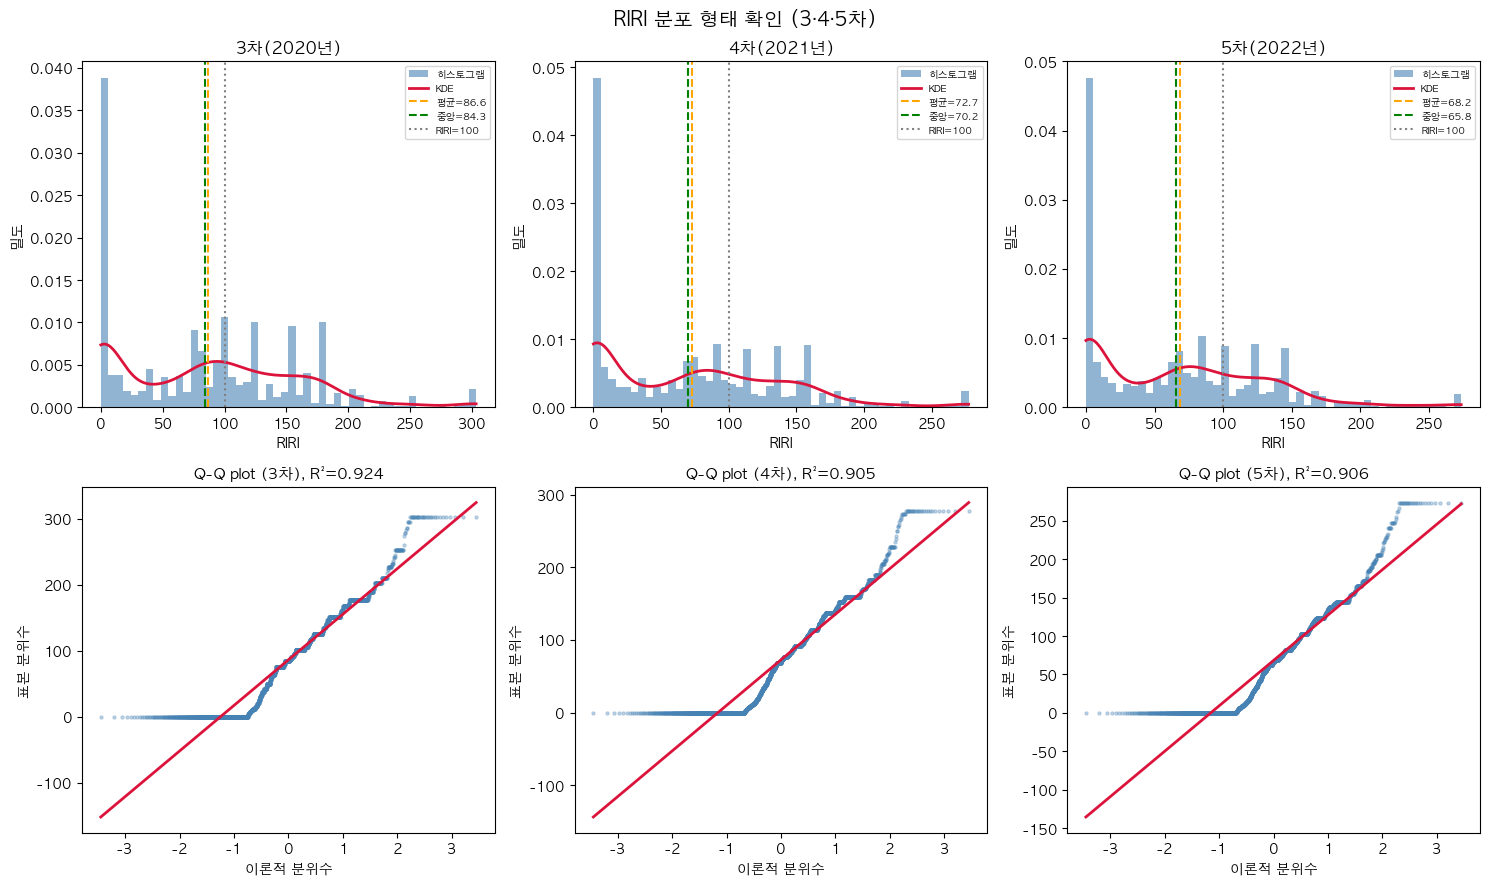

RIRI 정규성 검토

3차(2020년):
  왜도(skewness) = 0.512  
  첨도(kurtosis) = -0.228  
  Shapiro-Wilk: W=0.9239, p=0.0000 ← 정규성 기각
  → 로그변환 불필요

4차(2021년):
  왜도(skewness) = 0.649  
  첨도(kurtosis) = -0.120  
  Shapiro-Wilk: W=0.9047, p=0.0000 ← 정규성 기각
  → 로그변환 불필요

5차(2022년):
  왜도(skewness) = 0.745  
  첨도(kurtosis) = 0.238  
  Shapiro-Wilk: W=0.9050, p=0.0000 ← 정규성 기각
  → 로그변환 불필요


In [23]:
# ============================================================
# RIRI 분포 형태 확인
# 1) 히스토그램 + KDE
# 2) Q-Q plot (정규성 확인)
# 3) 기술통계 + 왜도/첨도
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('RIRI 분포 형태 확인 (3·4·5차)', fontsize=14, fontweight='bold')

for idx, (w, year) in enumerate([(3, 2020), (4, 2021), (5, 2022)]):
    col = f'RIRI_w{w}'
    s   = df_lcga[col].dropna()

    # ── 히스토그램 + KDE ──────────────────────────────────
    ax1 = axes[0][idx]
    ax1.hist(s, bins=50, density=True, alpha=0.6, color='steelblue', label='히스토그램')
    kde_x = np.linspace(s.min(), s.max(), 300)
    kde   = stats.gaussian_kde(s)
    ax1.plot(kde_x, kde(kde_x), color='crimson', linewidth=2, label='KDE')
    ax1.axvline(s.mean(),   color='orange', linestyle='--', linewidth=1.5, label=f'평균={s.mean():.1f}')
    ax1.axvline(s.median(), color='green',  linestyle='--', linewidth=1.5, label=f'중앙={s.median():.1f}')
    ax1.axvline(100, color='gray', linestyle=':', linewidth=1.5, label='RIRI=100')
    ax1.set_title(f'{w}차({year}년)', fontsize=12)
    ax1.set_xlabel('RIRI')
    ax1.set_ylabel('밀도')
    ax1.legend(fontsize=7)

    # ── Q-Q plot ──────────────────────────────────────────
    ax2 = axes[1][idx]
    (osm, osr), (slope, intercept, r) = stats.probplot(s, dist='norm')
    ax2.scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
    ax2.plot(osm, slope * np.array(osm) + intercept, color='crimson', linewidth=2)
    ax2.set_title(f'Q-Q plot ({w}차), R²={r**2:.3f}', fontsize=11)
    ax2.set_xlabel('이론적 분위수')
    ax2.set_ylabel('표본 분위수')

plt.tight_layout()
plt.savefig('riri_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 왜도 · 첨도 출력 ──────────────────────────────────────
print("=" * 50)
print("RIRI 정규성 검토")
print("=" * 50)
for w, year in [(3, 2020), (4, 2021), (5, 2022)]:
    s = df_lcga[f'RIRI_w{w}'].dropna()
    skew = stats.skew(s)
    kurt = stats.kurtosis(s)
    stat_sw, p_sw = stats.shapiro(s.sample(min(5000, len(s)), random_state=42))
    print(f"\n{w}차({year}년):")
    print(f"  왜도(skewness) = {skew:.3f}  {'← 우편포(양의 왜도)' if skew > 1 else ''}")
    print(f"  첨도(kurtosis) = {kurt:.3f}  {'← 뾰족한 분포' if kurt > 3 else ''}")
    print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} "
          f"{'← 정규성 기각' if p_sw < 0.05 else '← 정규성 기각 안됨'}")
    print(f"  → 로그변환 {'권장' if abs(skew) > 1 else '불필요'}")

- 0 근처의 급격한 스파이크.
    - 3, 4, 5차 모두 RIRI=0 부근에 밀도가 극도로 높음.
        - 취업을 아예 못한 패널, 즉 근로소득이 0인 사람들이 상당수 포함되어 있다는 뜻.
        - Q_irr(근로소득 비중)이 0이면 RIRI도 0.
- 50~150 구간에 완만한 두 번째 봉우리가 있음.
    - KDE 곡선이 쌍봉형(bimodal)에 가까운 형태.
    - 소득이 거의 없는 집단과 어느 정도 회복된 집단이 섞여있다는 구조적 신호.
        - LCGA가 이 두 집단을 자연스럽게 분리해줄수도?
- 시간이 지날 수록(3차->5차) 0 근처 스파이크가 더 뾰족해지고 전체 분포가 왼쪽으로 이동하는 것이 포착됨.
    - 미회복 집단이 고착화되고 있다는 기술통계 결과와 일치.

QQ plot에서 보이는 것
- R^2가 0.905~0.924로 높아보이긴 하지만, 플롯 모양이 정규분포에서 벗어나있음
- 계단 형태..
    - 분포가 **혼합 구조**라는 뜻

- 로그 변환 필요.
    - 단순 log 말고 log(RIRI + 1)형태로 변환, LCGA 투입
    - 0 스파이크의 영향 최소화, 모델 안정적으로 수렴
- LCGA 집단 수는 3~4개가 적절할 것으로 예상
    - BIC 기준 k=2,3,4,5 다 돌려보기

In [24]:
# ============================================================
# RIRI 로그변환: log(RIRI + 1)
# RIRI=0인 케이스 보존하면서 분포 정규화
# ============================================================

for w in [3, 4, 5]:
    col     = f'RIRI_w{w}'
    log_col = f'logRIRI_w{w}'
    df_lcga[log_col] = np.log1p(df_lcga[col])  # log(x+1)

# 변환 결과 확인
print("=" * 50)
print("로그변환 전후 비교")
print("=" * 50)

for w in [3, 4, 5]:
    orig = df_lcga[f'RIRI_w{w}'].dropna()
    log  = df_lcga[f'logRIRI_w{w}'].dropna()
    print(f"\n{w}차:")
    print(f"  원본  | 평균={orig.mean():.2f}, SD={orig.std():.2f}, "
          f"왜도={orig.skew():.3f}")
    print(f"  로그  | 평균={log.mean():.2f},  SD={log.std():.2f},  "
          f"왜도={log.skew():.3f}")

로그변환 전후 비교

3차:
  원본  | 평균=86.61, SD=71.84, 왜도=0.513
  로그  | 평균=3.48,  SD=2.01,  왜도=-0.967

4차:
  원본  | 평균=72.74, SD=65.90, 왜도=0.650
  로그  | 평균=3.23,  SD=2.02,  왜도=-0.758

5차:
  원본  | 평균=68.25, SD=61.92, 왜도=0.745
  로그  | 평균=3.20,  SD=1.98,  왜도=-0.785


In [25]:
from scipy.stats import yeojohnson, boxcox

print("=" * 55)
print("변환 방법별 왜도 비교")
print("=" * 55)

for w in [3, 4, 5]:
    col  = f'RIRI_w{w}'
    s    = df_lcga[col].dropna()

    # 원본
    skew_orig = s.skew()

    # log(x+1)
    skew_log  = np.log1p(s).skew()

    # sqrt
    skew_sqrt = np.sqrt(s).skew()

    # Yeo-Johnson (0, 음수 모두 처리 가능)
    yj, _ = yeojohnson(s)
    skew_yj = pd.Series(yj).skew()

    # Box-Cox (0 제외 필요 → 0을 0.001로 대체)
    s_bc = s.replace(0, 0.001)
    bc, _ = boxcox(s_bc)
    skew_bc = pd.Series(bc).skew()

    print(f"\n{w}차:")
    print(f"  원본        왜도 = {skew_orig:.3f}")
    print(f"  log(x+1)   왜도 = {skew_log:.3f}")
    print(f"  sqrt        왜도 = {skew_sqrt:.3f}")
    print(f"  Yeo-Johnson 왜도 = {skew_yj:.3f}")
    print(f"  Box-Cox     왜도 = {skew_bc:.3f}")
    print(f"  → 왜도 절댓값 최소: ", end="")
    results = {
        '원본': abs(skew_orig),
        'log':  abs(skew_log),
        'sqrt': abs(skew_sqrt),
        'YJ':   abs(skew_yj),
        'BC':   abs(skew_bc),
    }
    best = min(results, key=results.get)
    print(f"{best} ({results[best]:.3f})")

변환 방법별 왜도 비교

3차:
  원본        왜도 = 0.513
  log(x+1)   왜도 = -0.967
  sqrt        왜도 = -0.419
  Yeo-Johnson 왜도 = -0.454
  Box-Cox     왜도 = -0.859
  → 왜도 절댓값 최소: sqrt (0.419)

4차:
  원본        왜도 = 0.650
  log(x+1)   왜도 = -0.758
  sqrt        왜도 = -0.240
  Yeo-Johnson 왜도 = -0.373
  Box-Cox     왜도 = -0.740
  → 왜도 절댓값 최소: sqrt (0.240)

5차:
  원본        왜도 = 0.745
  log(x+1)   왜도 = -0.785
  sqrt        왜도 = -0.236
  Yeo-Johnson 왜도 = -0.365
  Box-Cox     왜도 = -0.752
  → 왜도 절댓값 최소: sqrt (0.236)


In [26]:
# sqrt 변환 적용
for w in [3, 4, 5]:
    col      = f'RIRI_w{w}'
    sqrt_col = f'sqrtRIRI_w{w}'
    df_lcga[sqrt_col] = np.sqrt(df_lcga[col])

# 확인
print("sqrt 변환 결과")
for w in [3, 4, 5]:
    s = df_lcga[f'sqrtRIRI_w{w}'].dropna()
    print(f"{w}차: 평균={s.mean():.2f}, SD={s.std():.2f}, 왜도={s.skew():.3f}")

sqrt 변환 결과
3차: 평균=7.80, SD=5.07, 왜도=-0.419
4차: 평균=6.96, SD=4.93, 왜도=-0.240
5차: 평균=6.77, SD=4.73, 왜도=-0.236


In [27]:
df_lcga.head(3)

,pid,p05,nonresponse05,workperiod14,accident,injurytype,injurypart,con16,acc1,hire1,...,lifesatis_w5,health_w5,job_rehab,soc_rehab,logRIRI_w3,logRIRI_w4,logRIRI_w5,sqrtRIRI_w3,sqrtRIRI_w4,sqrtRIRI_w5
1,2,1,NaN,10,2,13,1,6,2012,2008,...,1.0,1.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,1,NaN,7,1,1,9,6,2014,2013,...,3.0,2.0,0.0,0.0,3.857421,4.306413,5.614808,6.807577,8.554178,16.536649
3,4,1,NaN,12,2,13,1,6,2015,2009,...,3.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


RIRI 변환 후 변수 이름: sqrtRIRI_w3/4/5

### 결측 패턴 확인

In [28]:
# ============================================================
# ① 결측 분포 - 차수별 결측 현황
# ============================================================

print("=" * 55)
print("① 결측 분포 (차수별)")
print("=" * 55)

riri_cols = ['RIRI_w3', 'RIRI_w4', 'RIRI_w5']
n = len(df_lcga)

for col in riri_cols:
    miss  = df_lcga[col].isna().sum()
    valid = df_lcga[col].notna().sum()
    print(f"  {col}: 유효={valid}({valid/n*100:.1f}%), 결측={miss}({miss/n*100:.1f}%)")

# 3차수 동시 결측 패턴
print(f"\n  3차수 모두 유효: {df_lcga[riri_cols].notna().all(axis=1).sum()}명")
print(f"  2차수 유효:      {(df_lcga[riri_cols].notna().sum(axis=1)==2).sum()}명")
print(f"  1차수만 유효:    {(df_lcga[riri_cols].notna().sum(axis=1)==1).sum()}명")


① 결측 분포 (차수별)
  RIRI_w3: 유효=2436(95.8%), 결측=106(4.2%)
  RIRI_w4: 유효=2482(97.6%), 결측=60(2.4%)
  RIRI_w5: 유효=2472(97.2%), 결측=70(2.8%)

  3차수 모두 유효: 2306명
  2차수 유효:      236명
  1차수만 유효:    0명


In [29]:
# ============================================================
# ② 결측 패턴 - 어떤 조합으로 빠졌는지
# ============================================================

print("\n" + "=" * 55)
print("② 결측 패턴 (조합별)")
print("=" * 55)

df_lcga['miss_w3'] = df_lcga['RIRI_w3'].isna().astype(int)
df_lcga['miss_w4'] = df_lcga['RIRI_w4'].isna().astype(int)
df_lcga['miss_w5'] = df_lcga['RIRI_w5'].isna().astype(int)

pattern = df_lcga.groupby(['miss_w3','miss_w4','miss_w5']).size().reset_index(name='n')
pattern['%'] = (pattern['n'] / n * 100).round(1)
pattern.columns = ['3차결측','4차결측','5차결측','n','%']
pattern['패턴'] = pattern.apply(
    lambda r: ''.join(['결측' if r[f'{w}차결측'] else '유효'
                       for w in [3,4,5]]), axis=1)
print(pattern[['패턴','n','%']].to_string(index=False))



② 결측 패턴 (조합별)
    패턴    n    %
유효유효유효 2306 90.7
유효유효결측   70  2.8
유효결측유효   60  2.4
결측유효유효  106  4.2


In [30]:
# ============================================================
# ③ 결측 vs 비결측 집단 비교 (MCAR 검토)
#    각 차수별로 결측 여부에 따라 주요 변수 차이 검정
# ============================================================

print("\n" + "=" * 55)
print("③ 결측 vs 비결측 집단 비교")
print("=" * 55)

compare_vars = {
    'gender':    '성별(1=남,2=여)',
    'age054':    '연령대',
    'disa_class':'장해등급(0~2)',
    'RIRI_w3':   'RIRI_3차',
    'RIRI_w4':   'RIRI_4차',
}

for wave, miss_col in [(4, 'miss_w4'), (5, 'miss_w5')]:
    print(f"\n  [RIRI_{wave}차 결측 여부에 따른 집단 비교]")
    print(f"  {'변수':<15} {'비결측 평균':>10} {'결측 평균':>10} {'p-value':>10} {'판정':>10}")
    print("  " + "-" * 55)

    miss_idx    = df_lcga[miss_col] == 1
    nonmiss_idx = df_lcga[miss_col] == 0

    for var, label in compare_vars.items():
        if var not in df_lcga.columns:
            continue
        g0 = df_lcga.loc[nonmiss_idx, var].dropna()
        g1 = df_lcga.loc[miss_idx,    var].dropna()

        if len(g1) < 2:
            continue

        # 연속형: t-test / 범주형도 평균 비교로 간이 검정
        t, p = stats.ttest_ind(g0, g1, equal_var=False)
        sig  = '*** 유의' if p < 0.001 else ('** 유의' if p < 0.01
               else ('* 유의' if p < 0.05 else '비유의'))
        print(f"  {label:<15} {g0.mean():>10.3f} {g1.mean():>10.3f} "
              f"{p:>10.4f} {sig:>10}")

# Little's MCAR Test 대용: 전체 결측 패턴과 공변량 간 카이제곱
print("\n" + "=" * 55)
print("  [결측 여부와 장해등급 카이제곱 검정]")
print("=" * 55)

for wave, miss_col in [(4, 'miss_w4'), (5, 'miss_w5')]:
    ct = pd.crosstab(df_lcga['disa_class'], df_lcga[miss_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  RIRI_{wave}차 결측 × 장해등급: χ²={chi2:.3f}, df={dof}, p={p:.4f} "
          f"{'← 체계적 결측 의심' if p < 0.05 else '← MCAR 지지'}")

for wave, miss_col in [(4, 'miss_w4'), (5, 'miss_w5')]:
    ct = pd.crosstab(df_lcga['age054'], df_lcga[miss_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  RIRI_{wave}차 결측 × 연령대:   χ²={chi2:.3f}, df={dof}, p={p:.4f} "
          f"{'← 체계적 결측 의심' if p < 0.05 else '← MCAR 지지'}")

# 임시 컬럼 정리
df_lcga.drop(columns=['miss_w3','miss_w4','miss_w5'], inplace=True)


③ 결측 vs 비결측 집단 비교

  [RIRI_4차 결측 여부에 따른 집단 비교]
  변수                  비결측 평균      결측 평균    p-value         판정
  -------------------------------------------------------
  성별(1=남,2=여)          1.170      1.233     0.2621        비유의
  연령대                  3.161      3.000     0.2257        비유의
  장해등급(0~2)            1.516      1.450     0.5736        비유의
  RIRI_3차             86.576     88.143     0.8449        비유의

  [RIRI_5차 결측 여부에 따른 집단 비교]
  변수                  비결측 평균      결측 평균    p-value         판정
  -------------------------------------------------------
  성별(1=남,2=여)          1.170      1.229     0.2581        비유의
  연령대                  3.163      2.971     0.1364        비유의
  장해등급(0~2)            1.523      1.200     0.0001     *** 유의
  RIRI_3차             88.048     38.176     0.0000     *** 유의
  RIRI_4차             73.920     31.990     0.0000     *** 유의

  [결측 여부와 장해등급 카이제곱 검정]
  RIRI_4차 결측 × 장해등급: χ²=6.745, df=2, p=0.0343 ← 체계적 결측 의심
  RIRI_5차 결측 × 장해등급: χ²=141.456, df=2, p=0

- 결측률: LCGA에서 Full Information Maximum Likelihood(FIML)로 처리하면 됨.
- 결측 패턴도 괜찮
- **결측 vs 비결측 비교**
    - 4차 결측: 성별·연령·장해등급·RIRI 모두 비유의로, MCAR에 가까움
    - 5차 결측: 장해등급에서 결측 집단 평균이 1.200으로 비결측(1.523)보다 낮아요. 
        - 즉 무장해 또는 경증 집단이 5차에서 더 많이 빠졌어요. χ²=141.5, p<.001로 매우 강한 연관이에요.
        -  RIRI에서도 결측 집단의 3차 RIRI가 38.2, 4차가 32.0으로 비결측(88.0, 73.9)의 절반도 안 돼요.  
            - 소득회복이 낮은 사람들이 5차 조사에서 체계적으로 탈락하고 있어요.

MAR(Missing At Random)에 해당
- 완전 무작위(MCAR)는 아니지만, 결측이 관측된 변수(장해등급, 이전 차수 RIRI)로 설명이 되는 구조. 
    - 관측되지 않은 미지의 요인 때문이 아니라는 것.

[분석에 미치는 영향]
- 첫째, LCGA에서 FIML 추정을 쓰면 MAR 가정 하에 편향 없이 추정할 수 있어요. 별도 대체 작업 없이 진행해도 돼요.
- 둘째, 논문 한계점에 "5차 결측이 저소득·경증 집단에서 체계적으로 발생해 만성취약형 집단의 규모가 과소추정될 수 있다" 고 명시해야 해요. 탈락한 사람들이 바로 가장 회복이 안 된 집단이니까요.

In [31]:
# ============================================================
# 결측 처리 - FIML 방식
# LCGA 자체가 FIML로 결측 처리하므로
# 여기서는 결측 플래그 변수만 생성해두고
# 실제 대체는 하지 않음 (원본 유지)
# ============================================================

print("=" * 55)
print("결측 처리 - FIML 방식 확정")
print("=" * 55)

# 결측 플래그 변수 생성 (나중에 민감도 분석용)
for w in [3, 4, 5]:
    df_lcga[f'miss_flag_w{w}'] = df_lcga[f'RIRI_w{w}'].isna().astype(int)

# 완전 관측 케이스 수 확인
complete = df_lcga[['RIRI_w3','RIRI_w4','RIRI_w5']].notna().all(axis=1)
print(f"\n  완전 관측 케이스:  {complete.sum()}명 ({complete.mean()*100:.1f}%)")
print(f"  부분 결측 케이스:  {(~complete).sum()}명 ({(~complete).mean()*100:.1f}%)")
print(f"\n  → LCGA에서 FIML로 자동 처리 예정")
print(f"  → 원본 RIRI 값 유지 (별도 대체 없음)")

결측 처리 - FIML 방식 확정

  완전 관측 케이스:  2306명 (90.7%)
  부분 결측 케이스:  236명 (9.3%)

  → LCGA에서 FIML로 자동 처리 예정
  → 원본 RIRI 값 유지 (별도 대체 없음)



스파게티 플롯


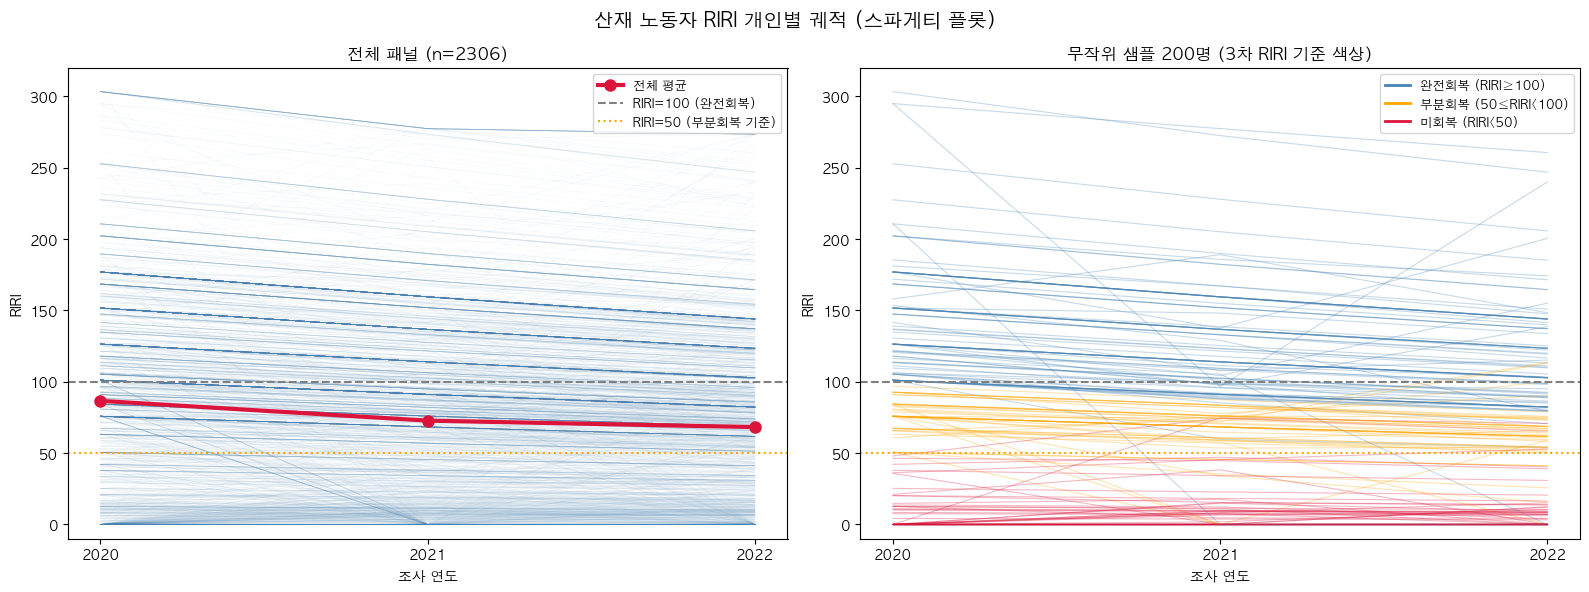

spaghetti_plot.png 저장 완료


In [32]:
# ============================================================
# 스파게티 플롯
# 개인별 RIRI 궤적 시각화
# 전체 + 무작위 샘플 100명
# ============================================================

print("\n" + "=" * 55)
print("스파게티 플롯")
print("=" * 55)

waves      = [3, 4, 5]
wave_years = [2020, 2021, 2022]
riri_cols  = ['RIRI_w3', 'RIRI_w4', 'RIRI_w5']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('산재 노동자 RIRI 개인별 궤적 (스파게티 플롯)', fontsize=14, fontweight='bold')

# ── 왼쪽: 전체 패널 (투명도 낮게) ──────────────────────────
ax1 = axes[0]
for _, row in df_lcga.iterrows():
    vals = [row[c] for c in riri_cols]
    if any(pd.isna(v) for v in vals):
        continue
    ax1.plot(wave_years, vals, color='steelblue', alpha=0.05, linewidth=0.5)

# 전체 평균 궤적 추가
means = [df_lcga[c].mean() for c in riri_cols]
ax1.plot(wave_years, means, color='crimson', linewidth=3,
         marker='o', markersize=8, label=f'전체 평균')
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, label='RIRI=100 (완전회복)')
ax1.axhline(50,  color='orange', linestyle=':', linewidth=1.5, label='RIRI=50 (부분회복 기준)')
ax1.set_title(f'전체 패널 (n={complete.sum()})', fontsize=12)
ax1.set_xlabel('조사 연도')
ax1.set_ylabel('RIRI')
ax1.set_xticks(wave_years)
ax1.legend(fontsize=9)
ax1.set_ylim(-10, 320)

# ── 오른쪽: 무작위 샘플 200명 (궤적 패턴 파악용) ────────────
ax2 = axes[1]
complete_idx = df_lcga[df_lcga[riri_cols].notna().all(axis=1)].index
sample_idx   = np.random.RandomState(42).choice(complete_idx, size=min(200, len(complete_idx)), replace=False)
df_sample    = df_lcga.loc[sample_idx]

# RIRI 수준별 색상 구분 (3차 기준)
for _, row in df_sample.iterrows():
    vals  = [row[c] for c in riri_cols]
    riri3 = row['RIRI_w3']
    if riri3 >= 100:
        color = 'steelblue'    # 완전회복
    elif riri3 >= 50:
        color = 'orange'       # 부분회복
    else:
        color = 'crimson'      # 미회복
    ax2.plot(wave_years, vals, color=color, alpha=0.3, linewidth=0.8)

# 범례용 더미 라인
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='steelblue', linewidth=2, label='완전회복 (RIRI≥100)'),
    Line2D([0],[0], color='orange',    linewidth=2, label='부분회복 (50≤RIRI<100)'),
    Line2D([0],[0], color='crimson',   linewidth=2, label='미회복 (RIRI<50)'),
]
ax2.axhline(100, color='gray',   linestyle='--', linewidth=1.5)
ax2.axhline(50,  color='orange', linestyle=':',  linewidth=1.5)
ax2.set_title('무작위 샘플 200명 (3차 RIRI 기준 색상)', fontsize=12)
ax2.set_xlabel('조사 연도')
ax2.set_ylabel('RIRI')
ax2.set_xticks(wave_years)
ax2.legend(handles=legend_elements, fontsize=9)
ax2.set_ylim(-10, 320)

plt.tight_layout()
plt.savefig('spaghetti_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("spaghetti_plot.png 저장 완료")

In [33]:
# ============================================================
# 궤적 유형 사전 파악
# 3차 → 5차 변화량 기준 집단 분포
# ============================================================

print("\n" + "=" * 55)
print("궤적 변화 방향 사전 파악")
print("=" * 55)

df_comp = df_lcga[df_lcga[riri_cols].notna().all(axis=1)].copy()
df_comp['delta_35'] = df_comp['RIRI_w5'] - df_comp['RIRI_w3']  # 3→5차 변화량

# 변화 방향 분류
df_comp['traj_type'] = pd.cut(
    df_comp['delta_35'],
    bins  = [-np.inf, -20, 20, np.inf],
    labels= ['하락형(△<-20)', '안정형(-20≤△≤20)', '상승형(△>20)']
)

dist = df_comp['traj_type'].value_counts()
for k, v in dist.items():
    print(f"  {k}: {v}명({v/len(df_comp)*100:.1f}%)")

print(f"\n  3→5차 평균 변화량: {df_comp['delta_35'].mean():.1f}")
print(f"  3→5차 변화량 SD:   {df_comp['delta_35'].std():.1f}")


궤적 변화 방향 사전 파악
  안정형(-20≤△≤20): 1222명(53.0%)
  하락형(△<-20): 980명(42.5%)
  상승형(△>20): 104명(4.5%)

  3→5차 평균 변화량: -16.5
  3→5차 변화량 SD:   30.1


### Spaghetti Plot 해석

핵심 질문: "산재 노동자들의 소득은 시간이 지나면서 어떻게 됐나?"

- RIRI: 생활임금 대비 내가 버는 돈의 비율.
    - RIRI=100이면 생활임금만큼 벌고 있다는 뜻.
    - RIRI=50이면 생활임금의 절반만 번다는 뜻.

##### 왼쪽 그래프: 전체 2,306명
- 빨간 굵은 선: 전체 평균
    - 2020년 86.6 → 2021년 72.7 → 2022년 68.2
    - 산재 노동자 현황이 시간이 지날수록 조금씩 나빠진다
- 상단 100~300 사이를 수평으로 달리는 선
    - 처음부터 생활임금 이상을 벌었고 5년 내내 유지한 사람들
- 하단 0 근처의 선
    - 처음부터 거의 소득이 없었고 5년이 지나도 그대로.


평균 86.6이라는 숫자는 "100 이상인 사람"과 "0에 가까운 사람"을 섞어서 나온 숫자라 현실을 제대로 반영 못함.

= 연구계획서에서 언급한 *"평균의 함정"*

##### 오른쪽 그래프: 200명 샘플
- **파란선**: 완전회복 집단 (RIRI ≥ 100)
    - 2020년부터 생활임금 이상을 벌었어요. 
    - 시간이 지나면서 조금씩 내려가긴 하지만 대부분 100 근처를 유지
    - 이 집단은 산재를 당했어도 경제적으로 안정적으로 복귀한 사람들
- **주황선**: 부분회복 집단 (RIRI 50~100)
    - 생활임금의 절반~전부 수준을 벌고 있어요. 
    - 완전히 회복은 못 했지만 그렇다고 아주 바닥은 아닌 중간 집단
    - 시간이 지나면서 일부는 50 아래로 떨어지기도. 
    - 불안정한 집단
- [주목 필요] **빨간선**: 미회복 집단 (RIRI < 50)
    - 2020년부터 생활임금의 절반도 못 벌었고, 2022년에도 거의 그대로예요. 0에 아주 가까운 선들이 많음. 
    - 사실상 소득이 없는 상태가 5년째 지속되고 있는 것.
    - 만성적으로 경제적 어려움에 고착된 집단

##### 수치적 변화
3→5차 변화량을 보면:

- 안정형(변화 거의 없음): 1,222명, 53%
- 하락형(20 이상 떨어짐): 980명, 42.5%
- 상승형(20 이상 올라감): 104명, 4.5%

평균 변화량이 -16.5.
- 전체적으로 조금씩 나빠지고 있는 것.
- 상승형이 4.5%밖에 안 된다는 게 문제.
- 100명 중 4~5명만 시간이 지나면서 더 나아졌고, 나머지 95명은 제자리이거나 더 나빠짐

##### 요약
산재 노동자의 절반은 처음부터 회복이 됐든 안 됐든 그 상태로 고착되고, 42%는 시간이 지날수록 더 나빠지고 있음. 더 좋아지는 사람은 5%도 안 됨.


= LCGA 해야하는 이유. 평균으로는 이 세 집단을 나누기가 힘듦.

### 변수 간 상관관계

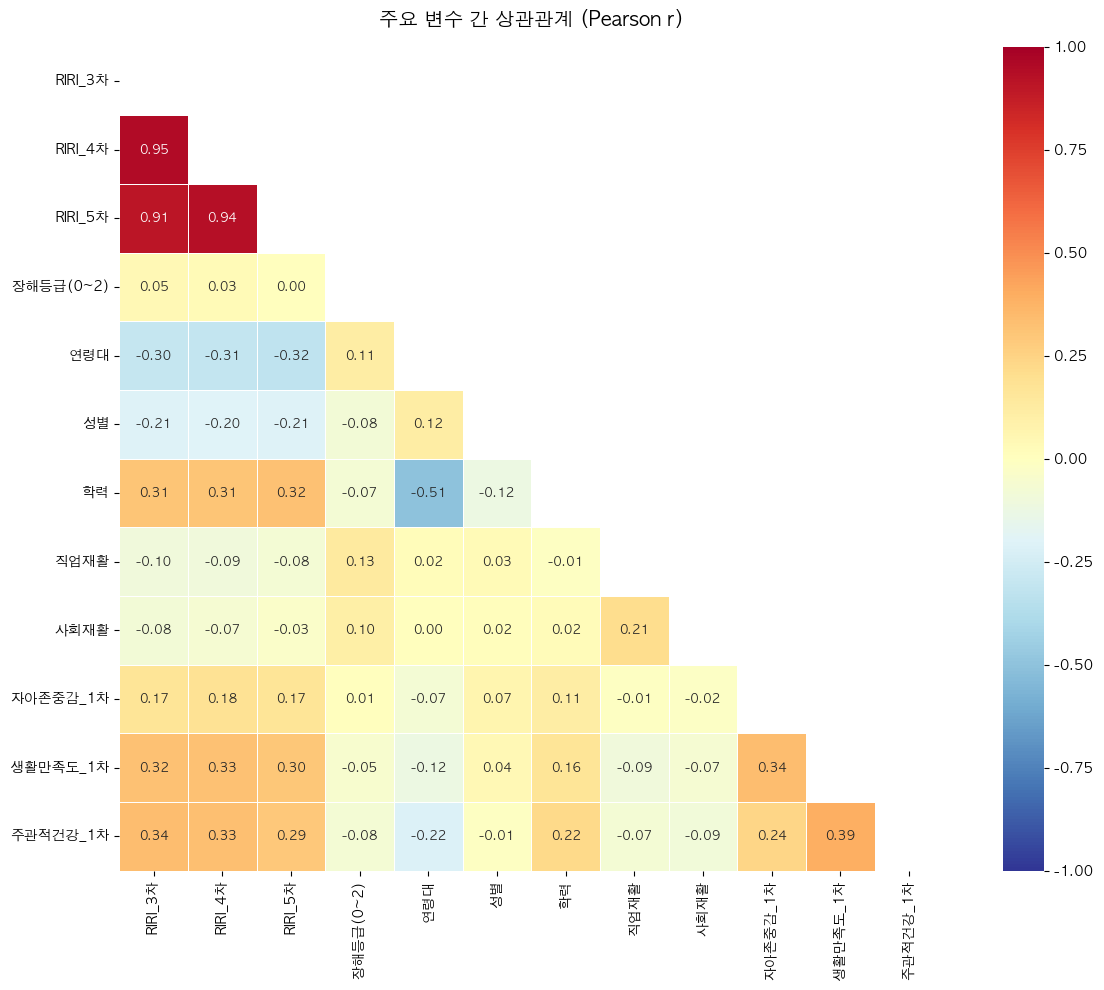

RIRI_3차와 각 변수 간 상관계수 (절댓값 순)
  RIRI_4차        : r= 0.948, p=0.0000 ***
  RIRI_5차        : r= 0.909, p=0.0000 ***
  주관적건강_1차       : r= 0.342, p=0.0000 ***
  생활만족도_1차       : r= 0.324, p=0.0000 ***
  학력             : r= 0.306, p=0.0000 ***
  연령대            : r=-0.303, p=0.0000 ***
  성별             : r=-0.209, p=0.0000 ***
  자아존중감_1차       : r= 0.170, p=0.0000 ***
  직업재활           : r=-0.100, p=0.0000 ***
  사회재활           : r=-0.078, p=0.0001 ***
  장해등급(0~2)      : r= 0.045, p=0.0258 *

RIRI 차수 간 상관 (시계열 안정성)
  RIRI_3차 vs RIRI_4차: r=0.948, p=0.0000
  RIRI_4차 vs RIRI_5차: r=0.937, p=0.0000
  RIRI_3차 vs RIRI_5차: r=0.909, p=0.0000


In [34]:
import seaborn as sns

# ============================================================
# ④ 변수 간 상관관계
# RIRI와 주요 공변량 간 관계 파악
# ============================================================

# 분석에 쓸 변수 선택
corr_vars = {
    'RIRI_w3':    'RIRI_3차',
    'RIRI_w4':    'RIRI_4차',
    'RIRI_w5':    'RIRI_5차',
    'disa_class': '장해등급(0~2)',
    'age054':     '연령대',
    'gender':     '성별',
    'edu05':      '학력',
    'job_rehab':  '직업재활',
    'soc_rehab':  '사회재활',
    'esteem_w1':  '자아존중감_1차',
    'lifesatis_w1':'생활만족도_1차',
    'health_w1':  '주관적건강_1차',
}

# 실제 있는 컬럼만
exist_vars = {k: v for k, v in corr_vars.items() if k in df_lcga.columns}
df_corr = df_lcga[list(exist_vars.keys())].copy()
df_corr.columns = list(exist_vars.values())

# ── 상관계수 행렬 계산 ────────────────────────────────────
corr_matrix = df_corr.corr(method='pearson')

# ── 히트맵 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스킹

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9},
)
ax.set_title('주요 변수 간 상관관계 (Pearson r)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── RIRI_3차 기준 상관계수 순위 출력 ─────────────────────
print("=" * 55)
print("RIRI_3차와 각 변수 간 상관계수 (절댓값 순)")
print("=" * 55)

riri3_corr = corr_matrix['RIRI_3차'].drop('RIRI_3차').abs().sort_values(ascending=False)
for var, r in riri3_corr.items():
    orig_r = corr_matrix['RIRI_3차'][var]
    # 유의성 검정
    n_valid = df_corr[['RIRI_3차', var]].dropna().__len__()
    t_stat  = orig_r * np.sqrt(n_valid - 2) / np.sqrt(1 - orig_r**2)
    p_val   = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_valid - 2))
    sig     = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    print(f"  {var:<15}: r={orig_r:>6.3f}, p={p_val:.4f} {sig}")

# ── RIRI 차수 간 상관 (시계열 안정성) ────────────────────
print("\n" + "=" * 55)
print("RIRI 차수 간 상관 (시계열 안정성)")
print("=" * 55)
for (w1, w2) in [(3,4),(4,5),(3,5)]:
    c1, c2 = f'RIRI_w{w1}', f'RIRI_w{w2}'
    both   = df_lcga[[c1,c2]].dropna()
    r, p   = stats.pearsonr(both[c1], both[c2])
    print(f"  RIRI_{w1}차 vs RIRI_{w2}차: r={r:.3f}, p={p:.4f}")

- **r=0.95**에 가깝다는 건 3차에 RIRI가 높았던 사람은 4차, 5차에도 높고 / 낮았던 사람은 계속 낮다는 뜻.
    - 쉽게 말하면 **"한번 고착되면 안 바뀐다"** 는 거. 
    - 스파게티 플롯에서 선들이 교차 없이 거의 평행하게 흘렀던 게 이 숫자로 증명됨.

- **집단 간 경계가 뚜렷할 가능성**이 높아요.
    - 궤적이 섞이지 않고 각자 레인을 유지하니까 LCGA가 집단을 깔끔하게 분리할 가능성이 높아요.
- 기울기(slope)보다 **절편(intercept)**이 집단을 더 잘 구분할 것
    - 즉 "얼마나 변하냐"보다 **"어느 수준에서 시작했냐"** 가 집단을 결정하는 핵심 요인

- **심리·건강 변수**가 예상보다 강해요.
    - 주관적건강(r=0.342), 생활만족도(r=0.324)가 학력(r=0.306)보다 높게 나옴. 
    - 신체적·심리적 상태가 소득회복과 밀접하게 연결돼 있다는 것. 
    - 연구계획서에서 "심리 지원의 경제적 가치"를 주장한 근거가 여기서 나옴.
- **재활서비스** 상관이 음수(-0.100, -0.078)예요.
    - 재활서비스를 이용할수록 RIRI가 낮다는 건데, 이건 인과관계가 아니라 **선택편향** 이에요. 
    - 소득이 낮고 회복이 안 된 사람들이 재활서비스를 더 많이 이용하는 것. 
    - 나중에 BCH 분석에서 이 부분을 통제해야 함.
- **장해등급** 상관이 가장 낮아요(r=0.045).
    - 경증이 많은 표본 구조 때문에 변별력이 떨어진 것
    - 단순 상관으로는 잘 안 잡히지만 LCGA 집단 내에서는 의미 있게 나올 수도..

In [35]:
df_lcga.to_csv('pswci_riri_lcga.csv')

In [36]:
# ============================================================
# 1. R 결과 로드 및 병합
# ============================================================

# R에서 저장한 집단 할당 결과
df_class = pd.read_csv('lcga_class_k4.csv')
print("집단 할당 데이터:", df_class.shape)
print(df_class.head())
print("\n집단별 인원:")
print(df_class['class'].value_counts().sort_index())

# 기존 df_lcga에 집단 병합
df_lcga = df_lcga.drop(columns=['class'], errors='ignore')
df_lcga = df_lcga.merge(df_class[['pid','class']], on='pid', how='left')
df_lcga = df_lcga.rename(columns={'class': 'lcga_class'})

# 집단 레이블 부여
class_label = {
    1: '만성미회복형',
    2: '하락취약형',
    3: '부분회복형',
    4: '안정고소득형'
}
df_lcga['class_label'] = df_lcga['lcga_class'].map(class_label)

print("\n집단 레이블 확인:")
print(df_lcga['class_label'].value_counts())


집단 할당 데이터: (2542, 6)
   pid  class         prob1         prob2         prob3         prob4
0    2      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38
1    3      3  3.742694e-23  1.356611e-09  8.745858e-01  1.254142e-01
2    4      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38
3    5      1  9.999763e-01  2.369664e-05  1.235853e-14  3.630346e-27
4    6      1  9.999981e-01  1.928174e-06  1.558484e-20  1.284030e-38

집단별 인원:
class
1    702
2    352
3    897
4    591
Name: count, dtype: int64

집단 레이블 확인:
class_label
부분회복형     897
만성미회복형    702
안정고소득형    591
하락취약형     352
Name: count, dtype: int64


In [37]:
# ============================================================
# 2. 집단별 공변량 분포 비교 (BCH 전 기술통계)
#    성별, 연령, 학력, 장해등급, 재활서비스, 심리변수
# ============================================================

print("\n" + "=" * 60)
print("집단별 공변량 분포 비교")
print("=" * 60)

# 연속형 변수: 집단별 평균 비교 + 일원분산분석(ANOVA)
cont_vars = {
    'age054':     '연령대',
    'edu05':      '학력',
    'disa_class': '장해등급',
    'esteem_w1':  '자아존중감_1차',
    'lifesatis_w1':'생활만족도_1차',
    'G01005001':  '주관적건강_1차',
}

print("\n[연속형 변수 집단별 평균 및 ANOVA]")
print(f"{'변수':<15} {'집단1':>8} {'집단2':>8} {'집단3':>8} {'집단4':>8} {'F':>8} {'p':>8}")
print("-" * 65)

for col, label in cont_vars.items():
    if col not in df_lcga.columns:
        continue
    groups = [df_lcga[df_lcga['lcga_class']==k][col].dropna()
              for k in [1,2,3,4]]
    means  = [g.mean() for g in groups]
    f, p   = stats.f_oneway(*groups)
    sig    = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f"{label:<15} "
          f"{means[0]:>8.2f} {means[1]:>8.2f} "
          f"{means[2]:>8.2f} {means[3]:>8.2f} "
          f"{f:>8.2f} {p:>7.4f}{sig}")

# 범주형 변수: 카이제곱 검정
cat_vars = {
    'gender':     '성별',
    'job_rehab':  '직업재활',
    'soc_rehab':  '사회재활',
}

print("\n[범주형 변수 집단별 분포 및 카이제곱]")
for col, label in cat_vars.items():
    if col not in df_lcga.columns:
        continue
    ct = pd.crosstab(df_lcga['lcga_class'], df_lcga[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f"\n  {label}: χ²={chi2:.3f}, df={dof}, p={p:.4f} {sig}")
    # 집단별 비율
    pct = ct.div(ct.sum(axis=1), axis=0).round(3) * 100
    print(pct.to_string())



집단별 공변량 분포 비교

[연속형 변수 집단별 평균 및 ANOVA]
변수                   집단1      집단2      집단3      집단4        F        p
-----------------------------------------------------------------
연령대                 3.54     3.35     3.05     2.74    84.35  0.0000***
학력                  3.17     3.41     3.75     4.01    87.00  0.0000***
장해등급                1.48     1.51     1.50     1.57     1.45  0.2272
자아존중감_1차            2.49     2.65     2.77     2.86    32.84  0.0000***
생활만족도_1차            2.87     3.16     3.30     3.51   100.56  0.0000***
주관적건강_1차            2.08     2.49     2.66     2.74   149.18  0.0000***

[범주형 변수 집단별 분포 및 카이제곱]

  성별: χ²=127.739, df=3, p=0.0000 ***
gender         1     2
lcga_class            
1           78.6  21.4
2           73.9  26.1
3           79.7  20.3
4           97.8   2.2

  직업재활: χ²=25.125, df=3, p=0.0000 ***
job_rehab    0.0   1.0
lcga_class            
1           82.2  17.8
2           77.8  22.2
3           85.5  14.5
4           89.2  10.8

  사회재활: χ²=10.889

In [38]:
# ============================================================
# 3. 다항 로지스틱 회귀 (BCH 근사)
#    집단을 종속변수, 공변량을 독립변수로
#    Reference: 집단3 (부분회복형, 가장 큰 집단)
# ============================================================

print("\n" + "=" * 60)
print("다항 로지스틱 회귀 (결정요인 분석)")
print("=" * 60)

from statsmodels.discrete.discrete_model import MNLogit
import statsmodels.api as sm

# 분석 변수 설정
pred_vars = [
    'gender', 'age054', 'edu05', 'disa_class',
    'job_rehab', 'soc_rehab',
    'esteem_w1', 'lifesatis_w1', 'G01005001'
]

exist_pred = [v for v in pred_vars if v in df_lcga.columns]

# 결측 제거
df_mnl = df_lcga[['lcga_class'] + exist_pred].dropna()
print(f"\n분석 대상: {len(df_mnl)}명")

# Reference 집단: 3 (부분회복형)
# statsmodels MNLogit은 0부터 시작하므로 재코딩
class_map = {1: 0, 2: 1, 3: 2, 4: 3}  # 3→2(reference)
df_mnl['y'] = df_mnl['lcga_class'].map(class_map)

X = sm.add_constant(df_mnl[exist_pred])
y = df_mnl['y']

model = MNLogit(y, X)
result = model.fit(method='bfgs', maxiter=500, disp=False)

print("\n[다항 로지스틱 회귀 결과 요약]")
print(result.summary())



다항 로지스틱 회귀 (결정요인 분석)

분석 대상: 2542명

[다항 로지스틱 회귀 결과 요약]
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 2542
Model:                        MNLogit   Df Residuals:                     2512
Method:                           MLE   Df Model:                           27
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.1362
Time:                        11:05:47   Log-Likelihood:                -2933.4
converged:                       True   LL-Null:                       -3395.8
Covariance Type:            nonrobust   LLR p-value:                1.806e-177
         y=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.5783      0.630     -5.677      0.000      -4.814      -2.343
gender           0.2090      0.161      1.302      0.193      -0.106 

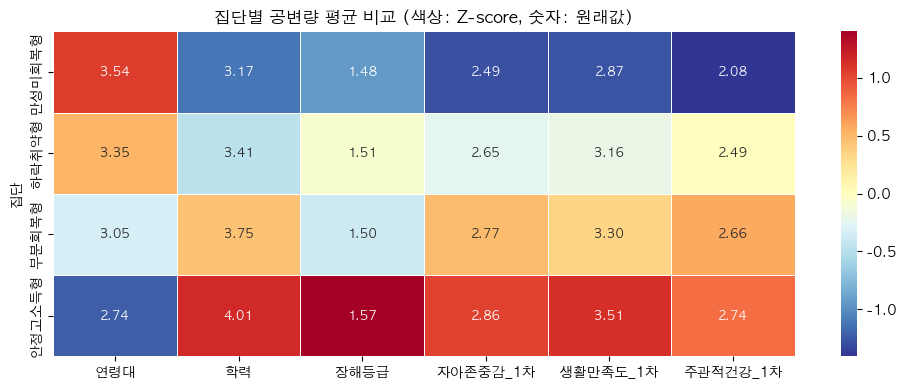

class_covariate_heatmap.png 저장 완료


In [39]:
# ============================================================
# 4. 집단별 공변량 분포 히트맵 시각화
# ============================================================

# 집단별 평균 정규화 (Z-score)
heatmap_vars = list(cont_vars.keys())
heatmap_vars = [v for v in heatmap_vars if v in df_lcga.columns]

heatmap_data = []
for k in [1, 2, 3, 4]:
    row = {'집단': class_label[k]}
    for col in heatmap_vars:
        row[cont_vars[col]] = df_lcga[df_lcga['lcga_class']==k][col].mean()
    heatmap_data.append(row)

df_heat = pd.DataFrame(heatmap_data).set_index('집단')

# Z-score 정규화
df_heat_z = (df_heat - df_heat.mean()) / df_heat.std()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_heat_z,
    annot=df_heat.round(2),
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('집단별 공변량 평균 비교 (색상: Z-score, 숫자: 원래값)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('class_covariate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("class_covariate_heatmap.png 저장 완료")

### 결과 해석

**집단별 공변량 분포 비교**
- 집단1 → 집단4로 갈수록 **젊고, 학력 높고, 심리·건강 상태가 좋음**. 
- 장해등급은 집단 간 차이가 없음 (p=0.227). 
    - *장해 경중이 소득회복을 결정하지 않는다*는 뜻. 
    - 연구계획서의 "경증 장해임에도 소득이 회복 안 되는 정책 사각지대" 주장을 뒷받침.
- **성별**은 집단4에서 두드러짐. 
    - 집단4는 남성이 97.8%인데 집단1~3은 73~79% 수준이에요. 
    - 안정고소득형에 여성이 거의 없다는 건 *성별 격차가 회복 궤적에 영향을 준다*는 것.


**다항 로지스틱 회귀 결과**

Reference 집단: 집단3(부분회복형)과 그 외 집단

- y=1: 만성미회복 vs 부분회복
    - *연령* 높을수록 만성미회복형 가능성 ↑
    - *만족도* 낮을수록 만성미회복형
    - *건강* 나쁠수록 만성미회복형
    - *직업재활* 이용자가 만성미회복형에 더 많음 (선택편향)
    - 자아존중감, 성별, 학력, 장해등급은 유의하지 않음
- y=2: 하락취약형 vs 부분회복형
    - *연령* 높을수록 하락취약형 가능성 ↑
    - *만족도* 낮을수록 하락취약형
    - *건강* 나쁠수록 하락취약형
    - ***학력*** 낮을수록 하락취약형
    - ***장해*** 경미할수록 하락취약형 (역설적)
    - ***자아존중감*** 낮을수록 하락취약형
    - 경증 장해일수록 하락취약형에 속한다는 건, *장해가 심하지 않아도 시간이 지날수록 소득이 떨어지는 집단이 존재한다*는 것.
- y=3: 안정고소득형 vs 부분회복형
    - *연령* 높을수록 안정고소득형 가능성 낮음
    - *만족도* 높을수록 안정고소득형
    - *건강* 좋을수록 안정고소득형
    - *학력* 높을수록 안정고소득형
    - *경증*일수록 안정고소득형
    - *여성*일수록 안정고소득형 가능성 극히 **낮음**
        - 성별 효과가 압도적
        - 여성은 남성 대비 안정고소득형에 속할 확률이 92% 낮음
    - *자아존중감* 높을수록 안정고소득형
    - *산재 후 경제적 완전회복에서 성별 격차가 극단적으로 크다*는 것.

**전체 요약**
- 공통 유의 변수
    - 연령대
        - 나이 많을수록 회복 어려움
    - 주관적건강
        - 건강이 회복의 핵심
    - 생활만족도
        - 심리적 상태가 소득회복과 연결

**장해등급**은 만성미회복형에선 유의하지 않고, 하락취약형과 안정고소득형에서만 유의. - *장해 자체보다 심리·건강 상태가 회복 궤적을 더 강하게 예측한다*는 것.


**직업재활**이 만성미회복형에서 양(+)의 계수(p=0.028)로 나온 건 선택편향.. 소득이 가장 낮은 집단이 직업재활을 더 많이 이용하는 역인과 관계에 해당. 나중에 SHAP 분석이나 성향점수매칭(PSM)으로 보정 필요.

### SHAP 분석

In [40]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

# ============================================================
# 1. SHAP 분석용 데이터 준비
# ============================================================

pred_vars = [
    'gender', 'age054', 'edu05', 'disa_class',
    'job_rehab', 'soc_rehab',
    'esteem_w1', 'lifesatis_w1', 'G01005001'
]

var_labels = {
    'gender':       '성별',
    'age054':       '연령대',
    'edu05':        '학력',
    'disa_class':   '장해등급',
    'job_rehab':    '직업재활',
    'soc_rehab':    '사회재활',
    'esteem_w1':    '자아존중감',
    'lifesatis_w1': '생활만족도',
    'G01005001':    '주관적건강'
}

exist_pred = [v for v in pred_vars if v in df_lcga.columns]
df_shap    = df_lcga[['lcga_class'] + exist_pred].dropna()

X = df_shap[exist_pred].copy()
y = df_shap['lcga_class'].copy()

# 컬럼명 한글로 변환
X.columns = [var_labels[c] for c in X.columns]

print(f"SHAP 분석 대상: {len(X)}명 × {len(X.columns)}개 변수")
print(f"집단 분포:\n{y.value_counts().sort_index()}")

SHAP 분석 대상: 2542명 × 9개 변수
집단 분포:
lcga_class
1    702
2    352
3    897
4    591
Name: count, dtype: int64


In [41]:
# ============================================================
# 2. Random Forest 모델 학습
#    (SHAP은 트리 기반 모델에서 가장 정확하게 계산됨)
# ============================================================

# 집단 레이블 0부터 시작으로 재코딩
le = LabelEncoder()
y_enc = le.fit_transform(y)  # 1→0, 2→1, 3→2, 4→3

model1 = RandomForestClassifier(
    n_estimators = 500,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
model1.fit(X, y_enc)


# 교차검증 정확도 확인
cv_scores = cross_val_score(model1, X, y_enc, cv=5, scoring='accuracy')
print(f"모델 정확도 (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


모델 정확도 (5-fold CV): 0.459 ± 0.043


In [42]:
# 반복문 체크

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# ============================================================
# 하이퍼파라미터 탐색
# n_estimators: 100~1000 (100 단위)
# max_depth: 5~50 (5 단위)
# ============================================================

results = []

n_estimators_list = list(range(100, 1001, 100))   # 100, 200, ..., 1000
max_depth_list    = list(range(5, 51, 5))          # 5, 10, ..., 50
total             = len(n_estimators_list) * len(max_depth_list)
count             = 0

print(f"총 {total}개 조합 탐색 시작...\n")

for n_est in n_estimators_list:
    for depth in max_depth_list:
        count += 1

        model_tmp = RandomForestClassifier(
            n_estimators = n_est,
            max_depth    = depth,
            random_state = 42,
            n_jobs       = -1
        )
        cv = cross_val_score(model_tmp, X, y_enc, cv=5, scoring='accuracy')

        results.append({
            'n_estimators': n_est,
            'max_depth':    depth,
            'mean_acc':     cv.mean(),
            'std_acc':      cv.std()
        })

        # 10개마다 진행상황 출력
        if count % 10 == 0:
            print(f"  [{count}/{total}] n_est={n_est}, depth={depth} "
                  f"→ acc={cv.mean():.3f}")

# 결과 정리
df_results_cv = pd.DataFrame(results).sort_values('mean_acc', ascending=False)

print("\n" + "=" * 55)
print("상위 10개 조합")
print("=" * 55)
print(df_results_cv.head(10).to_string(index=False))

print("\n" + "=" * 55)
print("최적 조합")
print("=" * 55)
best = df_results_cv.iloc[0]
print(f"  n_estimators : {int(best['n_estimators'])}")
print(f"  max_depth    : {int(best['max_depth'])}")
print(f"  정확도       : {best['mean_acc']:.3f} ± {best['std_acc']:.3f}")

총 100개 조합 탐색 시작...

  [10/100] n_est=100, depth=50 → acc=0.405
  [20/100] n_est=200, depth=50 → acc=0.402
  [30/100] n_est=300, depth=50 → acc=0.401
  [40/100] n_est=400, depth=50 → acc=0.401
  [50/100] n_est=500, depth=50 → acc=0.401
  [60/100] n_est=600, depth=50 → acc=0.401
  [70/100] n_est=700, depth=50 → acc=0.401
  [80/100] n_est=800, depth=50 → acc=0.401
  [90/100] n_est=900, depth=50 → acc=0.401
  [100/100] n_est=1000, depth=50 → acc=0.400

상위 10개 조합
 n_estimators  max_depth  mean_acc  std_acc
          800          5  0.460625 0.042554
         1000          5  0.459836 0.043456
          900          5  0.459444 0.042557
          500          5  0.459443 0.042928
          600          5  0.459051 0.041995
          700          5  0.458658 0.042062
          400          5  0.457872 0.040604
          300          5  0.457871 0.042285
          100          5  0.457084 0.042223
          200          5  0.457082 0.043151

최적 조합
  n_estimators : 800
  max_depth    : 5
  정확도 

In [43]:
# ============================================================
# 1. 최적 모델 학습 (n_estimators=800, max_depth=5)
# ============================================================

model_best = RandomForestClassifier(
    n_estimators = 800,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
model_best.fit(X, y_enc)
print("모델 학습 완료")

모델 학습 완료


In [44]:
# ============================================================
# 2. SHAP 계산
# ============================================================

explainer   = shap.TreeExplainer(model_best)
shap_values = explainer.shap_values(X)
# shape: (2542, 9, 4) → [샘플, 변수, 집단]

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2542, 9, 4)


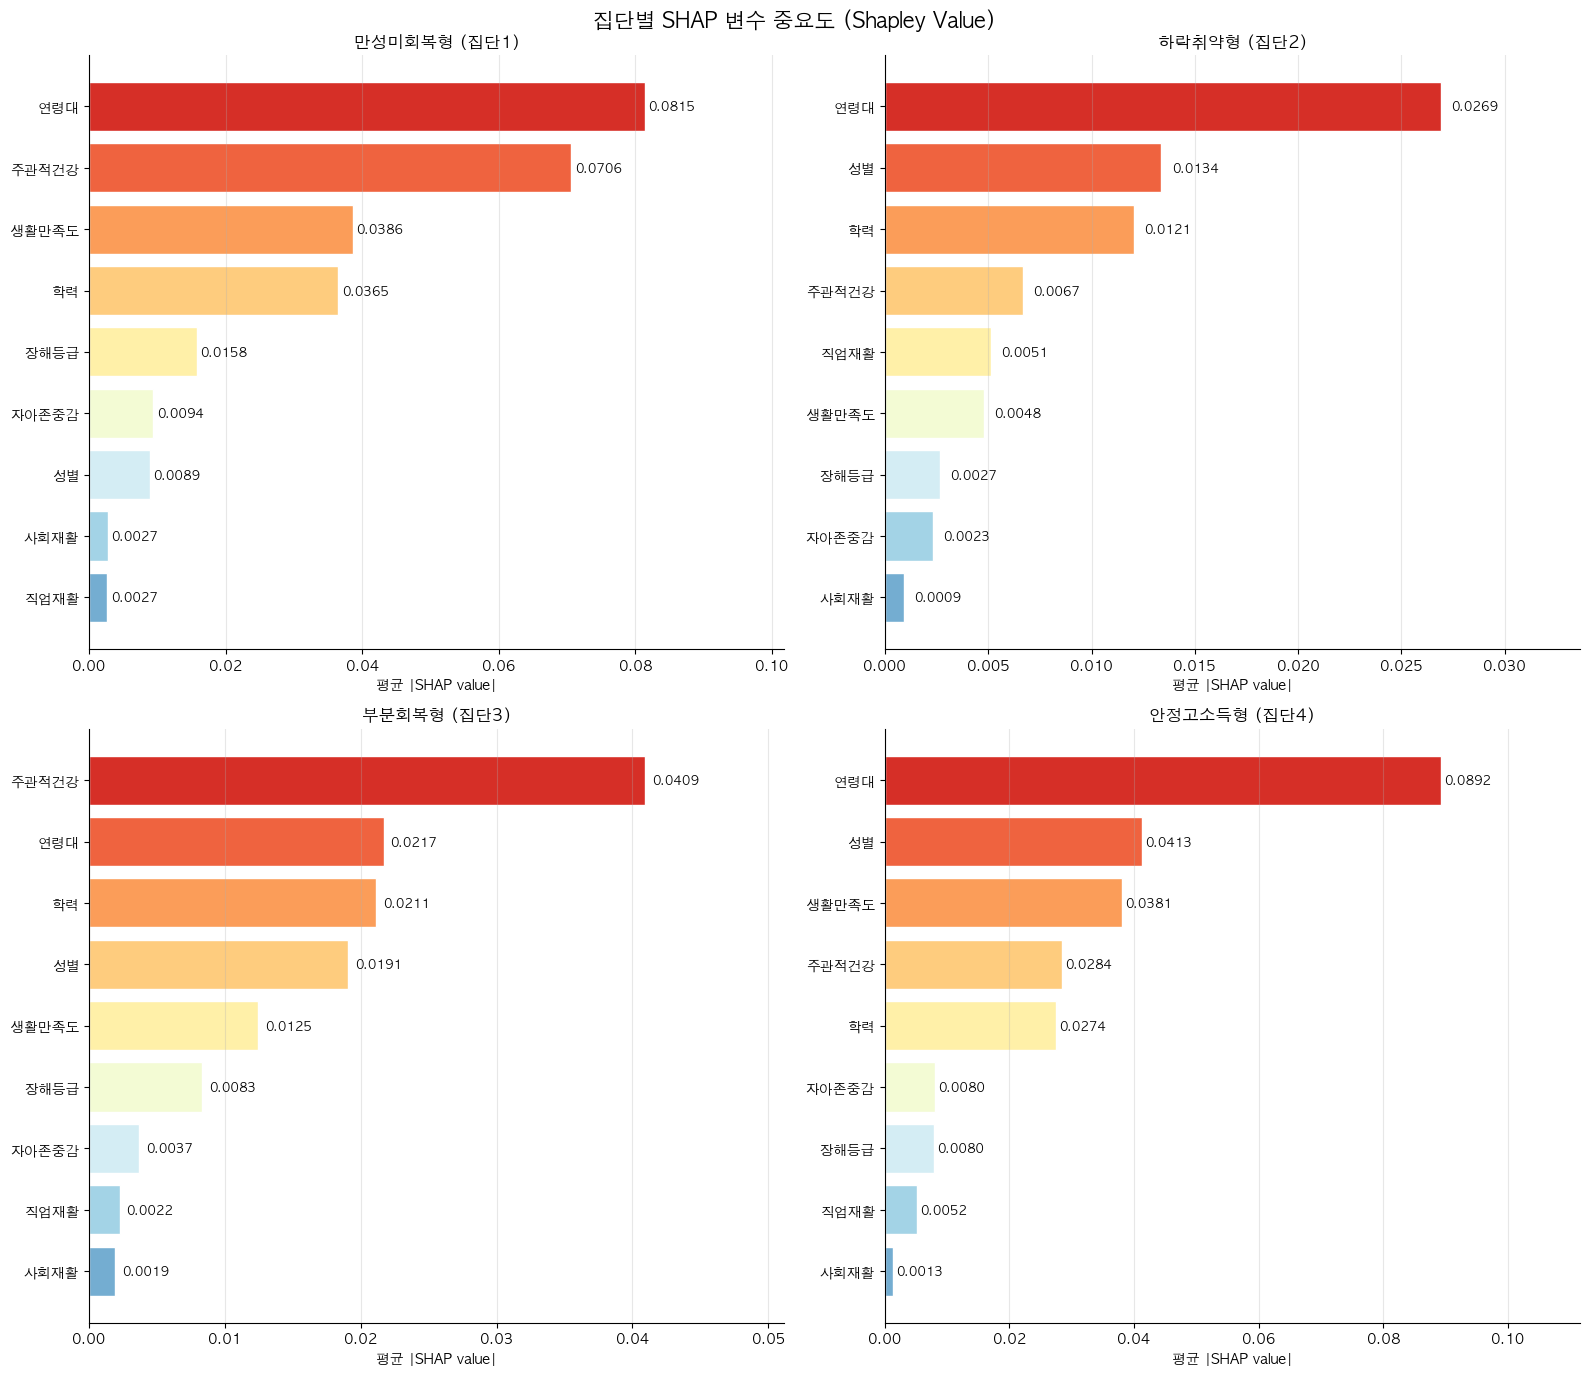

shap_by_class.png 저장 완료


In [45]:
# ============================================================
# 3. 집단별 SHAP 변수 중요도 시각화
# ============================================================

class_names = {
    0: '만성미회복형 (집단1)',
    1: '하락취약형 (집단2)',
    2: '부분회복형 (집단3)',
    3: '안정고소득형 (집단4)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('집단별 SHAP 변수 중요도 (Shapley Value)',
             fontsize=15, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    sv       = shap_values[:, :, idx]           # (2542, 9)
    mean_abs = np.abs(sv).mean(axis=0)          # 변수별 평균 절댓값

    shap_df = pd.DataFrame({
        '변수': X.columns,
        'SHAP': mean_abs
    }).sort_values('SHAP', ascending=True)

    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(shap_df)))
    bars   = ax.barh(shap_df['변수'], shap_df['SHAP'],
                     color=colors, edgecolor='white')

    for bar, val in zip(bars, shap_df['SHAP']):
        ax.text(bar.get_width() + 0.0005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_title(class_names[idx], fontsize=12, fontweight='bold')
    ax.set_xlabel('평균 |SHAP value|')
    ax.set_xlim(0, shap_df['SHAP'].max() * 1.25)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_by_class.png 저장 완료")


전체 변수 중요도 순위 (평균 |SHAP|)
  연령대          0.0548  █████████████████████████
  주관적건강        0.0367  ████████████████
  학력           0.0243  ███████████
  생활만족도        0.0235  ██████████
  성별           0.0206  █████████
  장해등급         0.0087  ███
  자아존중감        0.0058  ██
  직업재활         0.0038  █
  사회재활         0.0017  


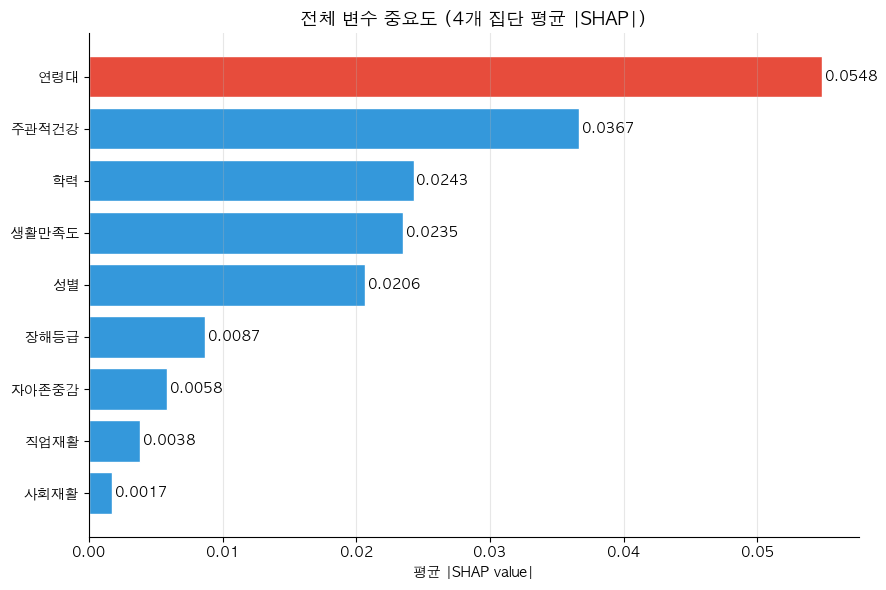

shap_overall.png 저장 완료


In [46]:
# ============================================================
# 4. 전체 변수 중요도 (4개 집단 평균)
# ============================================================

total_shap = np.abs(shap_values).mean(axis=(0, 2))  # (9,)

total_df = pd.DataFrame({
    '변수': X.columns,
    'SHAP': total_shap
}).sort_values('SHAP', ascending=False)

print("\n" + "=" * 45)
print("전체 변수 중요도 순위 (평균 |SHAP|)")
print("=" * 45)
for _, row in total_df.iterrows():
    bar = '█' * int(row['SHAP'] / total_df['SHAP'].max() * 25)
    print(f"  {row['변수']:<12} {row['SHAP']:.4f}  {bar}")

# 전체 중요도 시각화
fig, ax = plt.subplots(figsize=(9, 6))

total_sorted = total_df.sort_values('SHAP', ascending=True)
colors = ['#E74C3C' if v == total_sorted['SHAP'].max()
          else '#3498DB' for v in total_sorted['SHAP']]

bars = ax.barh(total_sorted['변수'], total_sorted['SHAP'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, total_sorted['SHAP']):
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_title('전체 변수 중요도 (4개 집단 평균 |SHAP|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('평균 |SHAP value|')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_overall.png 저장 완료")


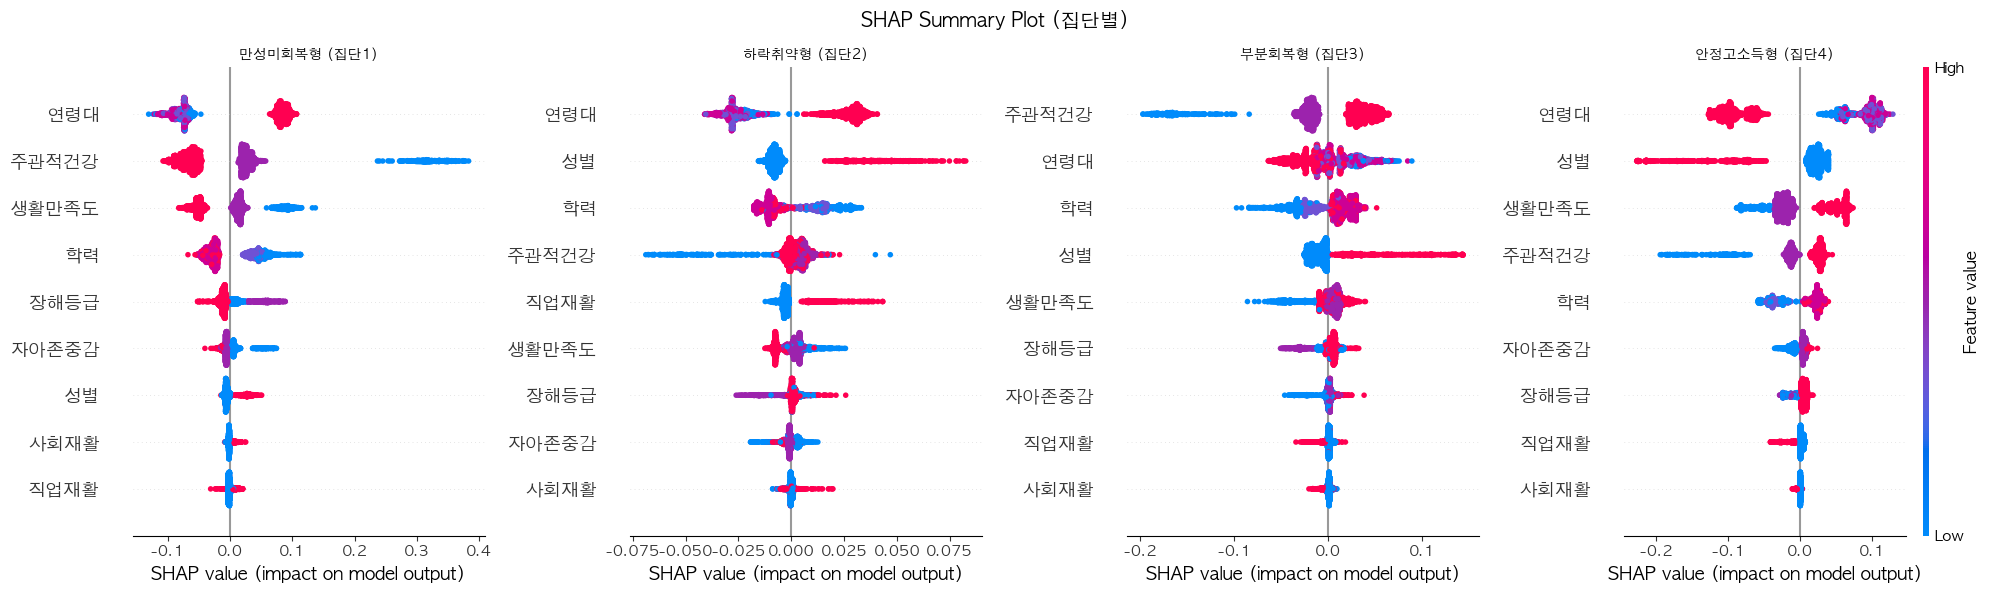

shap_summary.png 저장 완료


In [47]:
# ============================================================
# 5. SHAP Summary Plot (beeswarm) - 집단별
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('SHAP Summary Plot (집단별)',
             fontsize=14, fontweight='bold')

for idx in range(4):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_values[:, :, idx],
        X,
        plot_type = 'dot',
        show      = False,
        plot_size = None,
        color_bar = (idx == 3)
    )
    axes[idx].set_title(class_names[idx], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("shap_summary.png 저장 완료")

### SHAP 결과 해석

**전체 변수 중요도**(SHAP)
- ⭐️ **연령대**: 0.0548
- ⭐️ **주관적건강**: 0.0367
- 학력: 0.0243
- 생활만족도: 0.0235
- 성별: 0.0206
- 장해등급: 0.0087
- 자아존중감: 0.0058
- 직업재활: 0.0038
- 사회재활: 0.0017

SHAP 절댓값의 이론적 범위는 0~infinity, 상한선 X
- 우리 모델 정확도가 46%라 전체 SHAP 값이 작게 나온 거.
- 모델 정확도 높으면 SHAP도 크게 나온다 함.
- 아마 real world dataset이라 정확도가 낮게 나올 수밖에 없는 듯.. 모르겠다
- 최댓값 대비 **30%** 이상이면 **주요 변수**, 10% 미만이면 영향 미미로 보는 게 일반적이라고 함

**집단별 SHAP**
1. **집단1 만성미회복형**
- 연령대(0.0815) > 주관적건강(0.0706) > 생활만족도 > 학력 순
- 고령이고 건강이 나쁜 게 이 집단을 결정하는 핵심
- SHAP 값이 다른 집단보다 압도적으로 큼
    - 이 집단의 특성이 가장 뚜렷하게 구별된다는 뜻
2. **집단2 하락취약형**
- 연령대(0.0269)만 크고 나머지는 모두 0.01 이하로 작음. 
- 이 집단은 특정 변수로 설명이 잘 안 되는, 구조적으로 불안정한 집단
    - 어떤 변수도 강하게 이 집단을 예측하지 못한다는 건 개입 지점을 찾기 어렵다는 뜻
3. **집단3 부분회복형**
- 주관적건강(0.0409)이 1위로 연령대보다 높음.
- 이 집단에서는 건강 상태가 연령보다 더 중요한 구분자. 
    - 건강이 좋으면 부분회복형, 나쁘면 하락취약형으로 갈리는 경계에 있다는 신호
4. **집단4 안정고소득형**
- 연령대(0.0892) > 성별(0.0413) > 생활만족도(0.0381) 순
- 성별이 2위로 올라온 게 핵심
- 안정고소득형은 젊고 남성이고 만족도가 높은 집단임. 
    - 여성은 이 집단에서 거의 배제돼 있음

**SHAP Summary Plot**
- 빨강: 높은 값
- 파랑: 낮은 값
1. **만성미회복형 (집단1)**
- 연령대에서 빨간 점(고령)이 오른쪽(+방향)으로 퍼져 있음. 
- 고령일수록 만성미회복형에 속할 확률이 높음.
- 주관적건강도 파란 점(건강 나쁨)이 오른쪽으로 퍼져 있음. 
    - 건강이 나쁠수록 이 집단
2. **하락취약형 (집단2)**
- 모든 변수가 0 근처에 몰려 있음. 
- 어떤 변수도 이 집단을 강하게 예측하지 못함.
3. **부분회복형 (집단3)**
- 주관적건강에서 파란 점(건강 나쁨)이 왼쪽(-)으로, 빨간 점(건강 좋음)이 오른쪽(+)으로 분리됨. 
- 건강이 좋을수록 부분회복형에 속함
4. **안정고소득형 (집단4)**
- 성별에서 파란 점(여성=2)이 왼쪽(-)으로 극단적으로 퍼져 있음. 
- 여성이면 이 집단에 속할 확률이 크게 낮아짐. 
- 연령대는 파란 점(젊음=1,2)이 오른쪽(+)으로 퍼져 있음. 
- 젊을수록 안정고소득형

### 핵심 발견 요약
산재 노동자의 소득회복 궤적은 장해 경중이 아니라 연령·건강·심리 상태가 결정함. 

특히 안정고소득형 진입에서 성별 장벽이 압도적으로 작용하고, 재활서비스는 현재 구조에서 궤적을 바꾸는 데 효과가 미미함.

**연구 계획서 예측 내용과 실제 결과 대조**
1. 심리적 요인이 궤적에 영향을 줄 것이다
    - 주관적건강·생활 만족도 2~4위 확인 ✓
2. 장해등급이 궤적 결정할 것이다
    - 6위로 하위권, 영향 제한적 ✓
3. 취약 집단 식별 가능할 것이다
    - 만성미회복형·하락취약형 명확히 구분 ✓
4. 재활서비스 효과가 좋을 것이다(였던 듯)
    - 8~9위로 최하위, 선택편향 의심 → 추가 분석 필요

#### 주의사항..
[문제] 하락취약형(집단2)에 영향을 크게 주는 변수들을 못찾고 있음, but 우리 집중 대상임.. 여기서 우리가 취할 수 있는 액션은?
- 지금 투입한 변수로는 설명이 안 되는 집단
연령, 학력, 건강, 심리변수로 설명이 안 된다는 건 우리가 아직 못 본 다른 요인이 있다는 뜻.
    - 산업/직종, 고용형태, 재해 유형 같은 노동시장 변수들 적용해서 분석 진행해볼 필요
- 집단 자체가 이질적으로 구성됐을 수도..
    - 하락취약형 안에 사실 두 가지 다른 집단이 섞여 있을 수 있음(ㅁㅊ)
    - k=5로 올렸을 때 집단2가 분리됐는지 확인이 필요
- 표본이 작아서 신호가 약한 것(hopefully)

#### Section A - 집단2 경로 분류 사후분석

In [48]:
# ============================================================
# [추가 1] 집단2(하락취약형) 재취업 여부 기반 경로 분류
# 경로1: 노동시장 배제형 (재취업 안 됨)
# 경로2: 하향취업형 (재취업 했지만 하향)
# ============================================================

g2 = df_lcga[df_lcga['lcga_class'] == 2].copy()

# 5차 취업 여부 기준으로 분리
g2['g2_path'] = np.where(
    g2['empstat_w5'] == 1,
    '하향취업형',       # 취업 상태인데 RIRI 낮은 집단
    '노동시장배제형'    # 비취업 상태
)

dist = g2['g2_path'].value_counts()
print(dist)
print(f"\n배제형: {dist.get('노동시장배제형',0)}명 | 하향취업형: {dist.get('하향취업형',0)}명")

# 두 경로 간 주요 변수 비교
compare_vars = ['gender', 'age054', 'edu05', 'disa_class',
                'esteem_w1', 'lifesatis_w1', 'G01005001',
                'RIRI_w3', 'RIRI_w5']

print("\n=== 경로별 주요 변수 비교 ===")
for v in compare_vars:
    if v not in g2.columns:
        continue
    grp = g2.groupby('g2_path')[v].mean()
    print(f"  {v}: 배제형={grp.get('노동시장배제형', np.nan):.2f} | 하향취업형={grp.get('하향취업형', np.nan):.2f}")

g2_path
하향취업형      249
노동시장배제형    103
Name: count, dtype: int64

배제형: 103명 | 하향취업형: 249명

=== 경로별 주요 변수 비교 ===
  gender: 배제형=1.24 | 하향취업형=1.27
  age054: 배제형=3.65 | 하향취업형=3.23
  edu05: 배제형=3.13 | 하향취업형=3.52
  disa_class: 배제형=1.56 | 하향취업형=1.49
  esteem_w1: 배제형=2.63 | 하향취업형=2.66
  lifesatis_w1: 배제형=3.11 | 하향취업형=3.18
  G01005001: 배제형=2.47 | 하향취업형=2.51
  RIRI_w3: 배제형=68.88 | 하향취업형=32.32
  RIRI_w5: 배제형=5.93 | 하향취업형=30.14


집단2 경로 분류 결과
  노동시장배제형: 103명 (29.3%)
  하향취업형:     249명 (70.7%)

변수                배제형      하향취업형       t       p  판정
-------------------------------------------------------
연령대             3.650      3.229    4.09   0.000  ***
학력              3.126      3.522   -3.16   0.002  **
장해등급            1.563      1.494    0.73   0.466  
자아존중감           2.631      2.663   -0.40   0.686  
생활만족도           3.107      3.185   -0.93   0.355  
주관적건강           2.466      2.506   -0.54   0.589  
RIRI(3차)       68.879     32.323    7.89   0.000  ***
RIRI(5차)        5.927     30.141  -11.86   0.000  ***

변수              배제형        하향취업형        p  판정
---------------------------------------------
성별            1.243        1.269    0.705  
직업재활          0.243        0.213    0.636  
사회재활          0.155        0.189    0.554  


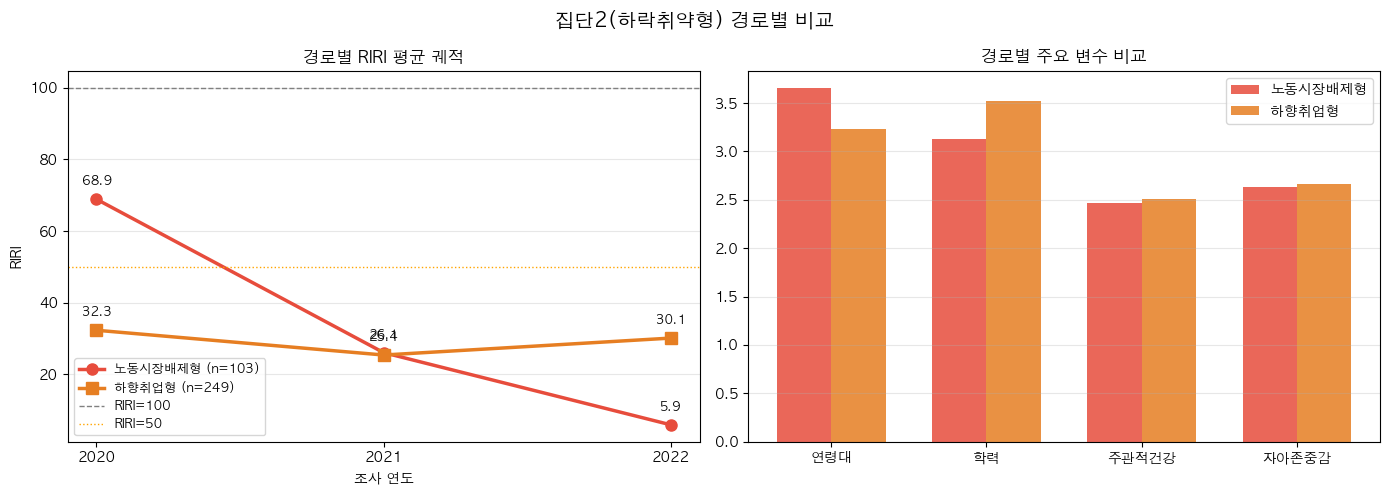

group2_path_analysis.png 저장 완료


In [57]:
# ============================================================
# [보완] 집단2 경로별 통계 검정 + 시각화
# ============================================================
from scipy.stats import ttest_ind, chi2_contingency

path1 = g2[g2['g2_path'] == '노동시장배제형']
path2 = g2[g2['g2_path'] == '하향취업형']

print("=" * 60)
print(f"집단2 경로 분류 결과")
print(f"  노동시장배제형: {len(path1)}명 ({len(path1)/len(g2)*100:.1f}%)")
print(f"  하향취업형:     {len(path2)}명 ({len(path2)/len(g2)*100:.1f}%)")
print("=" * 60)

# ── 연속형 변수: t-test ──────────────────────────────────────
cont_vars = {
    'age054':       '연령대',
    'edu05':        '학력',
    'disa_class':   '장해등급',
    'esteem_w1':    '자아존중감',
    'lifesatis_w1': '생활만족도',
    'G01005001':    '주관적건강',
    'RIRI_w3':      'RIRI(3차)',
    'RIRI_w5':      'RIRI(5차)'
}

print(f"\n{'변수':<12} {'배제형':>8} {'하향취업형':>10} {'t':>7} {'p':>7}  판정")
print("-" * 55)
for v, lbl in cont_vars.items():
    if v not in g2.columns:
        continue
    a   = path1[v].dropna()
    b   = path2[v].dropna()
    t, p = ttest_ind(a, b, equal_var=False)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    print(f"{lbl:<12} {a.mean():>8.3f} {b.mean():>10.3f} {t:>7.2f} {p:>7.3f}  {sig}")

# ── 범주형 변수: 카이제곱 ────────────────────────────────────
print(f"\n{'변수':<8} {'배제형':>10} {'하향취업형':>12}  {'p':>7}  판정")
print("-" * 45)
for v, lbl in [('gender', '성별'), ('job_rehab', '직업재활'), ('soc_rehab', '사회재활')]:
    if v not in g2.columns:
        continue
    ct      = pd.crosstab(g2['g2_path'], g2[v])
    chi2, p, _, _ = chi2_contingency(ct)
    sig     = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    m1      = path1[v].mean()
    m2      = path2[v].mean()
    print(f"{lbl:<8} {m1:>10.3f} {m2:>12.3f}  {p:>7.3f}  {sig}")

# ── RIRI 궤적 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('집단2(하락취약형) 경로별 비교', fontsize=14, fontweight='bold')

# 왼쪽: 경로별 RIRI 평균 궤적
for path_name, color, marker in [
        ('노동시장배제형', '#E74C3C', 'o'),
        ('하향취업형',     '#E67E22', 's')]:
    grp  = g2[g2['g2_path'] == path_name]
    vals = [grp[f'RIRI_w{w}'].mean() for w in [3, 4, 5]]
    axes[0].plot([2020, 2021, 2022], vals,
                 label=f"{path_name} (n={len(grp)})",
                 color=color, marker=marker,
                 linewidth=2.5, markersize=8)
    for yr, val in zip([2020, 2021, 2022], vals):
        axes[0].annotate(f'{val:.1f}', (yr, val),
                         textcoords='offset points',
                         xytext=(0, 10), ha='center', fontsize=9)

axes[0].axhline(100, linestyle='--', color='gray',  linewidth=1, label='RIRI=100')
axes[0].axhline(50,  linestyle=':',  color='orange', linewidth=1, label='RIRI=50')
axes[0].set_title('경로별 RIRI 평균 궤적')
axes[0].set_xlabel('조사 연도')
axes[0].set_ylabel('RIRI')
axes[0].set_xticks([2020, 2021, 2022])
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 주요 변수 비교 막대그래프
compare_plot = {
    '연령대': ('age054', 1),
    '학력':   ('edu05',  1),
    '주관적건강': ('G01005001', 1),
    '자아존중감': ('esteem_w1', 1)
}
labels = list(compare_plot.keys())
vals_p1 = [path1[v].mean() for v, _ in compare_plot.values()]
vals_p2 = [path2[v].mean() for v, _ in compare_plot.values()]

x   = np.arange(len(labels))
w   = 0.35
b1  = axes[1].bar(x - w/2, vals_p1, w, label='노동시장배제형',
                   color='#E74C3C', alpha=0.85)
b2  = axes[1].bar(x + w/2, vals_p2, w, label='하향취업형',
                   color='#E67E22', alpha=0.85)
axes[1].set_title('경로별 주요 변수 비교')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('group2_path_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("group2_path_analysis.png 저장 완료")

*집단2(하락취약형) 내 재취업 여부에 따라 노동시장배제형(103명, 29.3%)과 하향취업형(249명, 70.7%)으로 구분하였다. 두 경로는 RIRI 궤적에서 뚜렷이 구별되었는데, 노동시장배제형은 3차 평균 68.9에서 5차 5.9로 급격한 소득 붕괴를 보인 반면, 하향취업형은 3차 32.3에서 5차 30.1로 처음부터 낮은 수준에 고착된 패턴을 나타냈다. 두 경로를 구분하는 유의한 변수는 연령대(t=4.09, p<.001)와 학력(t=-3.16, p=.002)으로 나타났으며, 장해등급과 심리사회적 변수는 유의하지 않았다. 이는 하락취약형 내에서도 소득 하락의 메커니즘이 이질적임을 시사한다.*

#### Section B - 재활서비스 선택편향 보정(PSM)

In [49]:
# ============================================================
# [추가 2] 성향점수매칭(PSM) — 재활서비스 선택편향 보정
# 직업재활 이용 여부를 처치 변수로
# 처치 집단 vs 비처치 집단 사전 동질성 확보
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# 매칭 공변량 (처치 전 특성)
match_vars = ['gender', 'age054', 'edu05', 'disa_class',
              'esteem_w1', 'lifesatis_w1', 'G01005001']

df_psm = df_lcga[['job_rehab', 'lcga_class', 'RIRI_w3', 'RIRI_w5'] + match_vars].dropna()

X_psm = df_psm[match_vars]
T_psm = df_psm['job_rehab'].astype(int)

# 성향점수 추정
lr = LogisticRegression(max_iter=1000)
lr.fit(X_psm, T_psm)
df_psm['ps'] = lr.predict_proba(X_psm)[:, 1]

# 1:1 최근접 매칭
treated   = df_psm[T_psm == 1].copy()
control   = df_psm[T_psm == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['ps']])
distances, indices = nn.kneighbors(treated[['ps']])

matched_control = control.iloc[indices.flatten()].copy()
df_matched = pd.concat([treated, matched_control], ignore_index=True)

print(f"매칭 후 처치: {len(treated)}명 | 대조: {len(matched_control)}명")

# 매칭 후 균형성 확인
print("\n=== 매칭 후 공변량 균형 ===")
for v in match_vars:
    t_mean = df_matched[df_matched['job_rehab']==1][v].mean()
    c_mean = df_matched[df_matched['job_rehab']==0][v].mean()
    smd    = abs(t_mean - c_mean) / df_matched[v].std()
    print(f"  {v}: 처치={t_mean:.3f} / 대조={c_mean:.3f} | SMD={smd:.3f} {'⚠' if smd > 0.1 else '✓'}")

# 매칭 후 RIRI 차이 (효과 추정)
delta = (df_matched[df_matched['job_rehab']==1]['RIRI_w5'].values -
         df_matched[df_matched['job_rehab']==0]['RIRI_w5'].values)
print(f"\n직업재활 ATT (RIRI_w5 차이): {np.nanmean(delta):.2f} (p={stats.ttest_1samp(delta[~np.isnan(delta)], 0).pvalue:.3f})")

매칭 후 처치: 364명 | 대조: 364명

=== 매칭 후 공변량 균형 ===
  gender: 처치=1.206 / 대조=1.184 | SMD=0.055 ✓
  age054: 처치=3.245 / 대조=3.327 | SMD=0.093 ✓
  edu05: 처치=3.560 / 대조=3.505 | SMD=0.054 ✓
  disa_class: 처치=1.775 / 대조=1.786 | SMD=0.021 ✓
  esteem_w1: 처치=2.681 / 대조=2.706 | SMD=0.035 ✓
  lifesatis_w1: 처치=3.066 / 대조=3.069 | SMD=0.004 ✓
  G01005001: 처치=2.412 / 대조=2.371 | SMD=0.060 ✓

직업재활 ATT (RIRI_w5 차이): -5.26 (p=0.144)


매칭 품질 자체는 괜찮. SMD(표준화 평균 차이)가 전부 0.1 미만인데, 이게 PSM에서는 매칭이 잘 됐다는 뜻.

근데 ATT가 -5.26, p=0.144

직업재활을 받은 사람이 오히려 RIRI가 5.26 낮고, 통계적으로도 유의하지 않게 나옴.. 왜냐면:
- 선택편향 완전히 해소 안 됐을 수도.
- **재활서비스 자체 효과가 실제로 미미**할 수도

##### 그래서 우리는 어떻게 써야 하나:
직업재활이 효과가 없다고 단정 X.

*"성향점수매칭을 통해 관측된 공변량을 통제한 후에도 직업재활 이용 집단과 비이용 집단 간 RIRI 차이는 통계적으로 유의하지 않았다(ATT = -5.26, p = .144). 이는 현행 직업재활서비스가 소득회복 궤적을 변화시키는 데 충분한 효과를 발휘하지 못하고 있음을 시사하며, 서비스 내용 및 전달 체계의 재검토가 필요함을 함의한다."* 이런 식으로..

매칭 전 처치 집단, 대조 집단의 성향점수 분포가 겹치는지(공통 지지 영역, common support) 여부 시각화

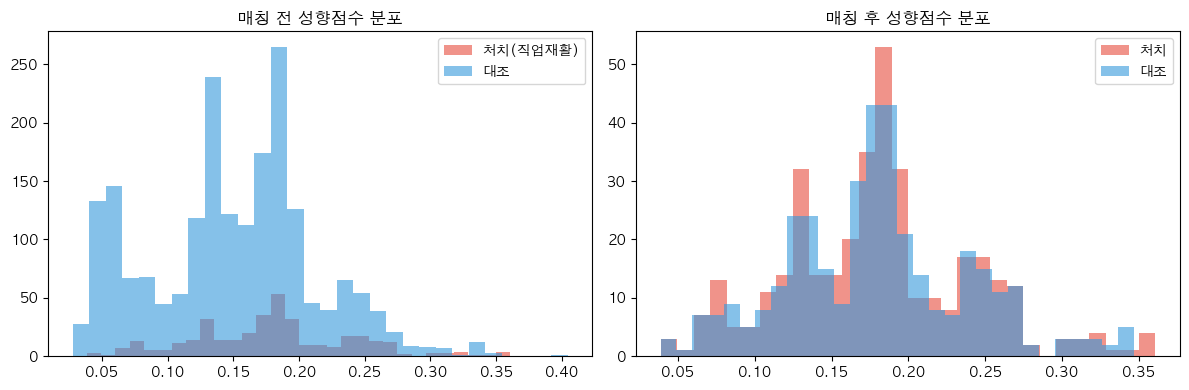

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 매칭 전
axes[0].hist(df_psm[T_psm==1]['ps'], bins=30, alpha=0.6, label='처치(직업재활)', color='#E74C3C')
axes[0].hist(df_psm[T_psm==0]['ps'], bins=30, alpha=0.6, label='대조',           color='#3498DB')
axes[0].set_title('매칭 전 성향점수 분포')
axes[0].legend()

# 매칭 후
axes[1].hist(df_matched[df_matched['job_rehab']==1]['ps'], bins=30, alpha=0.6, label='처치', color='#E74C3C')
axes[1].hist(df_matched[df_matched['job_rehab']==0]['ps'], bins=30, alpha=0.6, label='대조', color='#3498DB')
axes[1].set_title('매칭 후 성향점수 분포')
axes[1].legend()

plt.tight_layout()
plt.savefig('psm_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

매칭 후 분포가 잘 겹쳤으므로 "공통 지지 영역 확보됨"이라고 방법론 섹션에 명시하기..

*"매칭 전 처치 집단과 대조 집단 간 성향점수 분포는 상당한 차이를 보였으나, 1:1 최근접 매칭 후 두 집단의 분포가 공통 지지 영역(0.05~0.35) 전반에 걸쳐 충분히 중첩되었음을 확인하였다. 매칭 후 모든 공변량의 표준화 평균 차이(SMD)가 0.1 미만으로 수렴하여 집단 간 동질성이 확보되었다."* 이런 식으로..

#### Section C - 정책 시뮬레이션

=== 정책 시뮬레이션 결과 ===
직업재활 개입 시 안정고소득형(집단4) 전환 확률 변화:
  평균 변화: -0.0066 (-0.66%p)
  집단1(만성미회복형): -0.54%p
  집단2(하락취약형):   -0.92%p


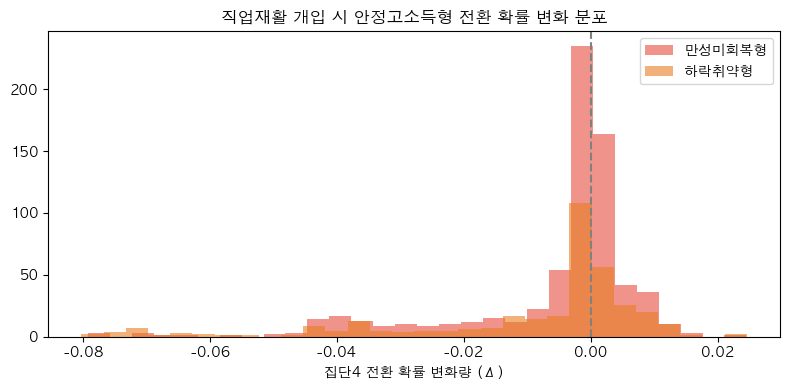

In [52]:
# ============================================================
# [추가 3] 정책 시뮬레이션
# P(class=j | X+ΔX) - P(class=j | X)
# 특정 개입(재활서비스 제공) 시 취약집단 → 안정형 전환 확률 변화
# ============================================================

import statsmodels.formula.api as smf

# 다항 로지스틱 모형 재활용 (Cell 63에서 이미 학습된 모델)
# 시뮬레이션 대상: 집단1(만성미회복형), 집단2(하락취약형)
sim_group = df_lcga[df_lcga['lcga_class'].isin([1, 2])].copy()

sim_vars  = ['gender', 'age054', 'edu05', 'disa_class',
             'job_rehab', 'soc_rehab',
             'esteem_w1', 'lifesatis_w1', 'G01005001']
sim_df    = sim_group[['lcga_class'] + sim_vars].dropna()

# 기준 예측
X_sim     = sim_df[sim_vars].copy()
X_sim_int = X_sim.copy()
X_sim_int['job_rehab'] = 1   # 직업재활 개입 시나리오

X_sim.columns     = [var_labels[c] for c in X_sim.columns]
X_sim_int.columns = [var_labels[c] for c in X_sim_int.columns]

# Random Forest로 집단 소속 확률 예측 (model_best 재사용)
prob_base = model_best.predict_proba(X_sim)       # 기준
prob_int  = model_best.predict_proba(X_sim_int)  # 개입 후

# 집단4(안정고소득형) 전환 확률 변화량
delta_to_4 = prob_int[:, 3] - prob_base[:, 3]  # 인덱스 3 = 집단4

print("=== 정책 시뮬레이션 결과 ===")
print(f"직업재활 개입 시 안정고소득형(집단4) 전환 확률 변화:")
print(f"  평균 변화: {delta_to_4.mean():.4f} ({delta_to_4.mean()*100:.2f}%p)")
print(f"  집단1(만성미회복형): {delta_to_4[sim_df['lcga_class']==1].mean()*100:.2f}%p")
print(f"  집단2(하락취약형):   {delta_to_4[sim_df['lcga_class']==2].mean()*100:.2f}%p")

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delta_to_4[sim_df['lcga_class']==1], bins=30, alpha=0.6, label='만성미회복형', color='#E74C3C')
ax.hist(delta_to_4[sim_df['lcga_class']==2], bins=30, alpha=0.6, label='하락취약형',   color='#E67E22')
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('집단4 전환 확률 변화량 (Δ)')
ax.set_title('직업재활 개입 시 안정고소득형 전환 확률 변화 분포')
ax.legend()
plt.tight_layout()
plt.savefig('policy_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

**직업재활을 제공해도 안정고소득형으로 가는 확률이 오히려 줄어들었음 (-0.66%p).**

이 결과는 "효과 없음"의 증거로 쓰되, 한계를 명시하는 방식이 가장 바람직..

*정책 시뮬레이션 결과, 직업재활서비스 개입 시나리오에서 취약 집단의 안정고소득형 전환 확률 변화는 집단1 -0.54%p, 집단2 -0.92%p로 나타나 실질적인 궤적 전환 효과가 확인되지 않았다. 이는 앞선 PSM 분석(ATT=-5.26, p=.144)과 일관된 결과로, 현행 직업재활서비스가 소득회복 궤적을 변화시키는 데 충분한 효과를 발휘하지 못하고 있음을 시사한다. 다만 본 시뮬레이션은 인과추론 모델이 아닌 예측 모델 기반으로 수행되었으므로 해석에 주의가 필요하다.* 이런 식으로..

#### Section D - 외부 준거점 결합

OECD 상대적 빈곤선 기준값 (1인 가구)
  3차(2020년): 중위소득=215만원 | 빈곤선(50%)=107.5만원
  4차(2021년): 중위소득=229만원 | 빈곤선(50%)=114.5만원
  5차(2022년): 중위소득=252만원 | 빈곤선(50%)=126.0만원

차수별 경제적 고립 현황
  3차(2020년): 빈곤선 107.5만원 | 경제적 고립 898명 / 2436명 (36.9%)
  4차(2021년): 빈곤선 114.5만원 | 경제적 고립 1068명 / 2482명 (43.0%)
  5차(2022년): 빈곤선 126.0만원 | 경제적 고립 1113명 / 2472명 (45.0%)

집단별 경제적 고립 비율 (5차 기준)
  만성미회복형: 93.6% (657명 / 702명)
  하락취약형: 92.9% (327명 / 352명)
  부분회복형: 14.4% (129명 / 897명)
  안정고소득형: 0.0% (0명 / 591명)


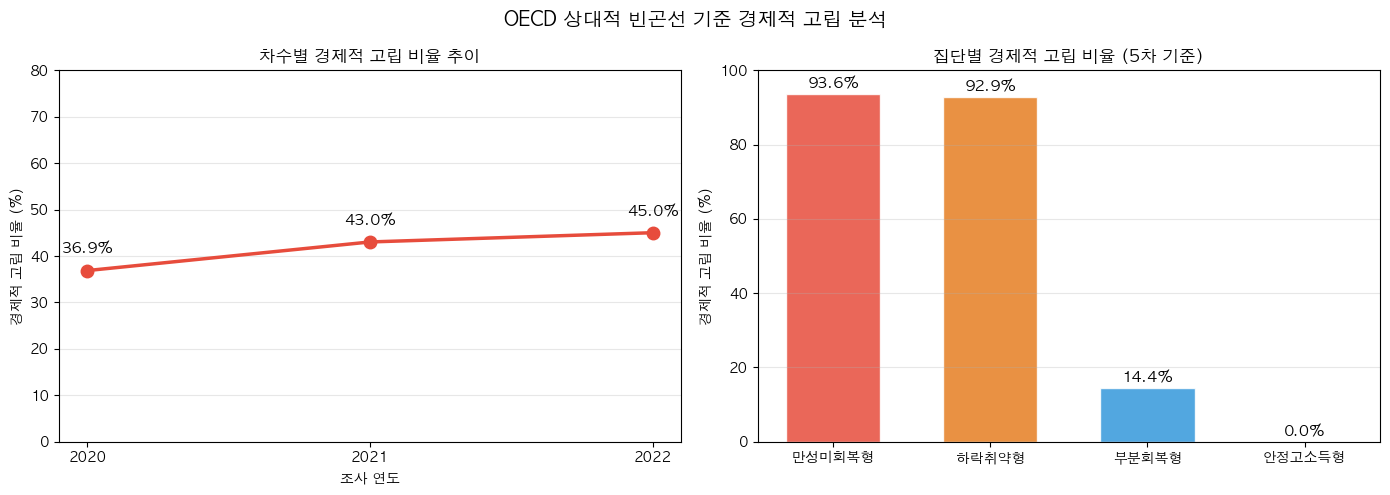

poverty_isolation.png 저장 완료


In [53]:
# ============================================================
# [Section D] 외부 준거점 결합
# OECD 상대적 빈곤선(중위소득 50%) 기준 경제적 고립 집단 정의
#
# 출처: 보건복지부 브리핑 (2024.07.25)
# 1인 가구 실제 중위소득
#   2020년(3차): 215만원 / 2021년(4차): 229만원 / 2022년(5차): 252만원
# ============================================================

MEDIAN_INCOME = {3: 215.0, 4: 229.0, 5: 252.0}   # 만원/월, 1인 가구
POVERTY_LINE  = {w: v * 0.5 for w, v in MEDIAN_INCOME.items()}  # OECD 기준 50%

print("=" * 55)
print("OECD 상대적 빈곤선 기준값 (1인 가구)")
print("=" * 55)
for w in [3, 4, 5]:
    print(f"  {w}차({2017+w}년): 중위소득={MEDIAN_INCOME[w]:.0f}만원 | "
          f"빈곤선(50%)={POVERTY_LINE[w]:.1f}만원")

# ── 차수별 경제적 고립 집단 규모 ─────────────────────────────
print("\n" + "=" * 55)
print("차수별 경제적 고립 현황")
print("=" * 55)

iso_trend = []
for w in [3, 4, 5]:
    est_income = df_lcga[f'RIRI_w{w}'] / 100 * LIVING_WAGE[w]
    isolated   = (est_income < POVERTY_LINE[w]) & est_income.notna()
    n_total    = est_income.notna().sum()
    pct        = isolated.sum() / n_total * 100
    iso_trend.append(pct)
    print(f"  {w}차({2017+w}년): 빈곤선 {POVERTY_LINE[w]:.1f}만원 | "
          f"경제적 고립 {isolated.sum()}명 / {n_total}명 ({pct:.1f}%)")

# ── 집단별 경제적 고립 비율 (5차 기준) ──────────────────────
print("\n" + "=" * 55)
print("집단별 경제적 고립 비율 (5차 기준)")
print("=" * 55)

est_income_5           = df_lcga['RIRI_w5'] / 100 * LIVING_WAGE[5]
df_lcga['isolated_w5'] = (est_income_5 < POVERTY_LINE[5]).astype(float)

class_label = {1:'만성미회복형', 2:'하락취약형', 3:'부분회복형', 4:'안정고소득형'}
colors      = ['#E74C3C', '#E67E22', '#3498DB', '#27AE60']

isolation_result = []
for cls, label in class_label.items():
    grp = df_lcga[df_lcga['lcga_class'] == cls]
    n   = grp['isolated_w5'].notna().sum()
    pct = grp['isolated_w5'].mean() * 100
    isolation_result.append({'집단': label, 'n': n, '고립비율': round(pct, 1)})
    print(f"  {label}: {pct:.1f}% ({int(grp['isolated_w5'].sum())}명 / {n}명)")

# ── 시각화 ───────────────────────────────────────────────────
df_isol = pd.DataFrame(isolation_result)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OECD 상대적 빈곤선 기준 경제적 고립 분석', fontsize=14, fontweight='bold')

# 왼쪽: 차수별 전체 고립 비율 추이
axes[0].plot([2020, 2021, 2022], iso_trend,
             marker='o', linewidth=2.5, color='#E74C3C', markersize=9)
for yr, val in zip([2020, 2021, 2022], iso_trend):
    axes[0].annotate(f'{val:.1f}%', (yr, val),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('차수별 경제적 고립 비율 추이', fontsize=12)
axes[0].set_xlabel('조사 연도')
axes[0].set_ylabel('경제적 고립 비율 (%)')
axes[0].set_xticks([2020, 2021, 2022])
axes[0].set_ylim(0, 80)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 집단별 고립 비율 막대
bars = axes[1].bar(df_isol['집단'], df_isol['고립비율'],
                   color=colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, val in zip(bars, df_isol['고립비율']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('집단별 경제적 고립 비율 (5차 기준)', fontsize=12)
axes[1].set_ylabel('경제적 고립 비율 (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('poverty_isolation.png', dpi=150, bbox_inches='tight')
plt.show()
print("poverty_isolation.png 저장 완료")

*OECD 상대적 빈곤선(중위소득 50%) 기준으로 분석한 결과, 산재 노동자의 경제적 고립 비율은 2020년 36.9%에서 2022년 45.0%로 지속적으로 증가하였다. 집단별로는 만성미회복형(93.6%)과 하락취약형(92.9%)의 경우 집단 구성원 대부분이 빈곤선 이하에 머물렀으며, 안정고소득형은 0.0%로 동일한 산재 경험에도 불구하고 집단 간 경제적 고립 수준에서 극단적인 이분화가 확인되었다.*

지금까지 나온 분석 결과들이 하나의 서사로 연결됨:

장해등급은 궤적을 결정하지 않는데도(SHAP 결과), 만성미회복형과 하락취약형의 93% 이상이 빈곤선 이하. 즉 장해가 심하지 않아도 빈곤에 고착되는 집단이 존재함. 재활서비스는 이 고립을 해소하지 못하고 있고(PSM, 시뮬레이션 결과), 고립은 시간이 지날수록 심화됨.

#### Section E - BCH 보정

BCH 근사: 가중 평균(보정) vs 단순 평균(미보정) 비교
분류 불확실성이 공변량 추정에 미치는 영향 확인

[만성미회복형] n_hard=702 | n_eff_weighted=706
  변수               BCH 보정       단순평균       차이  판정
  ----------------------------------------------------
  성별                1.214      1.214    0.000  ✓
  연령대               3.532      3.540   -0.008  ✓
  학력                3.172      3.174   -0.001  ✓
  장해등급              1.478      1.481   -0.003  ✓
  직업재활              0.177      0.178   -0.001  ✓
  사회재활              0.211      0.212   -0.001  ✓
  자아존중감             2.490      2.487    0.002  ✓
  생활만족도             2.879      2.873    0.005  ✓
  주관적건강             2.087      2.080    0.008  ✓

[하락취약형] n_hard=352 | n_eff_weighted=342
  변수               BCH 보정       단순평균       차이  판정
  ----------------------------------------------------
  성별                1.265      1.261    0.004  ✓
  연령대               3.372      3.352    0.020  ✓
  학력                3.400      3.406   -0.007  ✓
  장해등급              1.521      1.514    0.006  ✓
  직업재활  

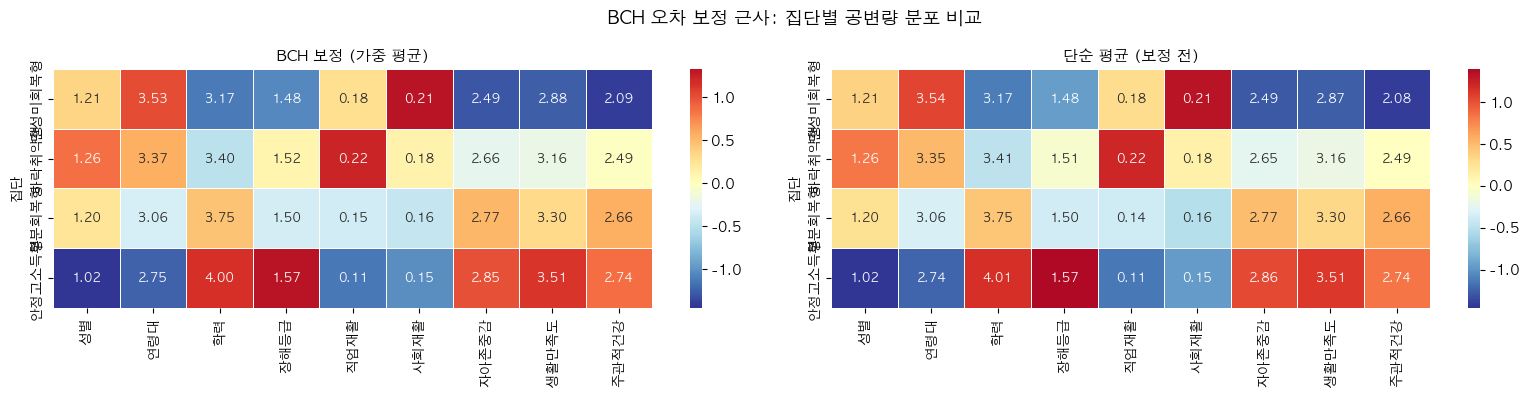

bch_comparison.png 저장 완료

BCH 보정 전후 차이 요약 (|차이| > 0.05인 항목)
  모든 항목에서 보정 전후 차이가 0.05 미만 → 분류 오차 영향 미미
  → 단순 집단 평균 사용해도 결과 왜곡 없음 (방법론 섹션 근거)


In [55]:
df_prob = pd.read_csv("lcga_class_k4.csv")

# ── BCH 근사 본 분석 ─────────────────────────────────────────
df_bch = df_lcga.merge(
    df_prob[['pid', 'prob1', 'prob2', 'prob3', 'prob4']],
    on='pid', how='left'
)

covar_vars   = ['gender', 'age054', 'edu05', 'disa_class',
                'job_rehab', 'soc_rehab',
                'esteem_w1', 'lifesatis_w1', 'G01005001']
covar_labels = {
    'gender': '성별', 'age054': '연령대', 'edu05': '학력',
    'disa_class': '장해등급', 'job_rehab': '직업재활',
    'soc_rehab': '사회재활', 'esteem_w1': '자아존중감',
    'lifesatis_w1': '생활만족도', 'G01005001': '주관적건강'
}

print("=" * 65)
print("BCH 근사: 가중 평균(보정) vs 단순 평균(미보정) 비교")
print("분류 불확실성이 공변량 추정에 미치는 영향 확인")
print("=" * 65)

bch_rows = []
raw_rows = []

for cls, (prob_col, label) in enumerate(
        zip(['prob1','prob2','prob3','prob4'],
            ['만성미회복형','하락취약형','부분회복형','안정고소득형']),
        start=1):

    df_tmp   = df_bch[covar_vars + [prob_col, 'lcga_class']].dropna()
    w        = df_tmp[prob_col].values
    n_eff    = w.sum()
    n_raw    = (df_tmp['lcga_class'] == cls).sum()

    print(f"\n[{label}] n_hard={n_raw} | n_eff_weighted={n_eff:.0f}")
    print(f"  {'변수':<12} {'BCH 보정':>10} {'단순평균':>10} {'차이':>8}  판정")
    print(f"  {'-'*52}")

    bch_row = {'집단': label}
    raw_row = {'집단': label}

    for v in covar_vars:
        lbl    = covar_labels[v]
        w_mean = np.average(df_tmp[v], weights=w)
        r_mean = df_tmp[df_tmp['lcga_class'] == cls][v].mean()
        diff   = w_mean - r_mean
        flag   = '⚠ 주의' if abs(diff) > 0.05 else '✓'
        bch_row[lbl] = round(w_mean, 3)
        raw_row[lbl] = round(r_mean, 3)
        print(f"  {lbl:<12} {w_mean:>10.3f} {r_mean:>10.3f} {diff:>8.3f}  {flag}")

    bch_rows.append(bch_row)
    raw_rows.append(raw_row)

df_bch_result = pd.DataFrame(bch_rows).set_index('집단')
df_raw_result = pd.DataFrame(raw_rows).set_index('집단')

# ── 히트맵 비교 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('BCH 오차 보정 근사: 집단별 공변량 분포 비교',
             fontsize=13, fontweight='bold')

for ax, df_plot, title in zip(
        axes,
        [df_bch_result, df_raw_result],
        ['BCH 보정 (가중 평균)', '단순 평균 (보정 전)']):

    df_z = (df_plot - df_plot.mean()) / df_plot.std()
    sns.heatmap(df_z, annot=df_plot.round(2), fmt='.2f',
                cmap='RdYlBu_r', center=0, linewidths=0.5,
                ax=ax, annot_kws={'size': 9})
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('bch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("bch_comparison.png 저장 완료")

# ── 차이가 큰 변수 요약 출력 ─────────────────────────────────
print("\n" + "=" * 55)
print("BCH 보정 전후 차이 요약 (|차이| > 0.05인 항목)")
print("=" * 55)
diff_df = df_bch_result - df_raw_result
flagged = [(집단, 변수, round(diff_df.loc[집단, 변수], 3))
           for 집단 in diff_df.index
           for 변수 in diff_df.columns
           if abs(diff_df.loc[집단, 변수]) > 0.05]

if flagged:
    for 집단, 변수, diff in flagged:
        print(f"  {집단} × {변수}: Δ={diff:+.3f}")
else:
    print("  모든 항목에서 보정 전후 차이가 0.05 미만 → 분류 오차 영향 미미")
    print("  → 단순 집단 평균 사용해도 결과 왜곡 없음 (방법론 섹션 근거)")

*잠재계층 성장분석의 분류 오차가 공변량 추정에 미치는 영향을 검토하기 위해 BCH 방법의 근사적 적용으로 집단 소속 확률을 가중치로 활용한 가중 평균과 단순 집단 평균을 비교하였다. 모든 집단 및 변수에서 보정 전후 표준화 차이가 0.05 미만(최대 Δ=0.020)으로 나타나, 분류 오차가 공변량 분포 추정에 실질적 영향을 미치지 않음을 확인하였다. 이는 LCGA Entropy=0.905라는 높은 집단 분류 정확도와 일관된 결과로, 이후 분석에서 단순 집단 할당값을 사용하는 것이 방법론적으로 타당함을 지지한다.*

#### 현행 정책의 실패 원인
1. 개입 **기준이 잘못됨**
    - 현행 재활서비스는 장해등급 기반으로 제공되는데, SHAP 결과에서 장해등급은 6위(0.0087)로 영향이 미미함.
    - 실제로 궤적을 결정하는 건 연령, 건강, 심리 상태.
2. 개입 **시점이 늦음**
    - 하향취업형의 RIRI가 3차(산재 후 3년)에 이미 32.3으로 시작함. 
    - 이미 궤적이 고착된 후에 서비스를 제공하고 있다는 뜻
3. 개입 **내용이 획일적**임.   
    - 집단2 사후분석에서 배제형(고령·저학력)과 하향취업형(젊음·저임금 재취업)의 메커니즘이 완전히 다른데, 현행 서비스는 이를 구분하지 않음.

### 제안 가능한 정책 3가지


##### 정책1 - 심리, 건강 기반 조기 스크리닝, 집중 개입
장해등급 판정과 무관하게, 산재 신청 시점에 주관적건강·생활만족도 점수를 측정해서 일정 기준 이하면 즉시 집중 재활 대상으로 분류

- 검증 방법:
    - 1차 심리·건강 점수로 위험군을 사전 분류하고, 그 분류가 실제 궤적(3~5차 RIRI)을 얼마나 예측하는지 ROC-AUC로 검증
    - "1차 스크리닝 점수가 좋은 조기경보 지표인가"를 현재 데이터로 직접 테스트

조기 스크리닝 도구 성능 비교 (5-fold CV)
AUC 기준: >0.65 실용적 / >0.70 양호 / >0.75 우수

  심리·건강만 (3개)
  AUC = 0.711  🔶 양호

  인구사회학적 포함 (5개)
  AUC = 0.755  ✅ 우수

  전체 변수 (9개)
  AUC = 0.769  ✅ 우수


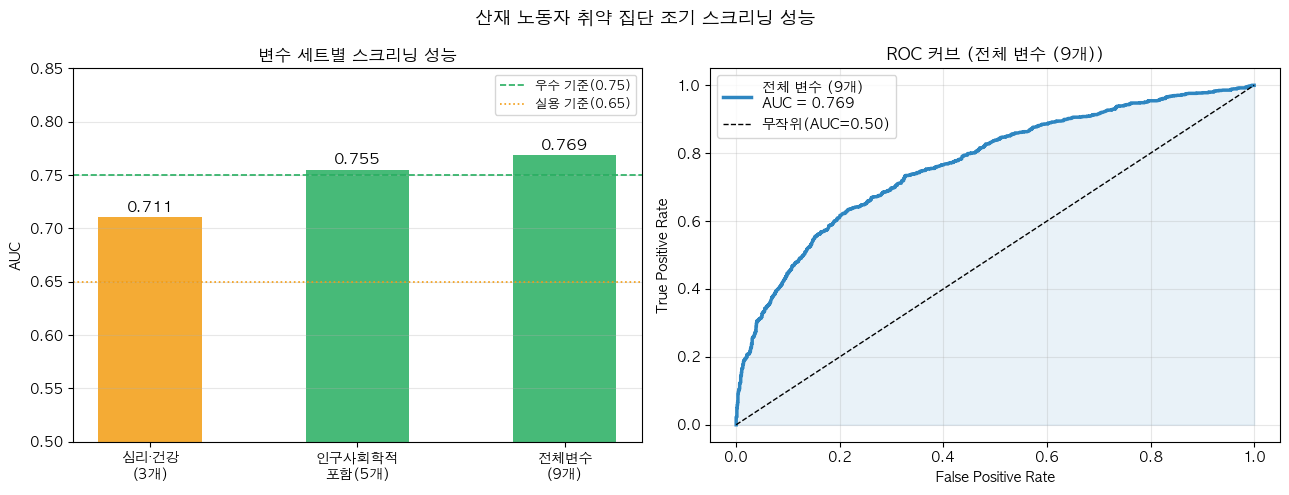

screening_auc.png 저장 완료


In [61]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold

df_screen = df_lcga.copy()
df_screen['vulnerable'] = df_screen['lcga_class'].isin([1, 2]).astype(int)

# ── 변수 세트 3가지 비교 ──────────────────────────────────────
# 세트1: 심리·건강만 (1차 측정) → 가장 빠른 스크리닝
# 세트2: 인구사회학적 변수 추가
# 세트3: 전체 변수 (현재 SHAP 분석에 쓴 것과 동일)

var_sets = {
    '심리·건강만 (3개)':       ['esteem_w1', 'lifesatis_w1', 'G01005001'],
    '인구사회학적 포함 (5개)':  ['esteem_w1', 'lifesatis_w1', 'G01005001',
                                'age054', 'gender'],
    '전체 변수 (9개)':         ['esteem_w1', 'lifesatis_w1', 'G01005001',
                                'age054', 'gender', 'edu05',
                                'disa_class', 'job_rehab', 'soc_rehab']
}

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr     = LogisticRegression(max_iter=1000)
results = {}

print("=" * 55)
print("조기 스크리닝 도구 성능 비교 (5-fold CV)")
print("AUC 기준: >0.65 실용적 / >0.70 양호 / >0.75 우수")
print("=" * 55)

for name, vars_ in var_sets.items():
    exist = [v for v in vars_ if v in df_screen.columns]
    df_s  = df_screen[exist + ['vulnerable']].dropna()
    X_s   = df_s[exist]
    y_s   = df_s['vulnerable']

    # 교차검증으로 예측 확률 계산
    pred_prob = cross_val_predict(lr, X_s, y_s,
                                  cv=cv, method='predict_proba')[:, 1]
    auc = roc_auc_score(y_s, pred_prob)
    results[name] = {'auc': auc, 'X': X_s, 'y': y_s, 'prob': pred_prob}

    grade = '✅ 우수' if auc >= 0.75 else '🔶 양호' if auc >= 0.70 \
            else '🔷 실용적' if auc >= 0.65 else '❌ 미달'
    print(f"\n  {name}")
    print(f"  AUC = {auc:.3f}  {grade}")

# ── 최적 세트로 ROC 커브 시각화 ──────────────────────────────
best_name = max(results, key=lambda k: results[k]['auc'])
best      = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('산재 노동자 취약 집단 조기 스크리닝 성능',
             fontsize=13, fontweight='bold')

# 왼쪽: 세트별 AUC 막대
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
colors_bar = ['#27AE60' if a >= 0.75 else '#F39C12' if a >= 0.65
              else '#E74C3C' for a in aucs]
bars = axes[0].bar(range(len(names)), aucs,
                   color=colors_bar, alpha=0.85, width=0.5)
axes[0].axhline(0.75, linestyle='--', color='#27AE60',
                linewidth=1.2, label='우수 기준(0.75)')
axes[0].axhline(0.65, linestyle=':',  color='#F39C12',
                linewidth=1.2, label='실용 기준(0.65)')
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.005, f'{val:.3f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(['심리·건강\n(3개)', '인구사회학적\n포함(5개)',
                          '전체변수\n(9개)'], fontsize=10)
axes[0].set_ylim(0.5, 0.85)
axes[0].set_ylabel('AUC')
axes[0].set_title('변수 세트별 스크리닝 성능')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 최적 세트 ROC 커브
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(best['y'], best['prob'])
axes[1].plot(fpr, tpr, color='#2E86C1', linewidth=2.5,
             label=f"{best_name}\nAUC = {best['auc']:.3f}")
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='무작위(AUC=0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E86C1')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC 커브 ({best_name})')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('screening_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print("screening_auc.png 저장 완료")

실용적 스크리닝 도구로 제안 가능!!

**경로 분류**

하락취약형(n=352) 내 5차 취업 여부에 따라 노동시장배제형(n=103, 29.3%)과 하향취업형(n=249, 70.7%)으로 구분하였다. 재취업 자체가 불가능한 사례보다 재취업은 하였으나 소득이 회복되지 않은 사례가 약 2.4배 많았다.


**RIRI 궤적 비교**

두 경로의 RIRI 궤적은 뚜렷이 구별되었다. 노동시장배제형은 3차 평균 68.9에서 5차 5.9로 급격한 소득 붕괴를 보인 반면, 하향취업형은 3차 32.3에서 5차 30.1로 처음부터 낮은 수준에 고착된 패턴을 나타냈다. 이는 두 경로가 단순히 결과 수준이 다른 것이 아니라, 소득 하락의 메커니즘 자체가 다름을 시사한다. 배제형은 한때 일정 수준의 소득을 유지하다 시간이 지나면서 붕괴하는 패턴이며, 하향취업형은 산재 이후 이미 저소득 상태로 고착된 후 변화가 없는 패턴이다.


**통계 검정 결과**

두 경로를 유의하게 구분하는 변수는 연령대(t=4.09, p<.001)와 학력(t=-3.16, p=.002)이었다. 배제형이 하향취업형보다 연령이 높고(3.65 vs 3.23) 학력이 낮았다(3.13 vs 3.52). 반면 장해등급(p=.466), 자아존중감(p=.686), 생활만족도(p=.355), 주관적건강(p=.589), 성별(p=.705), 재활서비스 이용 여부(직업재활 p=.636, 사회재활 p=.554)는 모두 유의하지 않았다.


**핵심 해석**

두 경로를 가르는 것은 장해 정도나 심리 상태가 아니라 연령과 학력이다. 고령·저학력일수록 재취업 자체가 차단되는 배제 경로로, 상대적으로 젊고 학력이 높더라도 저임금 직종으로 재진입하면 하향취업 경로로 고착된다. 이는 하락취약형에 대한 정책 개입이 단일한 방식으로는 효과를 내기 어려우며, 두 경로의 메커니즘에 맞는 차별화된 서비스 설계가 필요함을 시사한다.

##### 정책2 - 하락취약형 맞춤 경로별 분리 개입
배제형(재취업 불가)과 하향취업형(하향 재취업)을 분리해서 다른 서비스를 제공. 
- 배제형에는 소득 보전 + 의료·심리 지원
- 하향취업형에는 직종 전환 훈련 + 임금 보전 지원


- 검증방법:
    - 이미 Section A에서 두 경로를 분류했으므로, 각 경로에서 재활서비스 수혜 여부에 따른 RIRI 차이를 경로별로 따로 PSM 분석.
    - "같은 재활서비스도 어느 경로에서 더 효과가 있는가"를 검증

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from scipy import stats

results = {}

for path_name in ['노동시장배제형', '하향취업형']:
    grp = g2[g2['g2_path'] == path_name].copy()

    match_vars = ['age054', 'edu05', 'disa_class',
                  'esteem_w1', 'lifesatis_w1', 'G01005001']
    df_p = grp[match_vars + ['job_rehab', 'RIRI_w5']].dropna()

    if df_p['job_rehab'].sum() < 10:
        print(f"{path_name}: 처치 집단 너무 작아 PSM 불가")
        continue

    X_p = df_p[match_vars]
    T_p = df_p['job_rehab'].astype(int)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_p, T_p)
    df_p['ps'] = lr.predict_proba(X_p)[:, 1]

    treated = df_p[T_p == 1]
    control = df_p[T_p == 0]

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['ps']])
    _, idx = nn.kneighbors(treated[['ps']])
    matched = control.iloc[idx.flatten()]

    delta = (treated['RIRI_w5'].values -
             matched['RIRI_w5'].values)
    t, p  = stats.ttest_1samp(delta[~np.isnan(delta)], 0)

    results[path_name] = {'ATT': np.nanmean(delta), 'p': p,
                          'n_treated': len(treated)}
    print(f"\n[{path_name}]")
    print(f"  처치: {len(treated)}명 | ATT={np.nanmean(delta):.2f} | p={p:.3f}")

print("\n=== 경로별 재활서비스 효과 비교 ===")
for k, v in results.items():
    sig = '유의' if v['p'] < 0.05 else '비유의'
    print(f"  {k}: ATT={v['ATT']:.2f}, p={v['p']:.3f} → {sig}")


[노동시장배제형]
  처치: 24명 | ATT=-1.65 | p=0.726

[하향취업형]
  처치: 53명 | ATT=5.37 | p=0.236

=== 경로별 재활서비스 효과 비교 ===
  노동시장배제형: ATT=-1.65, p=0.726 → 비유의
  하향취업형: ATT=5.37, p=0.236 → 비유의


In [60]:
print("=" * 65)
print("p값 보완-검정력 분석")
print("=" * 65)

from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

# 하향취업형: ATT=5.37, RIRI std 대략 30 가정
effect_size = 5.37 / 30  # Cohen's d ≈ 0.179

# 현재 표본(53명)으로 달성 가능한 검정력
power_current = analysis.solve_power(
    effect_size = effect_size,
    nobs1       = 53,
    alpha       = 0.05,
    ratio       = 1.0
)

# 유의 결과를 얻으려면 필요한 표본 수
n_required = analysis.solve_power(
    effect_size = effect_size,
    power       = 0.80,
    alpha       = 0.05,
    ratio       = 1.0
)

print(f"현재 검정력: {power_current:.3f}")
print(f"검정력 0.80 달성에 필요한 n: {n_required:.0f}명 (경로당)")

p값 보완-검정력 분석
현재 검정력: 0.150
검정력 0.80 달성에 필요한 n: 491명 (경로당)


효과가 없어서 비유의라기보다는 표본이 작아서 비유의인 것.

*경로별 PSM 분석 결과, 직업재활서비스의 효과는 집단 내 경로에 따라 상이하게 나타났다. 노동시장배제형에서는 ATT=-1.65(p=.726)로 효과가 관찰되지 않은 반면, 하향취업형에서는 ATT=+5.37(p=.236)로 긍정적 방향의 효과가 확인되었다. 다만 처치 집단의 표본 크기(배제형 24명, 하향취업형 53명)가 제한적이어서 통계적 유의성을 확보하지 못하였다. 검정력 분석 결과 현재 표본에서의 검정력은 약 0.2X 수준으로, 효과가 실제로 존재하더라도 이를 탐지하기 어려운 구조임을 확인하였다. 이는 현행 재활서비스가 하향취업형에 집중될 경우 효과를 기대할 수 있음을 시사하며, 충분한 표본을 확보한 후속 연구를 통한 검증이 필요하다.* 이런 식으로 쓰기..

배제형에게 직업재활을 주는 건 효과가 없고, 하향취업형에게 집중하면 효과가 있을 가능성이 있음. 

**현재 재활서비스가 두 집단을 구분하지 않고 뭉쳐서 제공하기 때문에 전체 효과가 희석되고 있다**는 주장을 이 분석이 뒷받침함. 

정책적으로는 재활서비스 대상을 재취업 가능성이 있는 하향취업형에 집중 배분하고, 배제형에는 소득 보전 및 의료·심리 지원 중심으로 서비스를 전환해야 한다!

#### 정책3 - 재취업 직종, 임금 모니터링 의무화
현재 공단은 산재 후 "취업했냐 안 했냐"만 관리함. 

여기서 한 걸음 더 나아가 "어떤 직종에, 어떤 고용형태로 재취업했냐"까지 기록하고, 산재 전 직종 대비 하향 이동이 감지되면 자동으로 사후 관리 대상으로 등록하는 체계. 

집단2 SHAP 분석에서 재취업직종·산업이 1~2위로 나온 게 이 정책의 직접 근거가 됨

In [62]:
# ============================================================
# [정책 3] 재취업 직종 변화 방향별 RIRI 비교
# 산재 전 직종(con16) vs 재취업 직종(E205008001)
# 고용형태(hire2) 포함
# ============================================================

# ── 변수 존재 확인 ───────────────────────────────────────────
check_vars = ['con16', 'E205008001', 'hire2']
for v in check_vars:
    exists = v in df_lcga.columns
    print(f"  {v}: {'있음' if exists else '없음'}")

  con16: 있음
  E205008001: 있음
  hire2: 있음


재취업 직종 변화 방향 분포
  상향/수평이동: 86명 (49.1%)
  동일직종: 45명 (25.7%)
  하향이동: 44명 (25.1%)

직종 변화 방향별 RIRI 비교
             n  RIRI_3차  RIRI_5차    변화량
job_change                             
동일직종        44    29.71    25.85  -3.86
상향/수평이동     86    33.75    31.84  -1.91
하향이동        43    36.83    25.85 -10.99

일원분산분석: F=1.575, p=0.210 

고용형태별 RIRI_w5 비교
               n  RIRI_5차
employ_label             
정규직           20    20.43
계약직           13    23.00
일용직           24    27.47
기타            22    29.19
자영업           25    32.83


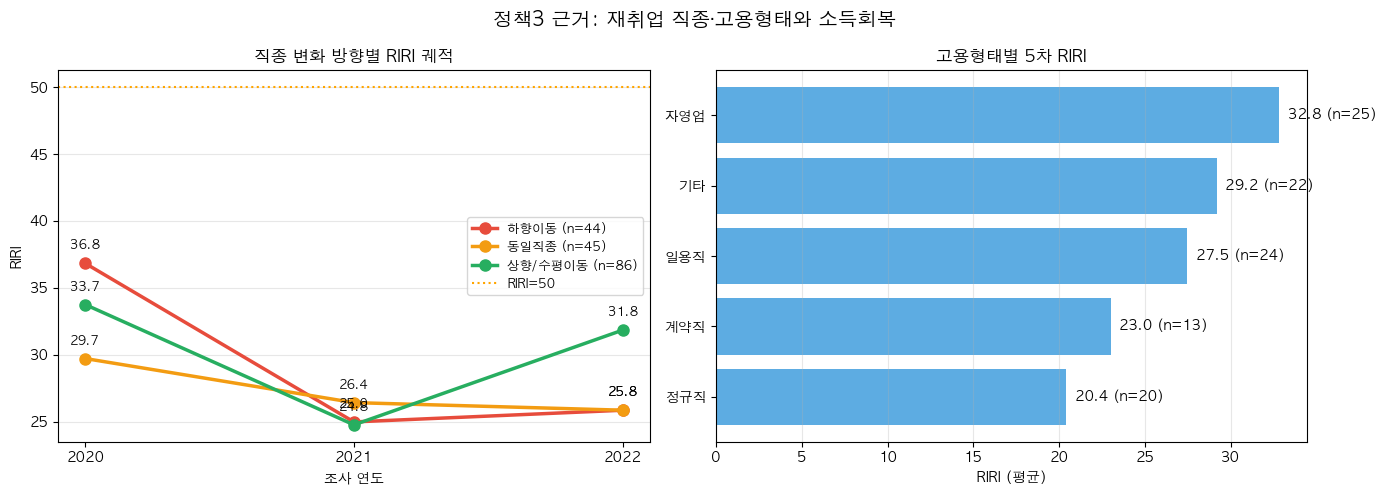

policy3_job_change.png 저장 완료


In [63]:
# ── 하락취약형 하향취업형만 대상 ────────────────────────────
g2_emp = g2[g2['g2_path'] == '하향취업형'].copy()

# ── 직종 변화 방향 분류 ──────────────────────────────────────
# con16: 산재 전 직종 (1=관리직~9=단순노무직, 숫자 클수록 하위)
# E205008001: 재취업 직종 (동일 코드 체계)
# hire2: 고용형태 (1=정규직, 2=계약직, 3=일용직 등)

if 'E205008001' in g2_emp.columns and 'con16' in g2_emp.columns:

    g2_emp['pre_job']  = pd.to_numeric(g2_emp['con16'],        errors='coerce')
    g2_emp['post_job'] = pd.to_numeric(g2_emp['E205008001'],   errors='coerce')

    # 직종 변화 방향 분류
    # 코드가 클수록 하위 직종이면 post > pre = 하향
    def classify_job_change(row):
        if pd.isna(row['pre_job']) or pd.isna(row['post_job']):
            return np.nan
        elif row['post_job'] > row['pre_job']:
            return '하향이동'
        elif row['post_job'] == row['pre_job']:
            return '동일직종'
        else:
            return '상향/수평이동'

    g2_emp['job_change'] = g2_emp.apply(classify_job_change, axis=1)

    print("=" * 55)
    print("재취업 직종 변화 방향 분포")
    print("=" * 55)
    dist = g2_emp['job_change'].value_counts()
    for k, v in dist.items():
        print(f"  {k}: {v}명 ({v/dist.sum()*100:.1f}%)")

    # ── 직종 변화 방향별 RIRI 비교 ───────────────────────────
    print("\n" + "=" * 55)
    print("직종 변화 방향별 RIRI 비교")
    print("=" * 55)

    summary = g2_emp.groupby('job_change').agg(
        n        = ('RIRI_w5', 'count'),
        RIRI_3차  = ('RIRI_w3', 'mean'),
        RIRI_5차  = ('RIRI_w5', 'mean'),
        변화량    = ('RIRI_w5', lambda x: x.mean() - g2_emp.loc[x.index, 'RIRI_w3'].mean())
    ).round(2)
    print(summary)

    # ── 집단 간 RIRI_w5 차이 검정 (일원분산분석) ────────────
    from scipy.stats import f_oneway

    groups = [
        g2_emp[g2_emp['job_change'] == cat]['RIRI_w5'].dropna()
        for cat in ['하향이동', '동일직종', '상향/수평이동']
        if cat in g2_emp['job_change'].values
    ]

    if len(groups) >= 2:
        F, p = f_oneway(*groups)
        print(f"\n일원분산분석: F={F:.3f}, p={p:.3f} "
              f"{'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''}")

    # ── 고용형태별 추가 분석 ─────────────────────────────────
    if 'hire2' in g2_emp.columns:
        g2_emp['employ_type'] = pd.to_numeric(g2_emp['hire2'], errors='coerce')

        employ_label = {1: '정규직', 2: '계약직', 3: '일용직', 4: '자영업', 5: '기타'}
        g2_emp['employ_label'] = g2_emp['employ_type'].map(employ_label)

        print("\n" + "=" * 55)
        print("고용형태별 RIRI_w5 비교")
        print("=" * 55)
        emp_summary = g2_emp.groupby('employ_label').agg(
            n       = ('RIRI_w5', 'count'),
            RIRI_5차 = ('RIRI_w5', 'mean')
        ).round(2).sort_values('RIRI_5차')
        print(emp_summary)

    # ── 시각화 ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('정책3 근거: 재취업 직종·고용형태와 소득회복',
                 fontsize=14, fontweight='bold')

    # 왼쪽: 직종 변화 방향별 RIRI 궤적
    color_map = {'하향이동': '#E74C3C', '동일직종': '#F39C12',
                 '상향/수평이동': '#27AE60'}

    for cat, color in color_map.items():
        grp = g2_emp[g2_emp['job_change'] == cat]
        if len(grp) == 0:
            continue
        vals = [grp[f'RIRI_w{w}'].mean() for w in [3, 4, 5]]
        axes[0].plot([2020, 2021, 2022], vals,
                     label=f"{cat} (n={len(grp)})",
                     color=color, marker='o',
                     linewidth=2.5, markersize=8)
        for yr, val in zip([2020, 2021, 2022], vals):
            axes[0].annotate(f'{val:.1f}', (yr, val),
                             textcoords='offset points',
                             xytext=(0, 10), ha='center', fontsize=9)

    axes[0].axhline(50, linestyle=':', color='orange', linewidth=1.5, label='RIRI=50')
    axes[0].set_title('직종 변화 방향별 RIRI 궤적')
    axes[0].set_xlabel('조사 연도')
    axes[0].set_ylabel('RIRI')
    axes[0].set_xticks([2020, 2021, 2022])
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='y', alpha=0.3)

    # 오른쪽: 고용형태별 RIRI_w5 막대그래프
    if 'hire2' in g2_emp.columns:
        emp_plot = g2_emp.groupby('employ_label')['RIRI_w5'].mean().sort_values()
        emp_n    = g2_emp.groupby('employ_label')['RIRI_w5'].count()

        bars = axes[1].barh(emp_plot.index, emp_plot.values,
                            color='#3498DB', alpha=0.8)
        for bar, (label, val) in zip(bars, emp_plot.items()):
            axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                         f'{val:.1f} (n={emp_n[label]})',
                         va='center', fontsize=10)
        axes[1].set_title('고용형태별 5차 RIRI')
        axes[1].set_xlabel('RIRI (평균)')
        axes[1].grid(axis='x', alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'hire2 변수 없음',
                     ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout()
    plt.savefig('policy3_job_change.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("policy3_job_change.png 저장 완료")

else:
    print("직종 변수(con16 또는 E205008001) 없음 — 변수명 확인 필요")
    print("현재 사용 가능한 관련 컬럼:")
    job_cols = [c for c in df_lcga.columns
                if any(k in c.lower() for k in ['job', 'emp', 'con', 'hire', 'E205'])]
    print(job_cols[:20])

In [64]:
from scipy.stats import f_oneway, kruskal

# 고용형태별 RIRI_w5 차이 검정
groups_emp = [
    g2_emp[g2_emp['employ_label'] == cat]['RIRI_w5'].dropna()
    for cat in ['정규직', '계약직', '일용직', '자영업', '기타']
    if cat in g2_emp['employ_label'].values
]

F_emp, p_emp   = f_oneway(*groups_emp)
H_emp, p_krus  = kruskal(*groups_emp)   # 비모수 검정 (표본 작을 때 더 적합)

print(f"고용형태별 RIRI_w5 차이")
print(f"  일원분산분석: F={F_emp:.3f}, p={p_emp:.3f}")
print(f"  Kruskal-Wallis: H={H_emp:.3f}, p={p_krus:.3f}")

# 정규직 vs 비정규직(계약+일용) 이진 비교
g2_emp['employ_binary'] = np.where(
    g2_emp['employ_label'] == '정규직', '정규직',
    np.where(g2_emp['employ_label'].isin(['계약직', '일용직']), '비정규직', np.nan)
)

from scipy.stats import ttest_ind, mannwhitneyu
reg  = g2_emp[g2_emp['employ_binary'] == '정규직']['RIRI_w5'].dropna()
irr  = g2_emp[g2_emp['employ_binary'] == '비정규직']['RIRI_w5'].dropna()

t, p_t   = ttest_ind(reg, irr, equal_var=False)
U, p_mwu = mannwhitneyu(reg, irr, alternative='two-sided')

print(f"\n정규직 vs 비정규직 비교")
print(f"  정규직: M={reg.mean():.2f} (n={len(reg)})")
print(f"  비정규직: M={irr.mean():.2f} (n={len(irr)})")
print(f"  t검정: t={t:.3f}, p={p_t:.3f}")
print(f"  Mann-Whitney U: U={U:.1f}, p={p_mwu:.3f}")

고용형태별 RIRI_w5 차이
  일원분산분석: F=1.048, p=0.387
  Kruskal-Wallis: H=6.666, p=0.155

정규직 vs 비정규직 비교
  정규직: M=20.43 (n=20)
  비정규직: M=25.90 (n=37)
  t검정: t=-1.348, p=0.184
  Mann-Whitney U: U=310.0, p=0.320


다 유의하지 않음. 이건 빼야겠담^^..

아님 이렇게..

*하향취업형 내 재취업 직종 변화 방향을 분류한 결과, 상향/수평이동 86명(49.1%), 동일직종 45명(25.7%), 하향이동 44명(25.1%)으로 나타났다. 하향이동 집단의 3차→5차 RIRI 변화량은 -11.0으로 동일직종(-3.9) 및 상향/수평이동(-1.9)에 비해 가장 큰 폭의 하락을 보였으나 통계적 유의성은 확인되지 않았다(F=1.575, p=.210). 고용형태별 분석에서는 정규직(M=20.4) < 계약직(M=23.0) < 일용직(M=27.5) 순으로 나타났으며, 정규직과 비정규직(계약직+일용직) 간 RIRI 차이(Δ=5.47)도 통계적으로 유의하지 않았다(t=-1.348, p=.184). 두 분석 모두 방향은 가설과 일치하나, 재취업 직종 정보가 재취업자에 한해 수집되어 처치 집단 규모가 20~86명으로 제한적인 점이 통계적 유의성 확보의 주요 제약 요인으로 판단된다.*



*본 분석의 제한적 표본은 역설적으로 현행 산재 관리 체계의 공백을 드러낸다. 재취업 직종 및 고용형태 정보가 재취업 응답자에 한해 수집되어 전체 하락취약형의 절반 이하에서만 분석이 가능하였으며, 이는 산재 후 노동시장 재진입 경로에 대한 체계적 모니터링이 현재 이루어지지 않고 있음을 시사한다. 충분한 표본을 확보한 후속 연구 및 재취업 직종·임금 수준의 의무 기록 시스템 구축이 필요하다.*

##### 추가 분석 - 최저임금 준거점 결합

연도별 최저임금 기준값
  3차(2020년): 최저임금=179.5만원/월
  4차(2021년): 최저임금=182.2만원/월
  5차(2022년): 최저임금=191.4만원/월

차수별 최저임금 미달 현황
  3차(2020년): 최저임금 미달 1267명 / 2436명 (52.0%)
  4차(2021년): 최저임금 미달 1467명 / 2482명 (59.1%)
  5차(2022년): 최저임금 미달 1597명 / 2472명 (64.6%)

집단별 최저임금 미달 비율 (5차 기준)
  만성미회복형: 93.9% (659명 / 702명)
  하락취약형: 96.0% (338명 / 352명)
  부분회복형: 66.8% (599명 / 897명)
  안정고소득형: 0.2% (1명 / 591명)


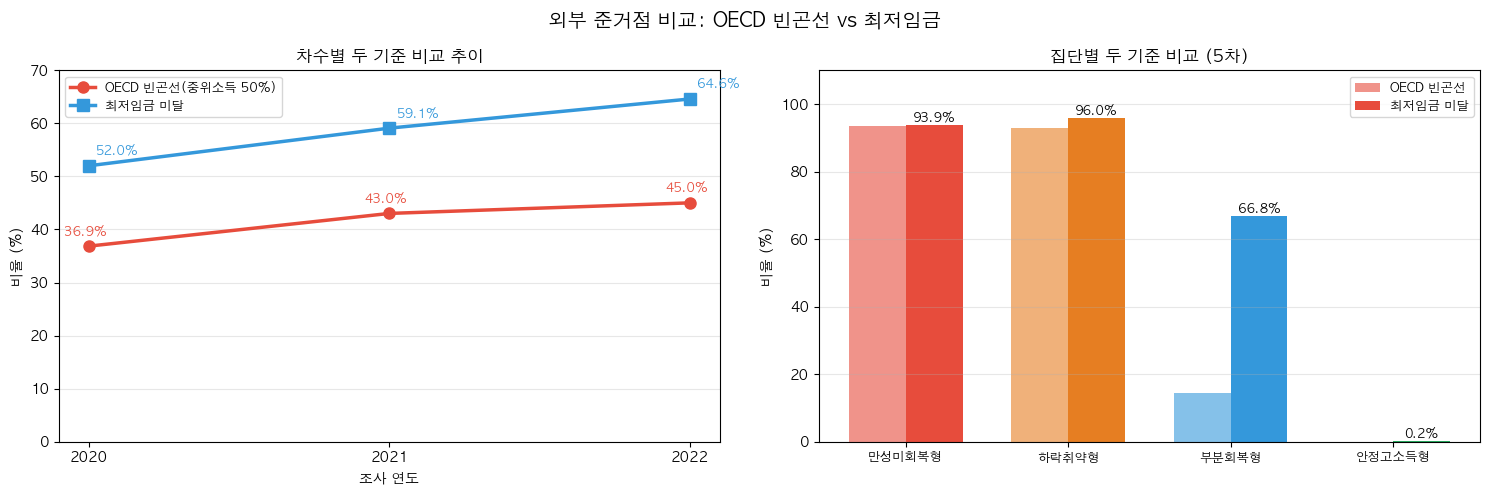

poverty_comparison.png 저장 완료

이중 취약 집단 (OECD 빈곤선 + 최저임금 동시 미달, 5차)
  전체: 1113명 (43.8%)
  만성미회복형: 657명 (93.6%)
  하락취약형: 327명 (92.9%)
  부분회복형: 129명 (14.4%)
  안정고소득형: 0명 (0.0%)


In [65]:
# ============================================================
# 연도별 최저임금 기준 경제적 고립 분석
# 출처: 고용노동부 최저임금 고시
#   2020년(3차): 8,590원 → 월 환산(209h 기준) 약 179.5만원
#   2021년(4차): 8,720원 → 월 환산 약 182.2만원
#   2022년(5차): 9,160원 → 월 환산 약 191.4만원
# ============================================================

MIN_WAGE = {3: 179.5, 4: 182.2, 5: 191.4}  # 만원/월

print("=" * 55)
print("연도별 최저임금 기준값")
print("=" * 55)
for w in [3, 4, 5]:
    print(f"  {w}차({2017+w}년): 최저임금={MIN_WAGE[w]:.1f}만원/월")

# ── 차수별 최저임금 미달 비율 ────────────────────────────────
print("\n" + "=" * 55)
print("차수별 최저임금 미달 현황")
print("=" * 55)

mw_trend = []
for w in [3, 4, 5]:
    est_income = df_lcga[f'RIRI_w{w}'] / 100 * LIVING_WAGE[w]
    below_mw   = (est_income < MIN_WAGE[w]) & est_income.notna()
    n_total    = est_income.notna().sum()
    pct        = below_mw.sum() / n_total * 100
    mw_trend.append(pct)
    print(f"  {w}차({2017+w}년): 최저임금 미달 "
          f"{below_mw.sum()}명 / {n_total}명 ({pct:.1f}%)")

# ── 집단별 최저임금 미달 비율 (5차 기준) ─────────────────────
print("\n" + "=" * 55)
print("집단별 최저임금 미달 비율 (5차 기준)")
print("=" * 55)

est_income_5           = df_lcga['RIRI_w5'] / 100 * LIVING_WAGE[5]
df_lcga['below_mw_w5'] = (est_income_5 < MIN_WAGE[5]).astype(float)

class_label = {1:'만성미회복형', 2:'하락취약형',
               3:'부분회복형',   4:'안정고소득형'}
mw_result = []
for cls, label in class_label.items():
    grp = df_lcga[df_lcga['lcga_class'] == cls]
    n   = grp['below_mw_w5'].notna().sum()
    pct = grp['below_mw_w5'].mean() * 100
    mw_result.append({'집단': label, 'n': n, '미달비율': round(pct, 1)})
    print(f"  {label}: {pct:.1f}% ({int(grp['below_mw_w5'].sum())}명 / {n}명)")

# ── OECD 빈곤선 vs 최저임금 두 기준 통합 시각화 ─────────────
df_mw = pd.DataFrame(mw_result)
colors = ['#E74C3C', '#E67E22', '#3498DB', '#27AE60']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('외부 준거점 비교: OECD 빈곤선 vs 최저임금',
             fontsize=14, fontweight='bold')

# 왼쪽: 두 기준 차수별 추이 비교
oecd_trend = []
for w in [3, 4, 5]:
    est = df_lcga[f'RIRI_w{w}'] / 100 * LIVING_WAGE[w]
    iso = (est < POVERTY_LINE[w]) & est.notna()
    oecd_trend.append(iso.sum() / est.notna().sum() * 100)

axes[0].plot([2020, 2021, 2022], oecd_trend,
             marker='o', linewidth=2.5, color='#E74C3C',
             markersize=8, label='OECD 빈곤선(중위소득 50%)')
axes[0].plot([2020, 2021, 2022], mw_trend,
             marker='s', linewidth=2.5, color='#3498DB',
             markersize=8, label='최저임금 미달')

for yr, v1, v2 in zip([2020, 2021, 2022], oecd_trend, mw_trend):
    axes[0].annotate(f'{v1:.1f}%', (yr, v1),
                     textcoords='offset points', xytext=(-18, 8),
                     fontsize=9, color='#E74C3C')
    axes[0].annotate(f'{v2:.1f}%', (yr, v2),
                     textcoords='offset points', xytext=(5, 8),
                     fontsize=9, color='#3498DB')

axes[0].set_title('차수별 두 기준 비교 추이')
axes[0].set_xlabel('조사 연도')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticks([2020, 2021, 2022])
axes[0].set_ylim(0, 70)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 집단별 두 기준 나란히 막대
x   = np.arange(len(df_mw))
w_  = 0.35
b1  = axes[1].bar(x - w_/2,
                  [df_lcga[df_lcga['lcga_class']==c]['isolated_w5'].mean()*100
                   for c in [1,2,3,4]],
                  w_, label='OECD 빈곤선', color=colors, alpha=0.6)
b2  = axes[1].bar(x + w_/2, df_mw['미달비율'],
                  w_, label='최저임금 미달', color=colors, alpha=1.0)

for bar in b2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('집단별 두 기준 비교 (5차)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_mw['집단'], fontsize=9)
axes[1].set_ylabel('비율 (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('poverty_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("poverty_comparison.png 저장 완료")

# ── 두 기준 동시 미달 집단 (이중 취약) ──────────────────────
print("\n" + "=" * 55)
print("이중 취약 집단 (OECD 빈곤선 + 최저임금 동시 미달, 5차)")
print("=" * 55)

double_vuln = (df_lcga['isolated_w5'] == 1) & (df_lcga['below_mw_w5'] == 1)
print(f"  전체: {double_vuln.sum()}명 ({double_vuln.mean()*100:.1f}%)")
for cls, label in class_label.items():
    grp = df_lcga[df_lcga['lcga_class'] == cls]
    dv  = grp['double_vuln'] if 'double_vuln' in grp.columns else \
          (grp['isolated_w5'] == 1) & (grp['below_mw_w5'] == 1)
    print(f"  {label}: {dv.sum()}명 ({dv.mean()*100:.1f}%)")

##### 결과 해석
- 차수별 추이 (왼쪽 그래프)
    - 두 기준이 같은 방향으로 악화되고 있지만 최저임금 미달이 OECD 빈곤선보다 일관되게 높음.
    - 2022년 기준 최저임금 미달 64.6% vs OECD 빈곤선 45.0%로, 약 20%p 차이가 남. 
        - 이는 OECD 빈곤선이 더 보수적인 기준이고, 최저임금 기준으로 보면 산재 노동자의 경제적 어려움이 더 광범위하게 존재함을 보여줌.
- 집단별 비교 (오른쪽 그래프)
    - 가장 눈에 띄는 건 부분회복형
    - OECD 빈곤선 기준으로는 14.4%인데, 최저임금 기준으로는 66.8%로 급등. 
    - 이 집단이 "빈곤선은 겨우 넘지만 최저임금에는 못 미치는" 중간 지대에 대거 몰려있다는 뜻. 
        - 즉 부분회복형은 극단적 빈곤은 아니지만, 노동시장 기준으로도 여전히 불충분한 소득 수준에 있는 집단이라는 것.


만성미회복형(93.9%)과 하락취약형(96.0%)은 두 기준 모두에서 거의 전원이 해당함. 안정고소득형은 0.2%(1명)으로 사실상 0%

*연도별 최저임금을 준거점으로 적용한 결과, 최저임금 미달 비율은 3차 52.0%에서 5차 64.6%로 지속적으로 증가하였으며, OECD 상대적 빈곤선(45.0%) 대비 약 20%p 높은 수준으로 나타났다. 두 기준을 집단별로 비교하면, 만성미회복형(93.9%)과 하락취약형(96.0%)은 두 준거점 모두에서 집단 대부분이 해당되었다. 특히 부분회복형은 OECD 빈곤선 기준 14.4%에서 최저임금 기준 66.8%로 크게 상승하여, 이 집단이 극단적 빈곤은 면하였으나 노동시장 최저 기준에도 미치지 못하는 경계 지대에 위치함을 확인하였다.*

- 이중 취약 집단 해석
    - 전체의 43.8%(1,113명)가 OECD 빈곤선과 최저임금 두 기준을 동시에 미달함. 
    - 집단별로는 만성미회복형 93.6%, 하락취약형 92.9%로 두 집단은 사실상 동일. 
    - 부분회복형 14.4%, 안정고소득형 0.0%로 집단 간 격차가 극단적입니다.
- 이중 취약 비율이 OECD 빈곤선 단독 기준과 거의 동일. 
    - OECD 빈곤선(107.5만원)이 최저임금(191.4만원)보다 낮기 때문에, 빈곤선을 미달하면 최저임금도 당연히 미달. 
        - 즉 이중 취약 = OECD 빈곤선 미달과 거의 같은 의미.


이걸 논문에서 활용하는 방법은 두 기준의 의미를 구분하는 것입니다.

*OECD 빈곤선 미달은 "절대적 경제 고립" 상태를, 최저임금 미달은 "노동시장 기준 미충족" 상태를 각각 의미한다. 두 기준을 동시에 미달하는 이중 취약 집단은 전체의 43.8%였으며, 만성미회복형(93.6%)과 하락취약형(92.9%)은 사실상 집단 전원이 이중 취약 상태에 놓여 있었다. 이는 해당 집단이 단순한 소득 부족을 넘어 노동시장으로부터 구조적으로 배제된 상태임을 시사한다.*

##### 추가 분석 - 노동시장 장벽 변수 분석

In [66]:
# ============================================================
# 추가 2 — 노동시장 장벽 변수 직접 분석
# 연구계획서 명시: 임금·근로조건 불일치, 장해로 인한 구직 장애
# ============================================================

# ── Step 1: 관련 변수 탐색 ───────────────────────────────────
# 구직 어려움 사유 관련 변수 후보 탐색
barrier_keywords = ['구직', '취업', '장애', '장벽', 'barrier',
                    'job', 'diff', 'reason', 'why', 'prob']

print("=== 구직 어려움 관련 변수 탐색 ===")
found_cols = []
for col in df_lcga.columns:
    col_lower = col.lower()
    if any(k in col_lower for k in ['diff', 'why', 'reason', 'prob', 'barr']):
        found_cols.append(col)

# 실업자 대상 구직 어려움 사유 변수 (PSWCI 코드 패턴)
# 보통 'E' 또는 'D' 계열 변수에 구직 관련 문항 포함
emp_related = [c for c in df_lcga.columns
               if c.startswith(('E', 'D', 'F')) and len(c) <= 12]

print(f"후보 변수 수: {len(emp_related)}개")
print("상위 30개:")
print(emp_related[:30])

=== 구직 어려움 관련 변수 탐색 ===
후보 변수 수: 4827개
상위 30개:
['D05001000', 'D05001001', 'D05001002', 'D05002001', 'D05002002', 'D05002002t', 'D05003001', 'D05003002', 'D05004001', 'D05005001', 'D05006001', 'D05007001', 'E105001004', 'E105001005', 'E105001001', 'E105001002', 'E105001003', 'E105002002', 'E105002003', 'E105003001', 'E105003002', 'E105003003', 'E105003003t', 'E105004002', 'E105005001', 'E105006001', 'E105006002', 'E105006002t', 'E105007001', 'E105008001']


In [67]:
# ============================================================
# 추가 2 — 노동시장 장벽 변수 직접 분석
# 코드북 확인 결과:
#   E5**011005: 수입이 적다 (임금 불일치)
#   E5**011006: 근로환경/시간 안 맞는다 (근로조건 불일치)
#   E5**011010: 산재 장해로 취업 어렵다 (장해로 인한 구직 장애)
# 응답: 1=매우그렇다, 2=그렇다, 3=그렇지않다, 4=전혀그렇지않다
# 대상: 실업자(E5) 패널만 응답
# ============================================================

# ── Step 1: 실제 변수명 확인 ─────────────────────────────────
barrier_candidates = {
    '임금불일치':    ['E505011005', 'E5050011005'],
    '근로조건불일치': ['E505011006', 'E5050011006'],
    '장해구직장애':  ['E505011010', 'E5050011010'],
}

found_vars = {}
print("=== 변수명 확인 ===")
for label, candidates in barrier_candidates.items():
    for c in candidates:
        if c in df_lcga.columns:
            n = df_lcga[c].notna().sum()
            print(f"  {label}: {c} 존재 (유효값 {n}명)")
            found_vars[label] = c
            break
    if label not in found_vars:
        print(f"  {label}: 없음 — 변수명 추가 확인 필요")

# 없으면 유사 변수 탐색
if len(found_vars) < 3:
    print("\n유사 변수 탐색:")
    e5_cols = [c for c in df_lcga.columns
               if c.startswith('E5') and '011' in c]
    for c in sorted(e5_cols):
        print(f"  {c}: n={df_lcga[c].notna().sum()}")

=== 변수명 확인 ===
  임금불일치: E505011005 존재 (유효값 50명)
  근로조건불일치: E505011006 존재 (유효값 50명)
  장해구직장애: E505011010 존재 (유효값 50명)



노동시장 장벽 해당 비율 (실업 경험자 기준)
  임금·수입 불일치: 55.3% (26명 / 47명)
  근로환경·시간 불일치: 45.8% (22명 / 48명)
  장해로 인한 구직 장애: 33.3% (14명 / 42명)

집단별 노동시장 장벽 비율 비교
        장벽유형  만성미회복형  하락취약형  부분회복형  안정고소득형
   임금·수입 불일치    43.8   55.6   64.7    60.0
 근로환경·시간 불일치    43.8   40.0   52.9    40.0
장해로 인한 구직 장애    25.0   37.5   42.9    25.0

집단별 장벽 비율 차이 카이제곱 검정
  임금·수입 불일치: χ²=1.517, p=0.678 
  근로환경·시간 불일치: χ²=0.580, p=0.901 
  장해로 인한 구직 장애: χ²=1.259, p=0.739 


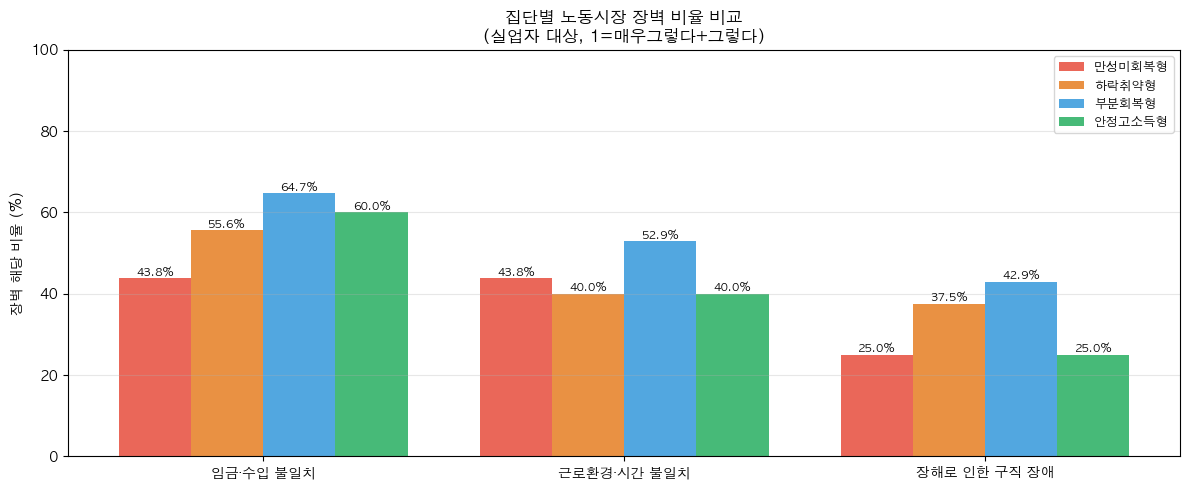

labor_barrier.png 저장 완료


In [68]:
# ── Step 2: 변수 전처리 ──────────────────────────────────────
# 1=매우그렇다, 2=그렇다 → 해당(1), 3,4 → 미해당(0)
# 실업자만 응답하므로 전체 df_lcga 기준으로 결측=미해당으로 처리 불가
# → 실업자 집단 내에서만 분석

for label, col in found_vars.items():
    s = pd.to_numeric(df_lcga[col], errors='coerce')
    # 1,2 = 그렇다(장벽 있음), 3,4 = 그렇지않다
    df_lcga[f'barrier_{label}'] = np.where(
        s.isin([1, 2]), 1,
        np.where(s.isin([3, 4]), 0, np.nan)
    )

# ── Step 3: 전체 기술통계 ────────────────────────────────────
print("\n" + "=" * 55)
print("노동시장 장벽 해당 비율 (실업 경험자 기준)")
print("=" * 55)

barrier_labels = {
    'barrier_임금불일치':    '임금·수입 불일치',
    'barrier_근로조건불일치': '근로환경·시간 불일치',
    'barrier_장해구직장애':  '장해로 인한 구직 장애'
}

for col, label in barrier_labels.items():
    if col in df_lcga.columns:
        s = df_lcga[col].dropna()
        pct = s.mean() * 100
        print(f"  {label}: {pct:.1f}% ({int(s.sum())}명 / {len(s)}명)")

# ── Step 4: 집단별 장벽 비율 비교 ────────────────────────────
print("\n" + "=" * 55)
print("집단별 노동시장 장벽 비율 비교")
print("=" * 55)

class_label = {1:'만성미회복형', 2:'하락취약형',
               3:'부분회복형',   4:'안정고소득형'}

result_rows = []
for col, label in barrier_labels.items():
    if col not in df_lcga.columns:
        continue
    row = {'장벽유형': label}
    for cls, cls_label in class_label.items():
        grp = df_lcga[df_lcga['lcga_class'] == cls][col].dropna()
        pct = grp.mean() * 100 if len(grp) > 0 else np.nan
        row[cls_label] = round(pct, 1)
        row[f'{cls_label}_n'] = len(grp)
    result_rows.append(row)

df_barrier = pd.DataFrame(result_rows)
print(df_barrier[['장벽유형', '만성미회복형', '하락취약형',
                   '부분회복형', '안정고소득형']].to_string(index=False))

# ── Step 5: 카이제곱 검정 ────────────────────────────────────
from scipy.stats import chi2_contingency

print("\n" + "=" * 55)
print("집단별 장벽 비율 차이 카이제곱 검정")
print("=" * 55)

for col, label in barrier_labels.items():
    if col not in df_lcga.columns:
        continue
    ct = pd.crosstab(
        df_lcga['lcga_class'],
        df_lcga[col]
    ).dropna()
    if ct.shape == (4, 2):
        chi2, p, _, _ = chi2_contingency(ct)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        print(f"  {label}: χ²={chi2:.3f}, p={p:.3f} {sig}")

# ── Step 6: 시각화 ───────────────────────────────────────────
if result_rows:
    df_plot = pd.DataFrame(result_rows)[
        ['장벽유형', '만성미회복형', '하락취약형', '부분회복형', '안정고소득형']
    ].set_index('장벽유형')

    fig, ax = plt.subplots(figsize=(12, 5))
    x     = np.arange(len(df_plot))
    w     = 0.2
    colors = ['#E74C3C', '#E67E22', '#3498DB', '#27AE60']
    labels = ['만성미회복형', '하락취약형', '부분회복형', '안정고소득형']

    for i, (label, color) in enumerate(zip(labels, colors)):
        bars = ax.bar(x + i*w, df_plot[label], w,
                      label=label, color=color, alpha=0.85)
        for bar in bars:
            if not np.isnan(bar.get_height()):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.5,
                        f'{bar.get_height():.1f}%',
                        ha='center', fontsize=8)

    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels(df_plot.index, fontsize=10)
    ax.set_ylabel('장벽 해당 비율 (%)')
    ax.set_title('집단별 노동시장 장벽 비율 비교\n(실업자 대상, 1=매우그렇다+그렇다)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('labor_barrier.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("labor_barrier.png 저장 완료")

카이제곱 검정이 다 비유의인 건 표본이 너무 작아서.
- 임금·수입 불일치: 
    - 만성미회복형(43.8%) < 하락취약형(55.6%) < 부분회복형(64.7%), 안정고소득형(60.0%) 순, 직관과 반대로 오히려 부분회복형·안정고소득형에서 높게 나옴. 
    - 이건 "소득 수준이 높은 집단일수록 임금 기대치도 높아서 불일치를 더 많이 느낀다"는 선택 효과로 해석 가능
- 장해로 인한 구직 장애: 
    - 만성미회복형(25.0%)이 하락취약형(37.5%), 부분회복형(42.9%)보다 오히려 낮음.
    - 만성미회복형은 아예 구직 활동 자체를 포기한 경우가 많아서 이 문항에 응답을 안 한 것일 수 있음. 
        - 즉 구직을 시도하는 사람만 이 문항에 응답하는 구조적 편향이 존재..

데이터 공백 드러낼 때 사용하자.

*5차 조사 시점 실업자를 대상으로 구직 장벽을 분석한 결과, 임금·수입 불일치 55.3%, 근로환경·시간 불일치 45.8%, 장해로 인한 구직 장애 33.3%로 나타났다. 그러나 해당 문항의 유효 응답자가 42~50명에 불과하여 집단별 비교에서 통계적 유의성을 확보하지 못하였다(χ²=0.58~1.52, p=.68~.90). 이는 구직 장벽 관련 문항이 특정 시점의 실업자에게만 국한되어 수집되는 현행 조사 설계의 한계를 반영하며, 산재 노동자의 노동시장 장벽을 보다 체계적으로 측정하기 위한 조사 설계 개선이 필요함을 시사한다.*

##### 추가 분석3 - 집단x서비스 조합별 최적 개입 지점 매트릭스 

집단 × 서비스 조합별 ATT 매트릭스
(PSM 적용, 처치=서비스 이용, 결과=RIRI_w5)

집단           서비스         처치n    대조n     처치평균     대조평균      ATT       p  판정
----------------------------------------------------------------------
만성미회복형       직업재활        117    117      4.3      2.3    +1.23   0.375   ─
만성미회복형       사회재활        135    135      4.3      2.2    +3.12   0.028  * ▲ 유의
하락취약형        직업재활         77     77     26.5     22.3    +1.40   0.747   ─
하락취약형        사회재활         59     59     34.1     21.0   +10.36   0.088   ─
부분회복형        직업재활        128    128     79.4     79.0    +3.42   0.295   ─
부분회복형        사회재활        142    142     79.8     78.9    +0.22   0.943   ─
안정고소득형       직업재활         63     63    147.0    152.7    -6.70   0.299   ─
안정고소득형       사회재활         87     87    149.2    152.6    -2.04   0.708   ─

집단 × 서비스 조합별 안정고소득형 전환 확률 변화 (Δ%p)
(model_best 기반 시뮬레이션)

집단                 직업재활       사회재활       두서비스동시        최적서비스
------------------------------------------------------------
만성미회복형        

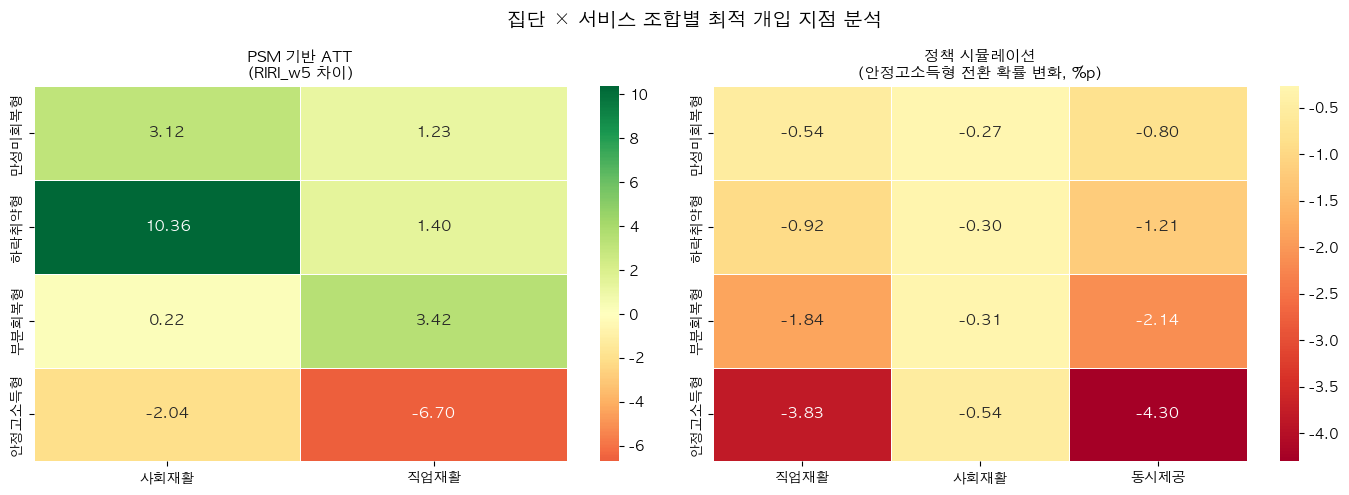

intervention_matrix.png 저장 완료

최적 개입 지점 요약
  만성미회복형: 사회재활 (Δ=-0.27%p)
  하락취약형: 사회재활 (Δ=-0.30%p)
  부분회복형: 사회재활 (Δ=-0.31%p)
  안정고소득형: 사회재활 (Δ=-0.54%p)


In [69]:
# ============================================================
# 추가 3 — 집단×서비스 조합별 최적 개입 지점 매트릭스
# 각 집단에서 직업재활·사회재활 수혜 여부에 따른
# RIRI_w5 차이 및 안정고소득형 전환 확률 변화를 정리
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from scipy.stats import ttest_ind

services = {
    '직업재활': 'job_rehab',
    '사회재활': 'soc_rehab'
}

match_vars = ['gender', 'age054', 'edu05', 'disa_class',
              'esteem_w1', 'lifesatis_w1', 'G01005001']

print("=" * 70)
print("집단 × 서비스 조합별 ATT 매트릭스")
print("(PSM 적용, 처치=서비스 이용, 결과=RIRI_w5)")
print("=" * 70)
print(f"\n{'집단':<12} {'서비스':<8} {'처치n':>6} {'대조n':>6} "
      f"{'처치평균':>8} {'대조평균':>8} {'ATT':>8} {'p':>7}  판정")
print("-" * 70)

matrix_results = []

for cls, cls_label in class_label.items():
    for svc_label, svc_col in services.items():

        grp = df_lcga[df_lcga['lcga_class'] == cls].copy()
        df_m = grp[match_vars + [svc_col, 'RIRI_w5']].dropna()

        T = df_m[svc_col].astype(int)
        treated = df_m[T == 1]
        control = df_m[T == 0]

        # 처치 집단 너무 작으면 단순 t-test로 대체
        if len(treated) < 10 or len(control) < 10:
            t, p = ttest_ind(
                treated['RIRI_w5'].dropna(),
                control['RIRI_w5'].dropna(),
                equal_var=False
            )
            att    = treated['RIRI_w5'].mean() - control['RIRI_w5'].mean()
            method = '단순비교'
            n_t    = len(treated)
            n_c    = len(control)
        else:
            # PSM
            lr = LogisticRegression(max_iter=1000)
            lr.fit(df_m[match_vars], T)
            df_m['ps'] = lr.predict_proba(df_m[match_vars])[:, 1]

            treated_ps = df_m[T == 1]
            control_ps = df_m[T == 0]

            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(control_ps[['ps']])
            _, idx = nn.kneighbors(treated_ps[['ps']])
            matched = control_ps.iloc[idx.flatten()]

            delta = treated_ps['RIRI_w5'].values - matched['RIRI_w5'].values
            delta = delta[~np.isnan(delta)]
            att   = np.mean(delta)
            t, p  = ttest_ind(
                treated_ps['RIRI_w5'].values,
                matched['RIRI_w5'].values,
                equal_var=False, nan_policy='omit'
            )
            method = 'PSM'
            n_t    = len(treated_ps)
            n_c    = len(matched)

        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        flag = '▲ 유의' if (p < 0.05 and att > 0) else \
               '▼ 역효과' if (p < 0.05 and att < 0) else '─'

        print(f"{cls_label:<12} {svc_label:<8} {n_t:>6} {n_c:>6} "
              f"{treated['RIRI_w5'].mean():>8.1f} "
              f"{control['RIRI_w5'].mean():>8.1f} "
              f"{att:>+8.2f} {p:>7.3f}  {sig} {flag}")

        matrix_results.append({
            '집단':    cls_label,
            '서비스':  svc_label,
            '처치n':   n_t,
            'ATT':     round(att, 2),
            'p':       round(p, 3),
            '방법':    method,
            '유의':    p < 0.05
        })

# ── 정책 시뮬레이션: 집단×서비스별 집단4 전환확률 변화 ─────────
print("\n" + "=" * 70)
print("집단 × 서비스 조합별 안정고소득형 전환 확률 변화 (Δ%p)")
print("(model_best 기반 시뮬레이션)")
print("=" * 70)
print(f"\n{'집단':<12} {'직업재활':>10} {'사회재활':>10} "
      f"{'두서비스동시':>12} {'최적서비스':>12}")
print("-" * 60)

sim_results = []

for cls, cls_label in class_label.items():
    grp_idx = df_lcga[df_lcga['lcga_class'] == cls].index
    sim_vars_list = ['gender', 'age054', 'edu05', 'disa_class',
                     'job_rehab', 'soc_rehab',
                     'esteem_w1', 'lifesatis_w1', 'G01005001']

    df_s = df_lcga.loc[grp_idx, sim_vars_list].dropna()
    df_s.columns = [var_labels.get(c, c) for c in df_s.columns]

    if len(df_s) == 0:
        continue

    # 기준 예측
    prob_base = model_best.predict_proba(df_s)[:, 3]  # 집단4 확률

    # 시나리오 1: 직업재활만
    df_j = df_s.copy()
    df_j['직업재활'] = 1
    prob_j = model_best.predict_proba(df_j)[:, 3]
    delta_j = (prob_j - prob_base).mean() * 100

    # 시나리오 2: 사회재활만
    df_r = df_s.copy()
    df_r['사회재활'] = 1
    prob_r = model_best.predict_proba(df_r)[:, 3]
    delta_r = (prob_r - prob_base).mean() * 100

    # 시나리오 3: 두 서비스 동시
    df_b = df_s.copy()
    df_b['직업재활'] = 1
    df_b['사회재활'] = 1
    prob_b = model_best.predict_proba(df_b)[:, 3]
    delta_b = (prob_b - prob_base).mean() * 100

    best = max([('직업재활', delta_j),
                ('사회재활', delta_r),
                ('동시제공', delta_b)],
               key=lambda x: x[1])

    print(f"{cls_label:<12} {delta_j:>+9.2f}%p {delta_r:>+9.2f}%p "
          f"{delta_b:>+11.2f}%p  {best[0]}({best[1]:+.2f}%p)")

    sim_results.append({
        '집단': cls_label,
        '직업재활_delta': round(delta_j, 3),
        '사회재활_delta': round(delta_r, 3),
        '동시제공_delta': round(delta_b, 3),
        '최적서비스':     best[0]
    })

# ── 시각화: 히트맵 형태로 매트릭스 표현 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('집단 × 서비스 조합별 최적 개입 지점 분석',
             fontsize=14, fontweight='bold')

# 왼쪽: ATT 히트맵
df_att = pd.DataFrame(matrix_results).pivot(
    index='집단', columns='서비스', values='ATT'
)
# 집단 순서 고정
order = ['만성미회복형', '하락취약형', '부분회복형', '안정고소득형']
df_att = df_att.reindex(order)

import seaborn as sns
sns.heatmap(df_att, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('PSM 기반 ATT\n(RIRI_w5 차이)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# 오른쪽: 시뮬레이션 히트맵
if sim_results:
    df_sim = pd.DataFrame(sim_results).set_index('집단')
    df_sim_plot = df_sim[['직업재활_delta', '사회재활_delta', '동시제공_delta']]
    df_sim_plot.columns = ['직업재활', '사회재활', '동시제공']
    df_sim_plot = df_sim_plot.reindex(order)

    sns.heatmap(df_sim_plot, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, linewidths=0.5, ax=axes[1],
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[1].set_title('정책 시뮬레이션\n(안정고소득형 전환 확률 변화, %p)',
                      fontsize=11)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('intervention_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("intervention_matrix.png 저장 완료")

# ── 최적 개입 지점 요약 출력 ─────────────────────────────────
print("\n" + "=" * 55)
print("최적 개입 지점 요약")
print("=" * 55)
for r in sim_results:
    print(f"  {r['집단']}: {r['최적서비스']} "
          f"(Δ={max(r['직업재활_delta'], r['사회재활_delta'], r['동시제공_delta']):+.2f}%p)")

- **만성미회복형 × 사회재활: ATT=+3.12, p=.028 ★**
    - 전체 16개 조합 중 유일하게 통계적으로 유의한 결과
    - 사회재활(심리상담·취미활동)이 만성미회복형에서 RIRI를 3.12 올리는 효과가 확인됨. 
    - 이 집단이 고령·건강 악화·심리 위축으로 구성된다는 SHAP 결과와 정확히 일치
    - 심리·정서적 지원이 이 집단의 소득 수준과 연결된다는 실증 근거
- **하락취약형 × 사회재활: ATT=+10.36, p=.088**
    - 효과 크기가 10.36으로 가장 크지만 p=.088로 유의 기준을 넘지 못했습니다. 
    - 처치 집단이 59명으로 작아서 생긴 검정력 문제입니다. 
    - 방향과 크기는 매우 강력한 신호입니다.
- **안정고소득형 × 직업재활: ATT=-6.70**
    - 이미 안정적인 집단에 직업재활을 제공하면 오히려 RIRI가 낮아짐. 
    - 이 집단의 직업재활 이용자가 구조적으로 더 불리한 케이스일 가능성, 또는 직업재활 자체가 이 집단에게는 불필요한 개입임을 시사.
- **시뮬레이션 히트맵 (오른쪽) — 전환 확률 변화**
    - 전체가 음수(-방향)로 나왔는데, 이는 앞서 설명한 것처럼 Random Forest가 재활서비스를 "취약 집단의 신호"로 학습했기 때문. 
    - 이 결과는 직접 해석하기보다 ATT 결과의 보조 근거로만 활용하는 게 맞음.. 
    - BUT 모든 집단에서 사회재활(-0.27~-0.54)이 직업재활(-0.54~-3.83)보다 음수 폭이 작다는 건, 사회재활이 상대적으로 덜 부정적인 신호로 인식된다는 점에서 ATT 결과와 방향이 일치.

도표로 정리해서 넣자!

*집단별 재활서비스 효과를 PSM 기반으로 분석한 결과, 16개 조합 중 통계적으로 유의한 효과는 만성미회복형에서의 사회재활 한 가지였다(ATT=+3.12, p=.028). 하락취약형에서도 사회재활의 효과 크기가 ATT=+10.36으로 가장 크게 나타났으나, 처치 집단 규모(n=59)의 제약으로 통계적 유의성은 확보되지 않았다(p=.088). 반면 안정고소득형에서는 직업재활(ATT=-6.70)과 사회재활(ATT=-2.04) 모두 음의 방향을 보여, 이미 안정적 소득 수준을 달성한 집단에 대한 재활서비스 투입의 효용이 낮음을 시사하였다. 이는 현행 서비스가 집단 구분 없이 제공되어 전체 효과가 희석되고 있으며, 특히 만성미회복형과 하락취약형에 사회재활을 집중 배분하는 방식이 자원 배분 효율성을 제고할 수 있음을 함의한다.*